# Carbon leakage risk in EU industries

**CRISP-DM project notebook.** The project will identify descriptive carbon-leakage risk signals across the EU27. Steel is one possible example, not the project scope.

The presentation follows four questions: **Where do we see possible risk? What do offset projects report? Can we attribute changes to activity shifting elsewhere? What could happen by 2030?** Section 14 adds illustrative 2030 paths for C20 and C23, anchored to the last common four-indicator year (2022). The three evidence levels are kept distinct throughout; a risk pattern or a project-reported estimate alone does not establish a causal result. Deployment is out of scope.

This notebook starts by organizing the supplied datasets, recording the external data needed for the research questions, and setting up careful joins at compatible levels. For the audience-facing four-step summary, see [Section 10](#the-story-we-will-tell-in-four-steps).


## 1. Business understanding

### Working definition

For this project, a **potential carbon-leakage risk signal** is a sustained pattern in which EU domestic production and production-side emissions decline while imports and the greenhouse-gas emissions embodied in those imports rise for comparable industries or products. This is a descriptive screening definition. The pattern alone does not establish that EU climate policy caused production or emissions to move abroad. Throughout the notebook, findings are labelled as (1) a risk signal, (2) project-reported leakage, or (3) causally established leakage; these are different evidence claims.

### Scope and unit

- Geography: the **EU27 held constant throughout the time series**. Country-level analyses use the 27 member states; EU aggregate rows are kept separate to avoid double-counting.
- Working unit: country × sector/product × partner country × year when the source supports it. Some measures are only available at country × sector × year, so they will remain separate or be aggregated to a common level.
- We will distinguish intra-EU partner flows from extra-EU flows. Extra-EU import growth is the more direct external-leakage signal; intra-EU shifts may indicate relocation within the EU.

### Working hypothesis

Falling EU production + falling EU production emissions + rising imports + rising imported embodied GHG is a **potential leakage signal to investigate**. We will track each component separately before considering any combined flag.


### Research questions and initial success criteria

1. Which EU country-sector/product groups show sustained declines in domestic production and production-side emissions?
2. Do imports rise for comparable goods, and are increases concentrated in extra-EU partners?
3. Do emissions embodied in EU imports rise, and how does that compare with emissions embodied in EU exports?
4. Are the patterns robust to product classifications, trade quantities versus values, time windows, and data coverage?

A convincing **risk signal** should have aligned directions over multiple years, comparable definitions and units, adequate coverage, and robustness to reasonable classification and period choices. A positive imports-minus-exports balance shows a net inflow of embodied emissions in the measured trade flows. It remains a risk signal, not proof of causation. We will avoid a weighted risk score until its indicators and weights have a defensible basis.

## 2. Data understanding

### Supplied data

- The EU ETS package includes installation-level compliance and emissions, account tables, NACE leakage-list codes, and links to facilities and plants. It covers only installations in the EU ETS, not all industry output or national industrial emissions. Use it as a complementary installation-level view.
- The supplied OECD ICIO GHG main file has country/activity/year production- and demand-based emissions, but no bilateral importer/exporter dimension. It can support country-sector context after code harmonization.
- CarbonPlan OffsetsDB is included in Section 8 as a dated inventory of carbon-offset projects located in EU27 countries. Its project and credit tables do not directly measure project leakage.

### External sources

| Measure | Source and dataset | Useful grain | Main caveat |
|---|---|---|---|
| Production and trade values/quantities | Eurostat PRODCOM historical series, `DS-059358` | Reporter by product by year | Sold production is not always total physical output; product-specific units and confidentiality flags matter. No partner-country detail in this extract. |
| Bilateral imports/exports | Eurostat Comext, `DS-045409` | Reporter by partner by CN product by month/year | CN changes over time; confidential product/partner cells and intra-EU/extra-EU reporting need care. |
| Domestic production-side emissions | Eurostat Air Emissions Accounts, `env_ac_ainah_r2` | Country by NACE Rev. 2 activity by year | Resident-unit emissions at broad NACE levels, not product-level. |
| Embodied GHG in bilateral trade | OECD GHG Footprint Indicators 2025 bilateral trade dataflow | Exporter by importer by activity by product category by year | Input-output model estimates at broader categories; not direct measurements for each traded product. This notebook uses separate EU27 import and export extracts and compares them only where both sides are available. |

Official references: [Eurostat PRODCOM guide](https://ec.europa.eu/eurostat/documents/d/prodcom/quick-guide-on-accessing-prodcom-data-ds-059367), [Eurostat Comext API and trade data](https://ec.europa.eu/eurostat/web/user-guides/data-browser/api-data-access/api-getting-started/comext-database), [Eurostat Air Emissions Accounts metadata](https://ec.europa.eu/eurostat/cache/metadata/en/env_ac_ainah_r2_sims.htm), and [OECD GHG Footprint Indicators](https://www.oecd.org/en/data/datasets/greenhouse-gas-footprint-indicators.html).

Keep product-level production/trade facts separate from sector-level emissions/embodied-GHG facts until an official concordance supports a join. Similar labels alone are not a valid product-to-industry match.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

# Resolve the repository whether Jupyter starts at its root or in notebooks/.
import os

NOTEBOOK_CWD = Path.cwd()
PROJECT_ROOT = NOTEBOOK_CWD if (NOTEBOOK_CWD / 'outputs').exists() else NOTEBOOK_CWD.parent
DATA_ROOT = Path(os.environ.get('CARBON_LEAK_DATA_DIR', PROJECT_ROOT / 'data' / 'raw')).expanduser()
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
PRESENTATION_DIR = OUTPUT_DIR / 'carbon_leakage_figures'
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)
EUTL_DIR = DATA_ROOT / 'eutl_data_package_2026-07-21'
OECD_FILES = sorted(DATA_ROOT.glob('OECD*.csv'))

# EU27 ISO-2/EUTL registry codes, held constant throughout. For Eurostat's
# GEO dimension, map Greece from GR to EL before querying.
EU27_ISO2 = [
    'AT', 'BE', 'BG', 'HR', 'CY', 'CZ', 'DK', 'EE', 'FI', 'FR', 'DE', 'GR',
    'HU', 'IE', 'IT', 'LV', 'LT', 'LU', 'MT', 'NL', 'PL', 'PT', 'RO', 'SK',
    'SI', 'ES', 'SE'
]

EU27_EUROSTAT_GEO = ['EL' if code == 'GR' else code for code in EU27_ISO2]

# For OECD tables that use ISO-3 reference-area codes.
EU27_ISO3 = [
    'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 'FIN', 'FRA',
    'DEU', 'GRC', 'HUN', 'IRL', 'ITA', 'LVA', 'LTU', 'LUX', 'MLT', 'NLD',
    'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'ESP', 'SWE'
]

assert DATA_ROOT.exists(), f'Data folder not found: {DATA_ROOT}'
assert EUTL_DIR.exists(), f'EU ETS folder not found: {EUTL_DIR}'
assert len(OECD_FILES) == 1, f'Expected one supplied OECD CSV; found {len(OECD_FILES)}'
print('Data root:', DATA_ROOT)
print('Supplied OECD file:', OECD_FILES[0].name)


Data root: F:\Carbon Leak
Supplied OECD file: OECD.STI.PIE,DSD_ICIO_GHG_MAIN_2025@DF_ICIO_GHG_MAIN_2025,1.0,complete,2026-09-23 08-14-05.csv


In [ ]:
# Load EU ETS package metadata and all manageable CSV tables except transactions.
with (EUTL_DIR / 'datapackage.json').open(encoding='utf-8') as f:
    eutl_metadata = json.load(f)
resource_metadata = {r['name']: r for r in eutl_metadata['resources']}

eutl_tables = {}
for table_name, resource in resource_metadata.items():
    if table_name == 'transactions':
        continue
    eutl_tables[table_name] = pd.read_csv(EUTL_DIR / resource['path'], low_memory=False)

installations = eutl_tables['installations']
compliance = eutl_tables['compliance']
nace_mappings = eutl_tables['nace_mappings']
print(f'Loaded {len(eutl_tables)} EU ETS tables. Large transactions.csv is available via chunks below.')


In [ ]:
# The supplied OECD GHG main file provides production- and demand-based GHG
# observations by country/activity/year. Keep the source values and dimensions.
oecd_icio = pd.read_csv(OECD_FILES[0], low_memory=False)
print('OECD supplied table:', oecd_icio.shape)
print('Measures:', sorted(oecd_icio['MEASURE'].dropna().unique()))
print('EU27 country codes present:', sorted(set(EU27_ISO3) & set(oecd_icio['REF_AREA'].dropna().unique())))


In [ ]:
def read_transaction_chunks(chunksize=250_000):
    """Yield chunks from EU ETS transactions without loading the full table."""
    return pd.read_csv(
        EUTL_DIR / resource_metadata['transactions']['path'],
        chunksize=chunksize, low_memory=False
    )

# The transaction table's `id` repeats in this extract; do not deduplicate on id alone.


### External data loaded for the first analysis

Filtered source extracts are stored under `F:\Carbon Leak\external_data`. We now have EU27 Air Emissions Accounts by country and industry, PRODCOM sold-production values, Comext imports by partner and CN chapter, sector price indexes, and OECD modeled emissions embodied in extra-EU imports and exports. The first joined panel covers 2008-2022 for five broad industrial divisions (C17, C19, C20, C23, C24).

This is a **screening panel**, not a product-matched supply-chain account. Production is sold-production value in constant 2020 euros; extra-EU imports use broad CN chapter groups as a provisional industry proxy; OECD embodied GHG is modeled at industry level. Both OECD trade directions are available for C19, C20, and C23 in the extract; missing export observations for other sectors are kept unavailable, not set to zero. Physical output quantities are not summed across unlike products.

Source extracts and their filters are documented in JSON manifests alongside the CSV files. The sector mapping should be tightened with a verified PRODCOM-CN concordance before making stronger claims.

In [ ]:
# Eurostat APIs. The main dissemination API serves Air Emissions Accounts;
# Comext's dedicated API serves PRODCOM and detailed trade datasets.
EUROSTAT_MAIN_API = 'https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/'
EUROSTAT_COMEXT_API = 'https://ec.europa.eu/eurostat/api/comext/dissemination/statistics/1.0/data/'
EUROSTAT_DATASETS = {
    'production': {'domain': 'comext', 'code': 'ds-059358'},
    'trade': {'domain': 'comext', 'code': 'ds-045409'},
    'emissions': {'domain': 'main', 'code': 'env_ac_ainah_r2'},
}
OECD_GHG_TRADE_DATASET = (
    'https://data-explorer.oecd.org/vis?df[ag]=OECD.STI.PIE'
    '&df[ds]=dsDisseminateFinalDMZ'
    '&df[id]=DSD_ICIO_GHG_TRADE_2025%40DF_ICIO_GHG_TRADE_2025&df[vs]=1.0'
)

from urllib.parse import urlencode
from urllib.request import Request, urlopen

def eurostat_jsonstat_to_frame(payload):
    """Convert a Eurostat JSON-stat 2.0 response to one row per observation."""
    if 'error' in payload:
        raise ValueError(payload['error'])
    dimension_ids = payload['id']
    sizes = payload['size']
    dim_codes, dim_labels = {}, {}
    for dim in dimension_ids:
        category = payload['dimension'][dim]['category']
        index = category['index']
        if isinstance(index, dict):
            codes = sorted(index, key=index.get)
        else:
            codes = list(index)
        dim_codes[dim] = codes
        dim_labels[dim] = category.get('label', {})

    values = payload.get('value', {})
    observations = values.items() if isinstance(values, dict) else enumerate(values)
    records = []
    statuses = payload.get('status', {})
    for flat_index, value in observations:
        if value is None:
            continue
        coordinates = np.unravel_index(int(flat_index), tuple(sizes))
        row = {dim: dim_codes[dim][coordinates[i]] for i, dim in enumerate(dimension_ids)}
        row['OBS_VALUE'] = value
        if str(flat_index) in statuses:
            row['OBS_STATUS'] = statuses[str(flat_index)]
        records.append(row)
    return pd.DataFrame.from_records(records)

def fetch_eurostat_jsonstat(dataset_code, filters, domain='main', timeout=120):
    """Fetch a filtered Eurostat JSON-stat dataset; filters map dimensions to codes.

    Values may be lists to request multiple positions. Use dataset code lists to
    select valid dimension names/codes before making large or detailed requests.
    """
    base = EUROSTAT_COMEXT_API if domain == 'comext' else EUROSTAT_MAIN_API
    params = dict(filters)
    params.update({'format': 'JSON', 'lang': 'en'})
    query = urlencode(params, doseq=True)
    request = Request(base + dataset_code + '?' + query, headers={'User-Agent': 'Mozilla/5.0'})
    with urlopen(request, timeout=timeout) as response:
        payload = json.loads(response.read().decode('utf-8'))
    return eurostat_jsonstat_to_frame(payload)

# Example call (fill filters from each dataset's code lists before running):
# aea = fetch_eurostat_jsonstat('env_ac_ainah_r2', filters={...}, domain='main')
# prodcom = fetch_eurostat_jsonstat('ds-059367', filters={...}, domain='comext')
# trade = fetch_eurostat_jsonstat('ds-045409', filters={...}, domain='comext')

# Example URLs for reference. Add dimension filters only after product/sector
# classifications and time coverage are agreed. Comext requests must be filtered.
for key, source in EUROSTAT_DATASETS.items():
    api_root = EUROSTAT_COMEXT_API if source['domain'] == 'comext' else EUROSTAT_MAIN_API
    print(key, '->', api_root + source['code'])
print('OECD bilateral trade data ->', OECD_GHG_TRADE_DATASET)


### Harmonization rules to apply

- Filter reporting countries to the fixed EU27 list. Do not include the EU aggregate in sums of member-country data.
- Keep partner countries in Comext/OECD data and add an `intra_eu27` versus `extra_eu27` flag.
- Align product nomenclature versions over time (CN/PRODCOM) before computing long trends; preserve source codes and concordance versions.
- Match physical quantities only when units are compatible. Keep values and quantities distinct. Handle confidential, estimated, and suppressed flags explicitly.
- Map detailed NACE/PRODCOM categories to Eurostat A*64 and OECD activity/product categories only through documented concordances. Record one-to-many mappings and aggregate before joining.
- Use the same year range across production, emissions, trade, and embodied-GHG data; report the effective overlap after download.


## 3. Data preparation: descriptive leakage indicators

Calculate changes only after creating an aligned country-sector/product-year panel. Suggested features:

- **Production change:** `(production_t - production_t-1) / production_t-1`
- **Import growth:** `(imports_t - imports_t-1) / imports_t-1`
- **Domestic emissions change:** `(emissions_t - emissions_t-1) / emissions_t-1`
- **Import penetration:** the proposed gross-import share is `imports / (domestic production + imports)`. Where compatible exports are available, also calculate `imports / (production + imports - exports)` as an apparent-consumption measure (ignoring stock changes). Do not call either measure comparable if units, product coverage, or reporting bases differ.
- **Imported embodied GHG growth:** year-on-year change in OECD GHG embodied in imports, at the OECD industry/product-category grain.
- **Carbon-intensity gap:** only if emissions and output can be aligned by compatible country-sector-year and denominator units.

Zero or negative denominators, missing years, product-code breaks, and suppressed trade cells must yield missing/flagged results rather than silent infinities or fabricated zeroes.


In [ ]:
def safe_yoy(series):
    """Year-on-year fractional change; zero/missing prior values remain missing."""
    previous = series.shift(1)
    return (series - previous) / previous.where(previous.ne(0))

# Template for use after harmonized source panels are assembled:
# panel = panel.sort_values(['country', 'sector_or_product', 'year'])
# panel['production_change'] = panel.groupby(['country', 'sector_or_product'])['production'].transform(safe_yoy)
# panel['import_growth'] = panel.groupby(['country', 'sector_or_product', 'partner'])['imports'].transform(safe_yoy)
# panel['domestic_emissions_change'] = panel.groupby(['country', 'sector'])['domestic_emissions'].transform(safe_yoy)
# panel['imported_ghg_growth'] = panel.groupby(['country', 'sector', 'partner'])['imported_ghg'].transform(safe_yoy)


## 4. First look at supplied data

The following checks show what the current files can support before adding Eurostat and OECD bilateral trade data. EU ETS compliance covers installations rather than total national industry output, so it is supplementary evidence.


In [ ]:
# Coverage of EU ETS installations and compliance records by member state/year.
eutl_eu27 = installations[installations['registry_id'].isin(EU27_ISO2)].copy()
compliance_eu27 = compliance[compliance['registry_id'].isin(EU27_ISO2)].copy()
print('EU27 installations:', len(eutl_eu27), '| compliance records:', len(compliance_eu27))
display(compliance_eu27.groupby('year').agg(
    installation_year_rows=('installation_id', 'size'),
    installations=('installation_id', 'nunique'),
    verified_total=('verified', 'sum'),
    allocated_total=('allocated', 'sum'),
).reset_index().tail())


In [ ]:
annual = (
    compliance_eu27.groupby('year', as_index=False)
    .agg(installations=('installation_id', 'nunique'),
         verified=('verified', 'sum'), allocated=('allocated', 'sum'))
    .sort_values('year')
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(annual['year'], annual['installations'], marker='o')
axes[0].set(title='EU27 ETS installations with compliance records', xlabel='Year', ylabel='Installations')
axes[0].grid(alpha=.25)
axes[1].plot(annual['year'], annual['verified'], marker='o', label='Verified')
axes[1].plot(annual['year'], annual['allocated'], marker='o', label='Allocated')
axes[1].set(title='EU27 ETS compliance totals (source units)', xlabel='Year', ylabel='Total')
axes[1].legend(); axes[1].grid(alpha=.25)
plt.tight_layout()


In [ ]:
# Supplied OECD production-based GHG observations, filtered to EU27. Keep one
# activity and unit at a time; summing across aggregate and detailed activities
# would double-count. Use this as a coverage/shape check before plotting sectors.
oecd_eu27 = oecd_icio[
    oecd_icio['REF_AREA'].isin(EU27_ISO3)
    & oecd_icio['MEASURE'].eq('PROD_GHG')
].copy()
print('OECD EU27 production-GHG rows:', len(oecd_eu27))
display(oecd_eu27[['REF_AREA', 'ACTIVITY', 'UNIT_MEASURE', 'TIME_PERIOD', 'OBS_VALUE']].head())
print('Activity codes:', sorted(oecd_eu27['ACTIVITY'].dropna().unique())[:30])


## 5. First comparable trend panel and directional tests

The preliminary intensity screen selected five carbon-intensive NACE divisions: C17, C19, C20, C23, and C24. All five are tested for domestic emissions trends. The OECD bilateral file has matching activity rows only for C19, C20, and C23, so embodied-GHG trends are tested for those three and shown as unavailable for C17 and C24.

For domestic emissions, member-state Air Emissions Accounts are summed at the exact NACE division (never together with overlapping totals). For imported embodied GHG, the OECD measure is summed across EU27 importers and non-EU exporter country rows; EU27 exporter rows and aggregate exporter rows are excluded. Values are shown in Mt CO₂e.

The directional tests use Spearman rank correlation between year and each annual series: the pre-specified direction is down for domestic emissions and up for extra-EU imported embodied GHG. Benjamini–Hochberg q-values adjust all available directional tests together. These are exploratory trend screens; the p-values do not account for serial correlation and cannot establish climate-policy causation. The full four-part hypothesis still requires aligned production and ordinary-import measures.

## CRISP-DM status

- **Business understanding:** descriptive leakage-risk signals only; EU27 held constant; no causal claim or deployment.
- **Data understanding:** supplied EU ETS, OECD ICIO and OffsetsDB sources reviewed; Eurostat production, emissions, trade, price-index and OECD bilateral embodied-carbon extracts added.
- **Data preparation:** a 2008-2022 EU27 sector-year screen combines five industrial divisions. PRODCOM-to-CN alignment remains broad and provisional; physical quantities are not matched across sources.
- **Analysis:** endpoint comparisons and one-sided monotonic-trend screens cover production value, domestic emissions, extra-EU import value, and modeled import carbon where available. A new OECD imports-versus-exports balance is available for C19, C20 and C23. Three project reports have source-checked leakage findings; two additional cases have secondary-source leads awaiting primary-document review. The notebook also adds conditional 2030 scenarios for C20 and C23.
- **Modeling/evaluation:** the 2030 paths extend historical growth rates from the latest common four-indicator year, 2022. They are scenario sensitivities, not probabilities or causal estimates.
- **Deployment:** out of scope.

### Load the comparable sector series

This uses the downloaded, filtered extracts so the notebook does not make large API requests when opened.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

EXTERNAL_DIR = DATA_ROOT / 'external_data'
AEA_PATH = EXTERNAL_DIR / 'eurostat_aea_eu27_ghg_2008_on.csv'
OECD_BILATERAL_PATH = EXTERNAL_DIR / 'oecd_ghg_embodied_bilateral_trade_eu27_2008_2022.csv'
OECD_EXPORTS_PATH = EXTERNAL_DIR / 'oecd_ghg_embodied_bilateral_trade_eu27_exports_2008_2022.csv'

# Exact divisions available in both the emissions and OECD embodied-trade files.
ANALYSIS_SECTORS = ['C17', 'C19', 'C20', 'C23', 'C24']
SECTOR_LABELS = {
    'C17': 'Paper and paper products',
    'C19': 'Coke and refined petroleum',
    'C20': 'Chemicals',
    'C23': 'Other non-metallic mineral products',
    'C24': 'Basic metals',
}
EU27_ISO3_SET = set(EU27_ISO3)

# Eurostat Air Emissions Accounts: OBS_VALUE is thousand tonnes CO2e.
_em = pd.read_csv(AEA_PATH, low_memory=False)
_em = _em[
    _em['geo'].isin(EU27_EUROSTAT_GEO)
    & _em['nace_r2'].isin(ANALYSIS_SECTORS)
    & _em['unit'].eq('THS_T')
].copy()
_em['year'] = _em['time'].astype(int)
_em['domestic_emissions_mt'] = _em['OBS_VALUE'] / 1000
domestic_emissions = (
    _em.groupby(['nace_r2', 'year'], as_index=False)['domestic_emissions_mt'].sum()
    .rename(columns={'nace_r2': 'sector'})
)

# OECD GHG Footprints: scale observations by the SDMX unit multiplier to tonnes,
# then display as million tonnes. Imports are flows from non-EU exporters to EU27.
_bilat = pd.read_csv(
    OECD_BILATERAL_PATH,
    usecols=['EXPORTER', 'IMPORTER', 'ACTIVITY', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MULT'],
    low_memory=False,
)
_bilat = _bilat[
    _bilat['IMPORTER'].isin(EU27_ISO3_SET)
    & _bilat['ACTIVITY'].isin(ANALYSIS_SECTORS)
    & _bilat['EXPORTER'].str.len().eq(3)
    & ~_bilat['EXPORTER'].isin(EU27_ISO3_SET)
    & ~_bilat['EXPORTER'].isin(['WXD'])
].copy()
_bilat['year'] = _bilat['TIME_PERIOD'].astype(int)
_bilat['imported_embodied_ghg_mt'] = (
    _bilat['OBS_VALUE'] * np.power(10.0, _bilat['UNIT_MULT'].astype(float)) / 1_000_000
)
extra_eu_embodied = (
    _bilat.groupby(['ACTIVITY', 'year'], as_index=False)['imported_embodied_ghg_mt'].sum()
    .rename(columns={'ACTIVITY': 'sector'})
)

# The export extract reverses the direction: EU27 exporters to non-EU importers.
# It was downloaded separately because the import extract filters importers to EU27.
assert OECD_EXPORTS_PATH.exists(), f'OECD export extract not found: {OECD_EXPORTS_PATH}'
_bilat_exports = pd.read_csv(
    OECD_EXPORTS_PATH,
    usecols=['EXPORTER', 'IMPORTER', 'ACTIVITY', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MULT'],
    low_memory=False,
)
_bilat_exports = _bilat_exports[
    _bilat_exports['EXPORTER'].isin(EU27_ISO3_SET)
    & _bilat_exports['IMPORTER'].str.len().eq(3)
    & ~_bilat_exports['IMPORTER'].isin(EU27_ISO3_SET)
    & _bilat_exports['ACTIVITY'].isin(ANALYSIS_SECTORS)
].copy()
_bilat_exports['year'] = _bilat_exports['TIME_PERIOD'].astype(int)
_bilat_exports['exported_embodied_ghg_mt'] = (
    _bilat_exports['OBS_VALUE'] * np.power(10.0, _bilat_exports['UNIT_MULT'].astype(float)) / 1_000_000
)
extra_eu_exports_embodied = (
    _bilat_exports.groupby(['ACTIVITY', 'year'], as_index=False)['exported_embodied_ghg_mt'].sum()
    .rename(columns={'ACTIVITY': 'sector'})
)

# Keep gross flows and calculate the net embodied-emissions trade balance only
# for sector-years where both directions have observations. Positive = net import.
trade_embodied_panel = extra_eu_embodied.merge(
    extra_eu_exports_embodied, on=['sector', 'year'], how='outer', validate='one_to_one'
)
trade_embodied_panel['net_embodied_trade_mt'] = (
    trade_embodied_panel['imported_embodied_ghg_mt'] - trade_embodied_panel['exported_embodied_ghg_mt']
).where(
    trade_embodied_panel['imported_embodied_ghg_mt'].notna()
    & trade_embodied_panel['exported_embodied_ghg_mt'].notna()
)

# Shared time window; preserve source measures and the trade balance separately.
trend_panel = domestic_emissions.merge(trade_embodied_panel, on=['sector', 'year'], how='outer')
trend_panel = trend_panel[trend_panel['year'].between(2008, 2022)].sort_values(['sector', 'year'])
print('Sector-years retained:', len(trend_panel), '| years:', trend_panel['year'].min(), 'to', trend_panel['year'].max())
coverage = trend_panel.groupby('sector').agg(
    emissions_years=('domestic_emissions_mt', 'count'),
    embodied_import_years=('imported_embodied_ghg_mt', 'count'),
    embodied_export_years=('exported_embodied_ghg_mt', 'count'),
    comparable_trade_balance_years=('net_embodied_trade_mt', 'count'),
).reindex(ANALYSIS_SECTORS)
coverage['embodied_ghg_status'] = np.where(coverage['embodied_import_years'].gt(0), 'available', 'not in OECD extract')
display(coverage)

Sector-years retained: 75 | years: 2008 to 2022


,emissions_years,embodied_import_years,embodied_export_years,comparable_trade_balance_years,embodied_ghg_status
sector,,,,,
C17,15,0,0,0,not in OECD extract
C19,15,15,15,15,available
C20,15,15,15,15,available
C23,15,15,15,15,available
C24,15,0,0,0,not in OECD extract


### Visualize absolute and indexed trends

Absolute values preserve the different units of the two source measures. The index panel sets each series to 100 in 2008 to make the direction and relative change easier to compare.

In [ ]:
fig, axes = plt.subplots(len(ANALYSIS_SECTORS), 3, figsize=(20, 18), sharex='col')
for row, sector in enumerate(ANALYSIS_SECTORS):
    d = trend_panel[trend_panel['sector'].eq(sector)].sort_values('year')
    label = SECTOR_LABELS[sector]
    axes[row, 0].plot(d['year'], d['domestic_emissions_mt'], marker='o', color='#3568a8')
    axes[row, 0].set_title(f'{sector}: {label} — domestic GHG', fontsize=10)
    axes[row, 0].set_ylabel('Mt CO₂e')
    axes[row, 0].grid(alpha=.25)

    imported = d.dropna(subset=['imported_embodied_ghg_mt'])
    if imported.empty:
        axes[row, 1].text(.5, .5, 'No matching OECD activity series', ha='center', va='center', transform=axes[row, 1].transAxes)
        axes[row, 2].plot(d['year'], d['domestic_emissions_mt'] / d['domestic_emissions_mt'].iloc[0] * 100, marker='o', label='Domestic GHG', color='#3568a8')
        axes[row, 2].legend(fontsize=8)
    else:
        axes[row, 1].plot(imported['year'], imported['imported_embodied_ghg_mt'], marker='o', color='#e07a32')
        axes[row, 2].plot(d['year'], d['domestic_emissions_mt'] / d['domestic_emissions_mt'].iloc[0] * 100, marker='o', label='Domestic GHG', color='#3568a8')
        axes[row, 2].plot(imported['year'], imported['imported_embodied_ghg_mt'] / imported['imported_embodied_ghg_mt'].iloc[0] * 100, marker='o', label='Extra-EU imported GHG', color='#e07a32')
        axes[row, 2].legend(fontsize=8)
    axes[row, 1].set_title(f'{sector}: {label} — extra-EU embodied GHG', fontsize=10)
    axes[row, 1].set_ylabel('Mt CO₂e')
    axes[row, 1].grid(alpha=.25)
    axes[row, 2].set_title(f'{sector}: {label} — index (2008 = 100)', fontsize=10)
    axes[row, 2].set_ylabel('Index')
    axes[row, 2].grid(alpha=.25)

for ax in axes[-1, :]:
    ax.set_xlabel('Year')
fig.suptitle('EU27 emissions and extra-EU imported embodied GHG for the screened sectors, 2008–2022', y=1.005, fontsize=14)
fig.tight_layout()
plt.show()


### Test the pre-specified trend directions

For each source measure and sector, test a monotonic time trend in its expected direction. Report Spearman ρ, the one-sided raw p-value, and the Benjamini–Hochberg adjusted q-value across all six tests. Small q-values are evidence of a monotonic descriptive trend under the test assumptions, not proof of carbon leakage.

In [ ]:
def benjamini_hochberg(p_values):
    """Benjamini-Hochberg adjusted p-values, returned in input order."""
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order] * n / np.arange(1, n + 1)
    adjusted_sorted = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted_sorted = np.clip(adjusted_sorted, 0, 1)
    q = np.empty(n, dtype=float)
    q[order] = adjusted_sorted
    return q

_test_rows = []
for sector in ANALYSIS_SECTORS:
    d = trend_panel[trend_panel['sector'].eq(sector)].sort_values('year')
    tests = [('domestic_emissions_mt', 'less', 'Domestic emissions (decreasing)')]
    if d['imported_embodied_ghg_mt'].notna().any():
        tests.append(('imported_embodied_ghg_mt', 'greater', 'Extra-EU import embodied GHG (increasing)'))
    for metric, expected, metric_label in tests:
        valid = d[['year', metric]].dropna()
        result = spearmanr(valid['year'], valid[metric], alternative=expected)
        _test_rows.append({
            'sector': sector, 'sector_name': SECTOR_LABELS[sector],
            'indicator': metric_label, 'expected_direction': expected,
            'n_years': len(valid), 'spearman_rho': result.statistic,
            'p_one_sided': result.pvalue,
        })
test_results = pd.DataFrame(_test_rows)
test_results['q_bh'] = benjamini_hochberg(test_results['p_one_sided'])
test_results['direction_matches'] = np.where(
    test_results['expected_direction'].eq('less'), test_results['spearman_rho'] < 0, test_results['spearman_rho'] > 0
)
test_results = test_results.sort_values(['sector', 'indicator']).reset_index(drop=True)
display(test_results.round({'spearman_rho': 3, 'p_one_sided': 4, 'q_bh': 4}))


### Initial findings from the first two indicators

The original trend panel tested domestic emissions across all five sectors and modeled extra-EU embodied GHG where the OECD extract provides a matching activity (C19, C20, and C23). All five domestic-emissions series decline monotonically over 2008–2022; among the available imported-carbon series, only C23 shows a clear upward monotonic trend. The newer four-indicator screen in Section 11 adds sold-production value and extra-EU import value using broad, explicitly provisional classifications. Its endpoint findings and updated multiple-testing results supersede any earlier wording that production and ordinary imports were untested.

These results remain descriptive. The import-to-industry mapping is broad, and the OECD figures are modeled estimates rather than direct shipment measurements.

### Reading the first results

Section 11 completes a first-pass four-indicator screen by adding constant-euro sold-production value and extra-EU import values to the earlier emissions measures. The two screens are not product-matched: PRODCOM, CN, NACE, and OECD activity classifications have different coverage. The expanded screen therefore identifies descriptive candidates for follow-up, not a fully harmonized leakage measure. Serial correlation, modeled embodied-emissions estimates, and classification mismatches limit inference.

## 6. Presentation-friendly visualizations

These figures are designed to be read without statistical training. Earlier charts show the emissions and embodied-carbon context; Section 11 adds a four-indicator screen using constant-euro sold-production values and extra-EU import values for five industrial divisions. These are broad sector proxies, not matched physical production and trade quantities. The partner, map, and context figures use C23 (other non-metallic mineral products), which had the clearest pattern in the earlier two-indicator screen. The new embodied-trade balance chart compares estimated emissions in extra-EU imports and exports for the three sectors where both flows are available. Event labels provide context only and do not attribute observed changes to those events.

In [3]:
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable

PRESENTATION_DIR = OUTPUT_DIR / 'carbon_leakage_figures'
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)
PRESENTATION_SECTORS = ['C17', 'C19', 'C20', 'C23', 'C24']
PRESENTATION_LABELS = {
    'C17': 'Paper and paper products',
    'C19': 'Coke and refined petroleum',
    'C20': 'Chemicals',
    'C23': 'Other non-metallic mineral products',
    'C24': 'Basic metals',
}

# Plain-English names for the largest C23 partners in this extract.
PARTNER_NAMES = {
    'CHN': 'China', 'TUR': 'Türkiye', 'IND': 'India', 'RUS': 'Russia',
    'USA': 'United States', 'GBR': 'United Kingdom', 'EGY': 'Egypt',
    'THA': 'Thailand', 'BLR': 'Belarus', 'JPN': 'Japan',
    'VNM': 'Vietnam', 'KOR': 'South Korea', 'CHE': 'Switzerland',
    'ARE': 'United Arab Emirates', 'TUN': 'Tunisia', 'MYS': 'Malaysia',
}

# Reusable boundaries are official Eurostat/GISCO country polygons in EPSG:3035.
BOUNDARY_PATH = EXTERNAL_DIR / 'eurostat_nuts_country_boundaries_2024_3035.geojson'
with BOUNDARY_PATH.open(encoding='utf-8') as f:
    EU_BOUNDARIES = json.load(f)

def _geometry_path(geometry):
    """Convert a published Polygon/MultiPolygon into a Matplotlib path."""
    polygons = [geometry['coordinates']] if geometry['type'] == 'Polygon' else geometry['coordinates']
    vertices, codes = [], []
    for polygon in polygons:
        for ring in polygon:
            pts = np.asarray(ring, dtype=float)
            if len(pts) < 4:
                continue
            vertices.extend(pts)
            codes.extend([MplPath.MOVETO] + [MplPath.LINETO] * (len(pts) - 2) + [MplPath.CLOSEPOLY])
    return MplPath(np.asarray(vertices), np.asarray(codes))

# The map comparison uses C23 annual country totals, 2008 versus 2022.
_country_dom = (_em[_em['nace_r2'].eq('C23') & _em['year'].isin([2008, 2022])]
                .groupby(['geo', 'year'])['domestic_emissions_mt'].sum().unstack())
_country_imp = (_bilat[_bilat['ACTIVITY'].eq('C23') & _bilat['year'].isin([2008, 2022])]
                .groupby(['IMPORTER', 'year'])['imported_embodied_ghg_mt'].sum().unstack())
country_to_eurostat_geo = {iso3: geo for geo, iso3 in zip(EU27_EUROSTAT_GEO, EU27_ISO3)}
_country_imp.index = _country_imp.index.map(country_to_eurostat_geo)
country_changes = pd.DataFrame({
    'domestic_change_mt': _country_dom[2022] - _country_dom[2008],
    'imported_embodied_change_mt': _country_imp[2022] - _country_imp[2008],
})
print('Presentation figures will be saved to:', PRESENTATION_DIR)
print('C23 map member states with both endpoints:', len(country_changes))


Presentation figures will be saved to: C:\Users\User\Documents\Codex\2026-09-23\i\outputs\carbon_leakage_figures
C23 map member states with both endpoints: 27


### 1. Sector evidence matrix

This overview distinguishes what the current data supports from what still needs harmonization. A blank or missing source is never treated as zero.

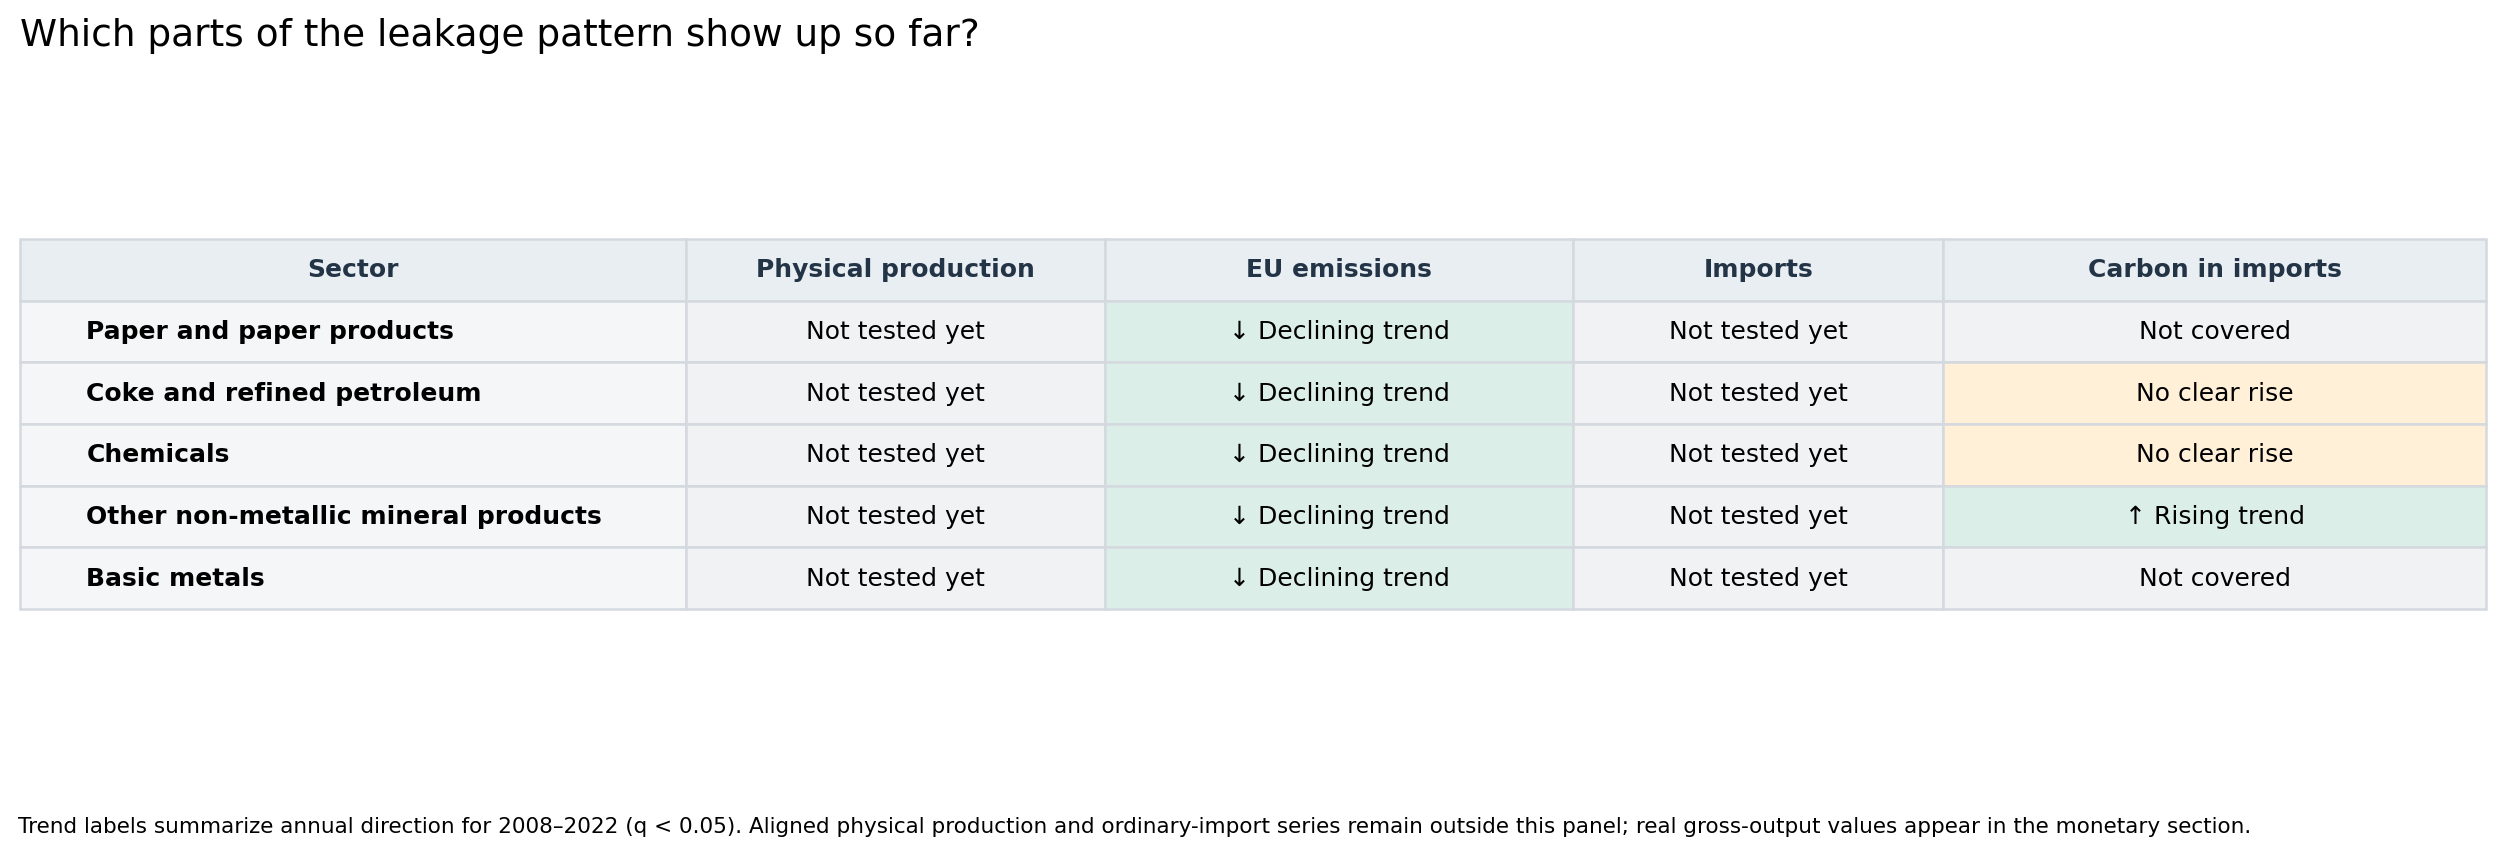

In [1]:
matrix_rows = []
for sector in PRESENTATION_SECTORS:
    domestic_test = test_results[(test_results['sector'].eq(sector)) & test_results['indicator'].str.startswith('Domestic emissions')].iloc[0]
    domestic_label = '↓ Declining trend' if domestic_test['q_bh'] < .05 and domestic_test['spearman_rho'] < 0 else 'No clear decline'
    imported_rows = test_results[(test_results['sector'].eq(sector)) & test_results['indicator'].str.startswith('Extra-EU')]
    if imported_rows.empty:
        imported_label = 'Not covered'
    else:
        it = imported_rows.iloc[0]
        imported_label = '↑ Rising trend' if it['q_bh'] < .05 and it['spearman_rho'] > 0 else 'No clear rise'
    matrix_rows.append([
        PRESENTATION_LABELS[sector], 'Not tested yet', domestic_label,
        'Not tested yet', imported_label,
    ])

fig, ax = plt.subplots(figsize=(14, 4.8))
ax.axis('off')
headers = ['Sector', 'Physical production', 'EU emissions', 'Imports', 'Carbon in imports']
table = ax.table(cellText=matrix_rows, colLabels=headers, cellLoc='center', colLoc='center',
                 colWidths=[.27, .17, .19, .15, .22], loc='center')
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1, 2.05)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#d4d9df')
    if r == 0:
        cell.set_facecolor('#e9eef3'); cell.set_text_props(weight='bold', color='#243447')
    elif c == 0:
        cell.set_facecolor('#f4f6f8'); cell.set_text_props(ha='left', weight='bold')
    else:
        value = matrix_rows[r-1][c]
        if value.startswith('↓') or value.startswith('↑'):
            cell.set_facecolor('#dceee8')
        elif value == 'Not covered' or value == 'Not tested yet':
            cell.set_facecolor('#f1f2f3')
        else:
            cell.set_facecolor('#fff0d7')
ax.set_title('Which parts of the leakage pattern show up so far?', loc='left', fontsize=15, pad=18)
fig.text(.01, .025, 'Trend labels summarize annual direction for 2008–2022 (q < 0.05). “Not tested yet” means aligned physical production and ordinary-import series are not in this panel. Real gross-output values appear in the monetary section.', fontsize=9)
fig.tight_layout(rect=[0, .08, 1, 1])
fig.savefig(PRESENTATION_DIR / '01-sector-evidence-matrix.png', dpi=180, bbox_inches='tight')
plt.show()


### 2. Sector trend stories

Each panel compares domestic production-side emissions with estimated carbon emissions associated with extra-EU imports. Both lines begin at 100 in 2008. This lets us compare direction and relative change, not absolute tonnes. The imported-carbon line is an OECD model estimate.

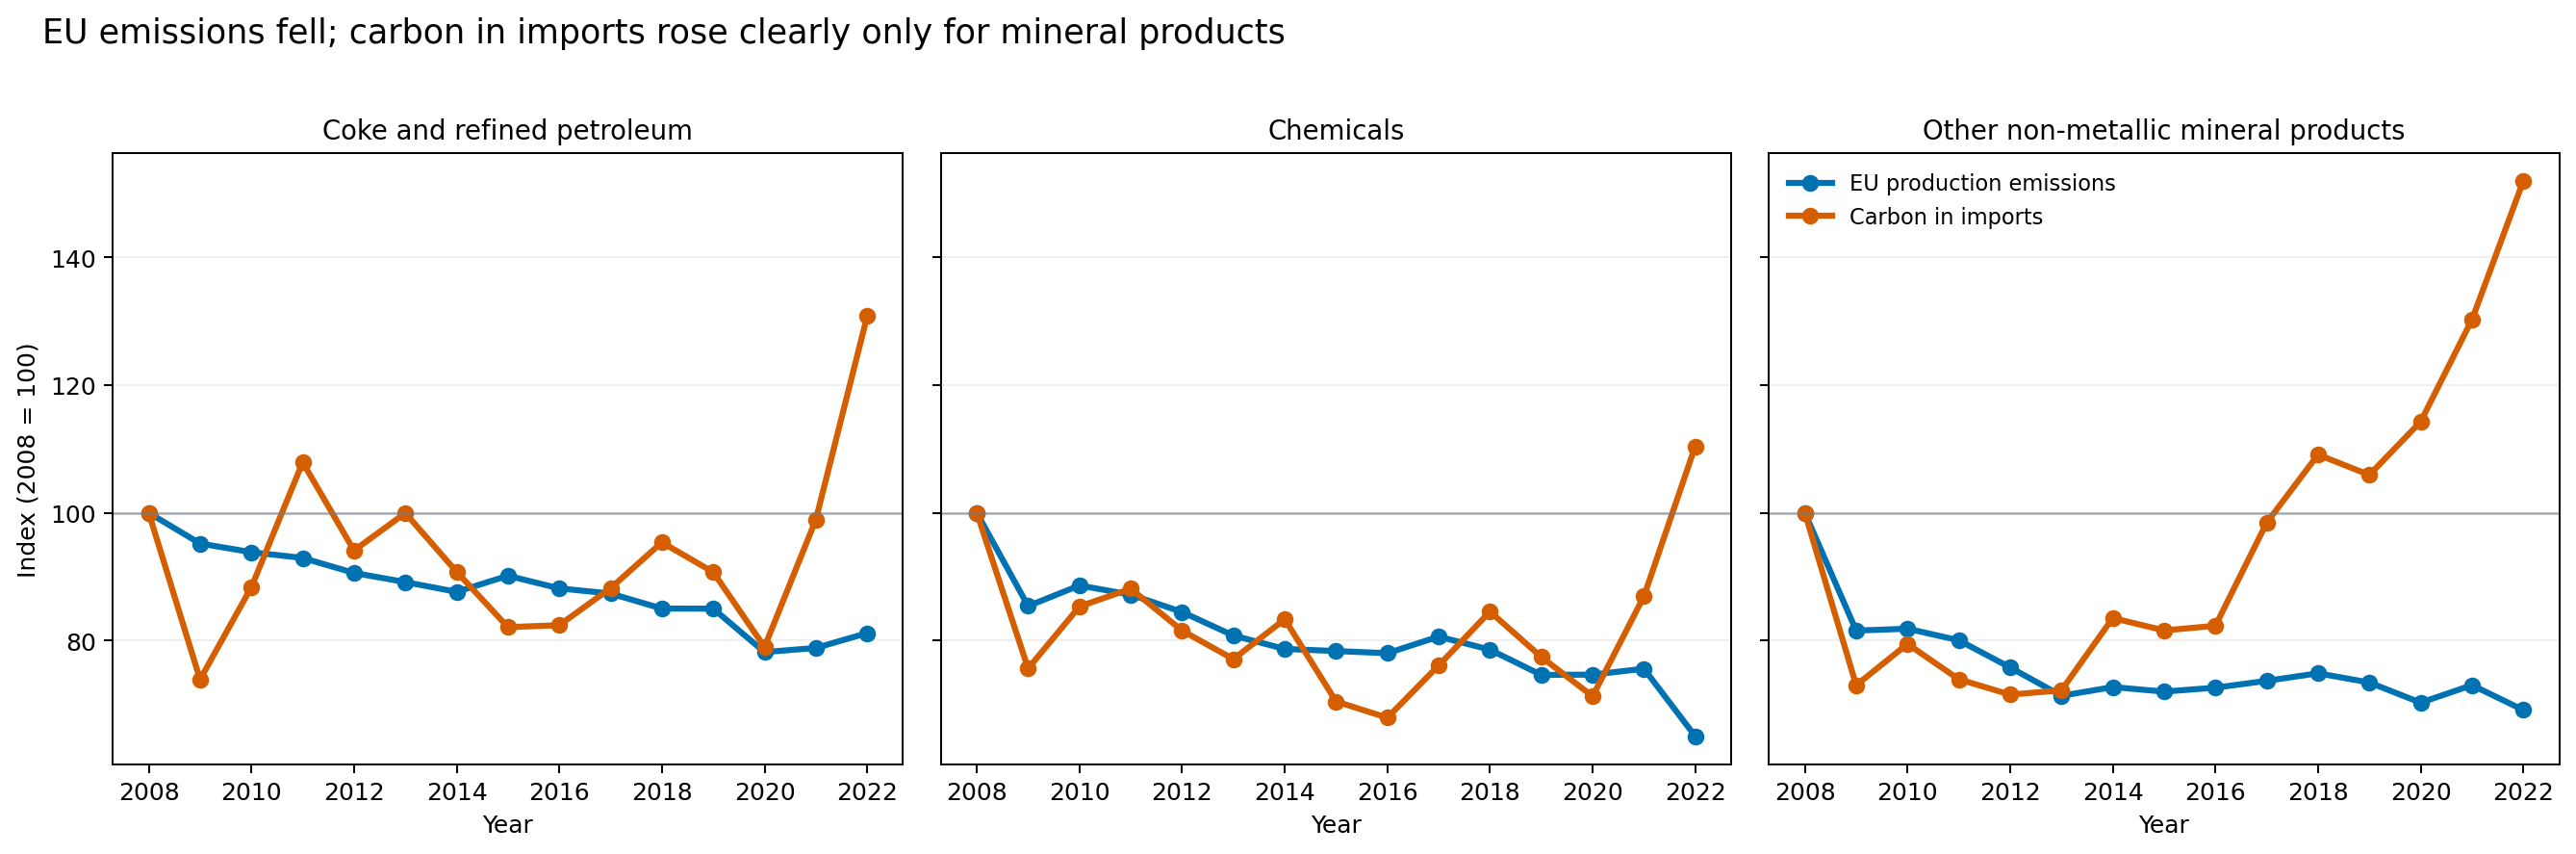

In [2]:
matched_sectors = ['C19', 'C20', 'C23']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, sector in zip(axes, matched_sectors):
    d = trend_panel[trend_panel['sector'].eq(sector)].sort_values('year')
    ax.plot(d['year'], d['domestic_emissions_mt'] / d['domestic_emissions_mt'].iloc[0] * 100,
            color='#0072B2', linewidth=2.5, marker='o', label='EU production emissions')
    ax.plot(d['year'], d['imported_embodied_ghg_mt'] / d['imported_embodied_ghg_mt'].iloc[0] * 100,
            color='#D55E00', linewidth=2.5, marker='o', label='Carbon in imports')
    ax.axhline(100, color='#737b84', linewidth=1, alpha=.6)
    ax.set_title(PRESENTATION_LABELS[sector], fontsize=11)
    ax.set_xlabel('Year')
    ax.grid(axis='y', alpha=.2)
axes[0].set_ylabel('Index (2008 = 100)')
axes[-1].legend(frameon=False, loc='best', fontsize=9)
fig.suptitle('EU emissions fell; carbon in imports rose clearly only for mineral products', x=.02, ha='left', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / '02-sector-trend-stories.png', dpi=180, bbox_inches='tight')
plt.show()


### 3. Change since 2008

This endpoint comparison shows how much each measure changed between 2008 and 2022. It summarizes the endpoints and does not show the ups and downs in between.

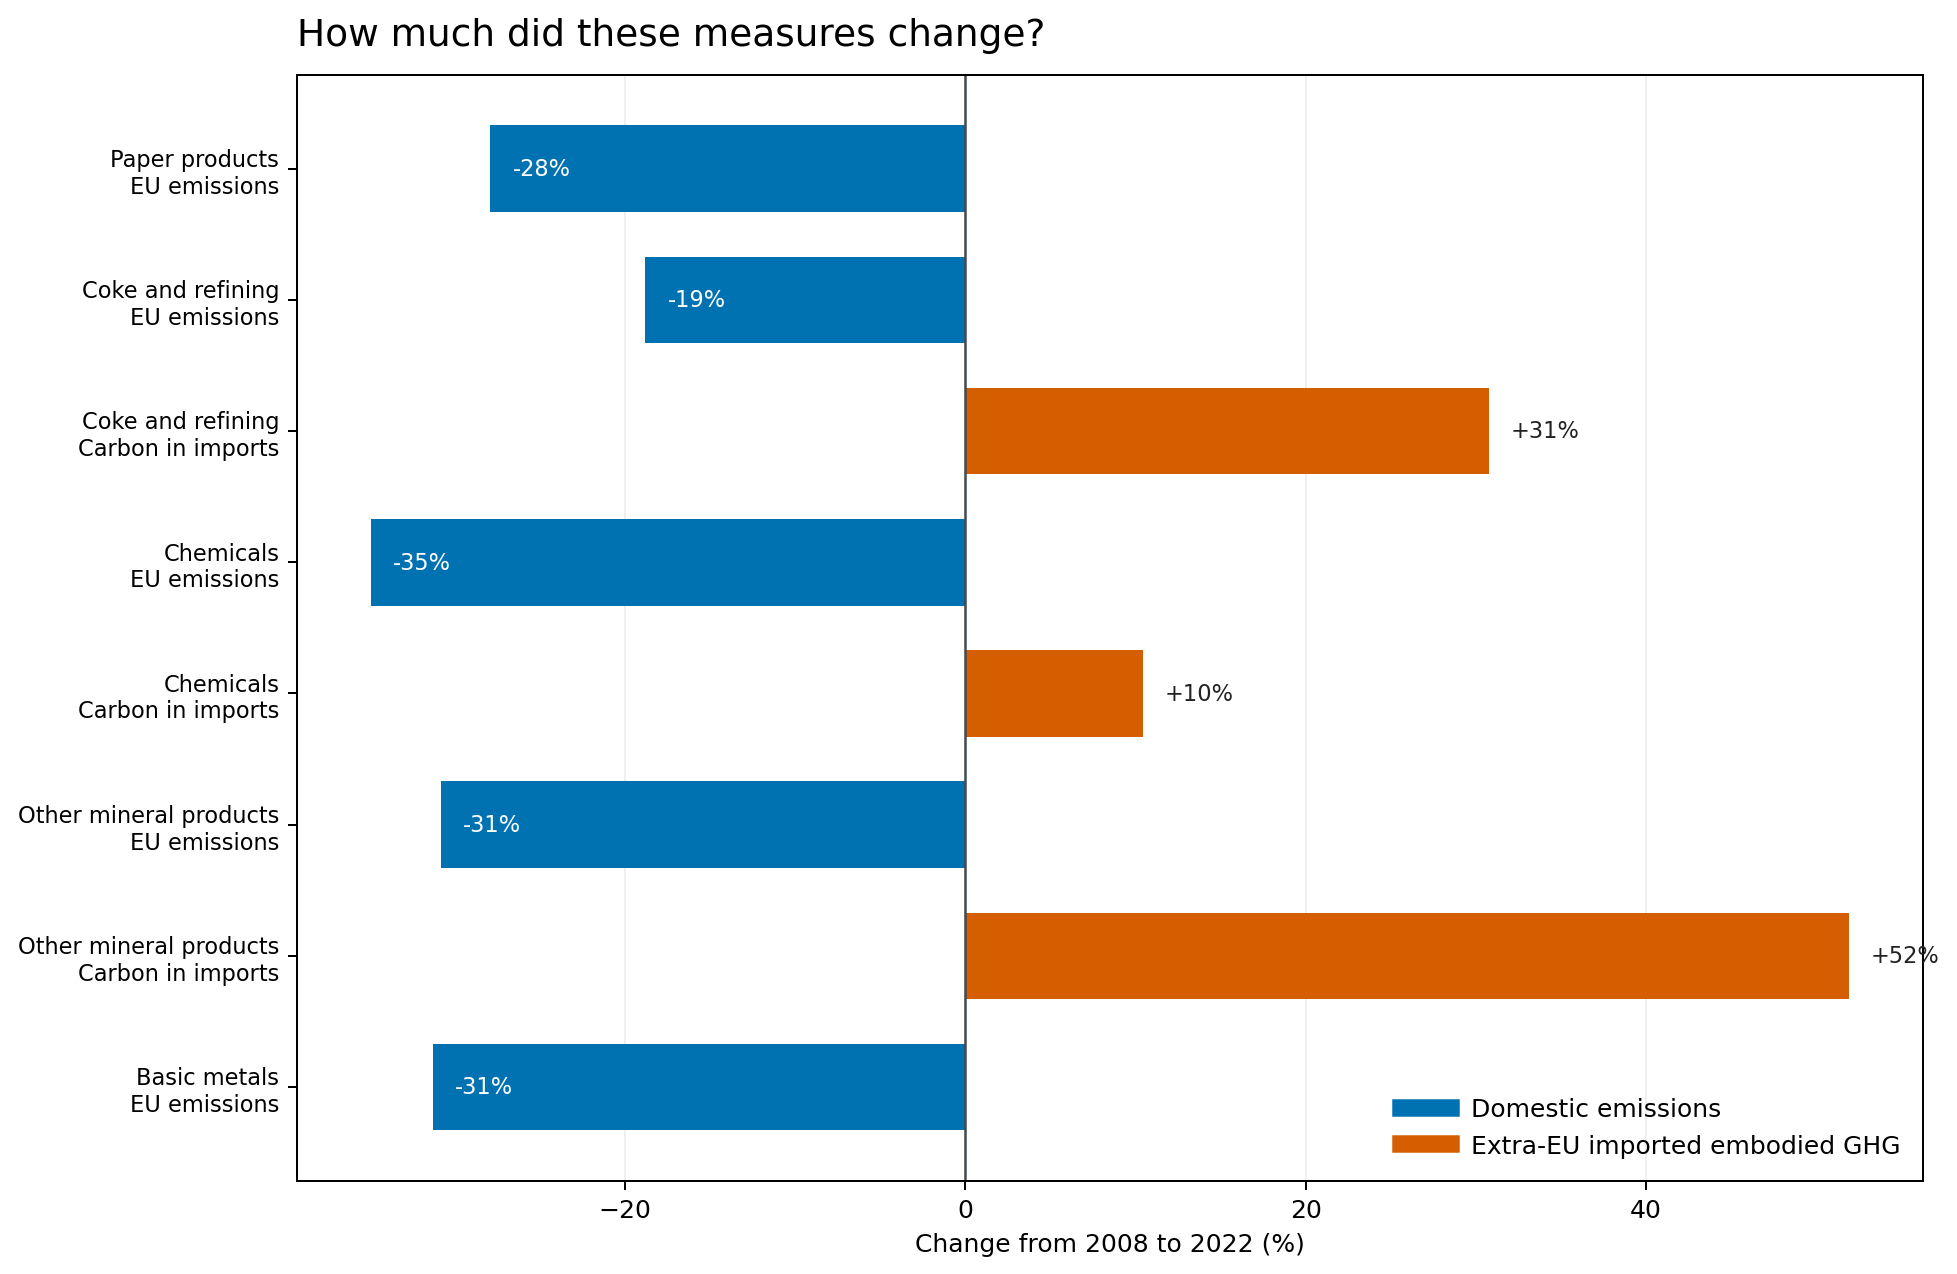

In [3]:
endpoint_rows = []
for sector in PRESENTATION_SECTORS:
    d = trend_panel[trend_panel['sector'].eq(sector)].sort_values('year')
    if d.empty: continue
    endpoint_rows.append((PRESENTATION_LABELS[sector], 'Domestic emissions',
        (d['domestic_emissions_mt'].iloc[-1] / d['domestic_emissions_mt'].iloc[0] - 1) * 100, '#0072B2'))
    z = d.dropna(subset=['imported_embodied_ghg_mt'])
    if not z.empty:
        endpoint_rows.append((PRESENTATION_LABELS[sector], 'Imported embodied GHG',
            (z['imported_embodied_ghg_mt'].iloc[-1] / z['imported_embodied_ghg_mt'].iloc[0] - 1) * 100, '#D55E00'))
endpoint = pd.DataFrame(endpoint_rows, columns=['sector', 'measure', 'change_pct', 'color'])
short_sector = {'Paper and paper products':'Paper products', 'Coke and refined petroleum':'Coke and refining', 'Chemicals':'Chemicals', 'Other non-metallic mineral products':'Other mineral products', 'Basic metals':'Basic metals'}
endpoint['label'] = endpoint['sector'].map(short_sector) + '\n' + endpoint['measure'].replace('Domestic emissions', 'EU emissions').replace('Imported embodied GHG', 'Carbon in imports')
endpoint = endpoint.iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 7.2))
ys = np.arange(len(endpoint))
ax.barh(ys, endpoint['change_pct'], color=endpoint['color'], height=.66)
ax.axvline(0, color='#424a52', linewidth=1)
ax.set_yticks(ys, endpoint['label'])
ax.set_xlabel('Change from 2008 to 2022 (%)')
ax.tick_params(axis='y', labelsize=9)
ax.set_title('How much did these measures change?', loc='left', fontsize=15, pad=12)
ax.grid(axis='x', alpha=.2); ax.set_axisbelow(True)
for y, value in zip(ys, endpoint['change_pct']):
    ax.text(value + (1.3 if value >= 0 else 1.3), y, f'{value:+.0f}%', va='center', ha='left', fontsize=9, color='white' if value < 0 else '#222222')
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],color='#0072B2',lw=7,label='Domestic emissions'), Line2D([0],[0],color='#D55E00',lw=7,label='Extra-EU imported embodied GHG')], frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / '03-change-since-2008.png', dpi=180, bbox_inches='tight')
plt.show()


### 4. EU country map: C23 change from 2008 to 2022

The paired maps show how the annual domestic emissions and extra-EU imported embodied emissions changed in each EU27 member state. The colors use separate scales for each map, so compare countries within a map, not the color intensity between maps. Boundary source: Eurostat/GISCO, © EuroGeographics for the administrative boundaries.

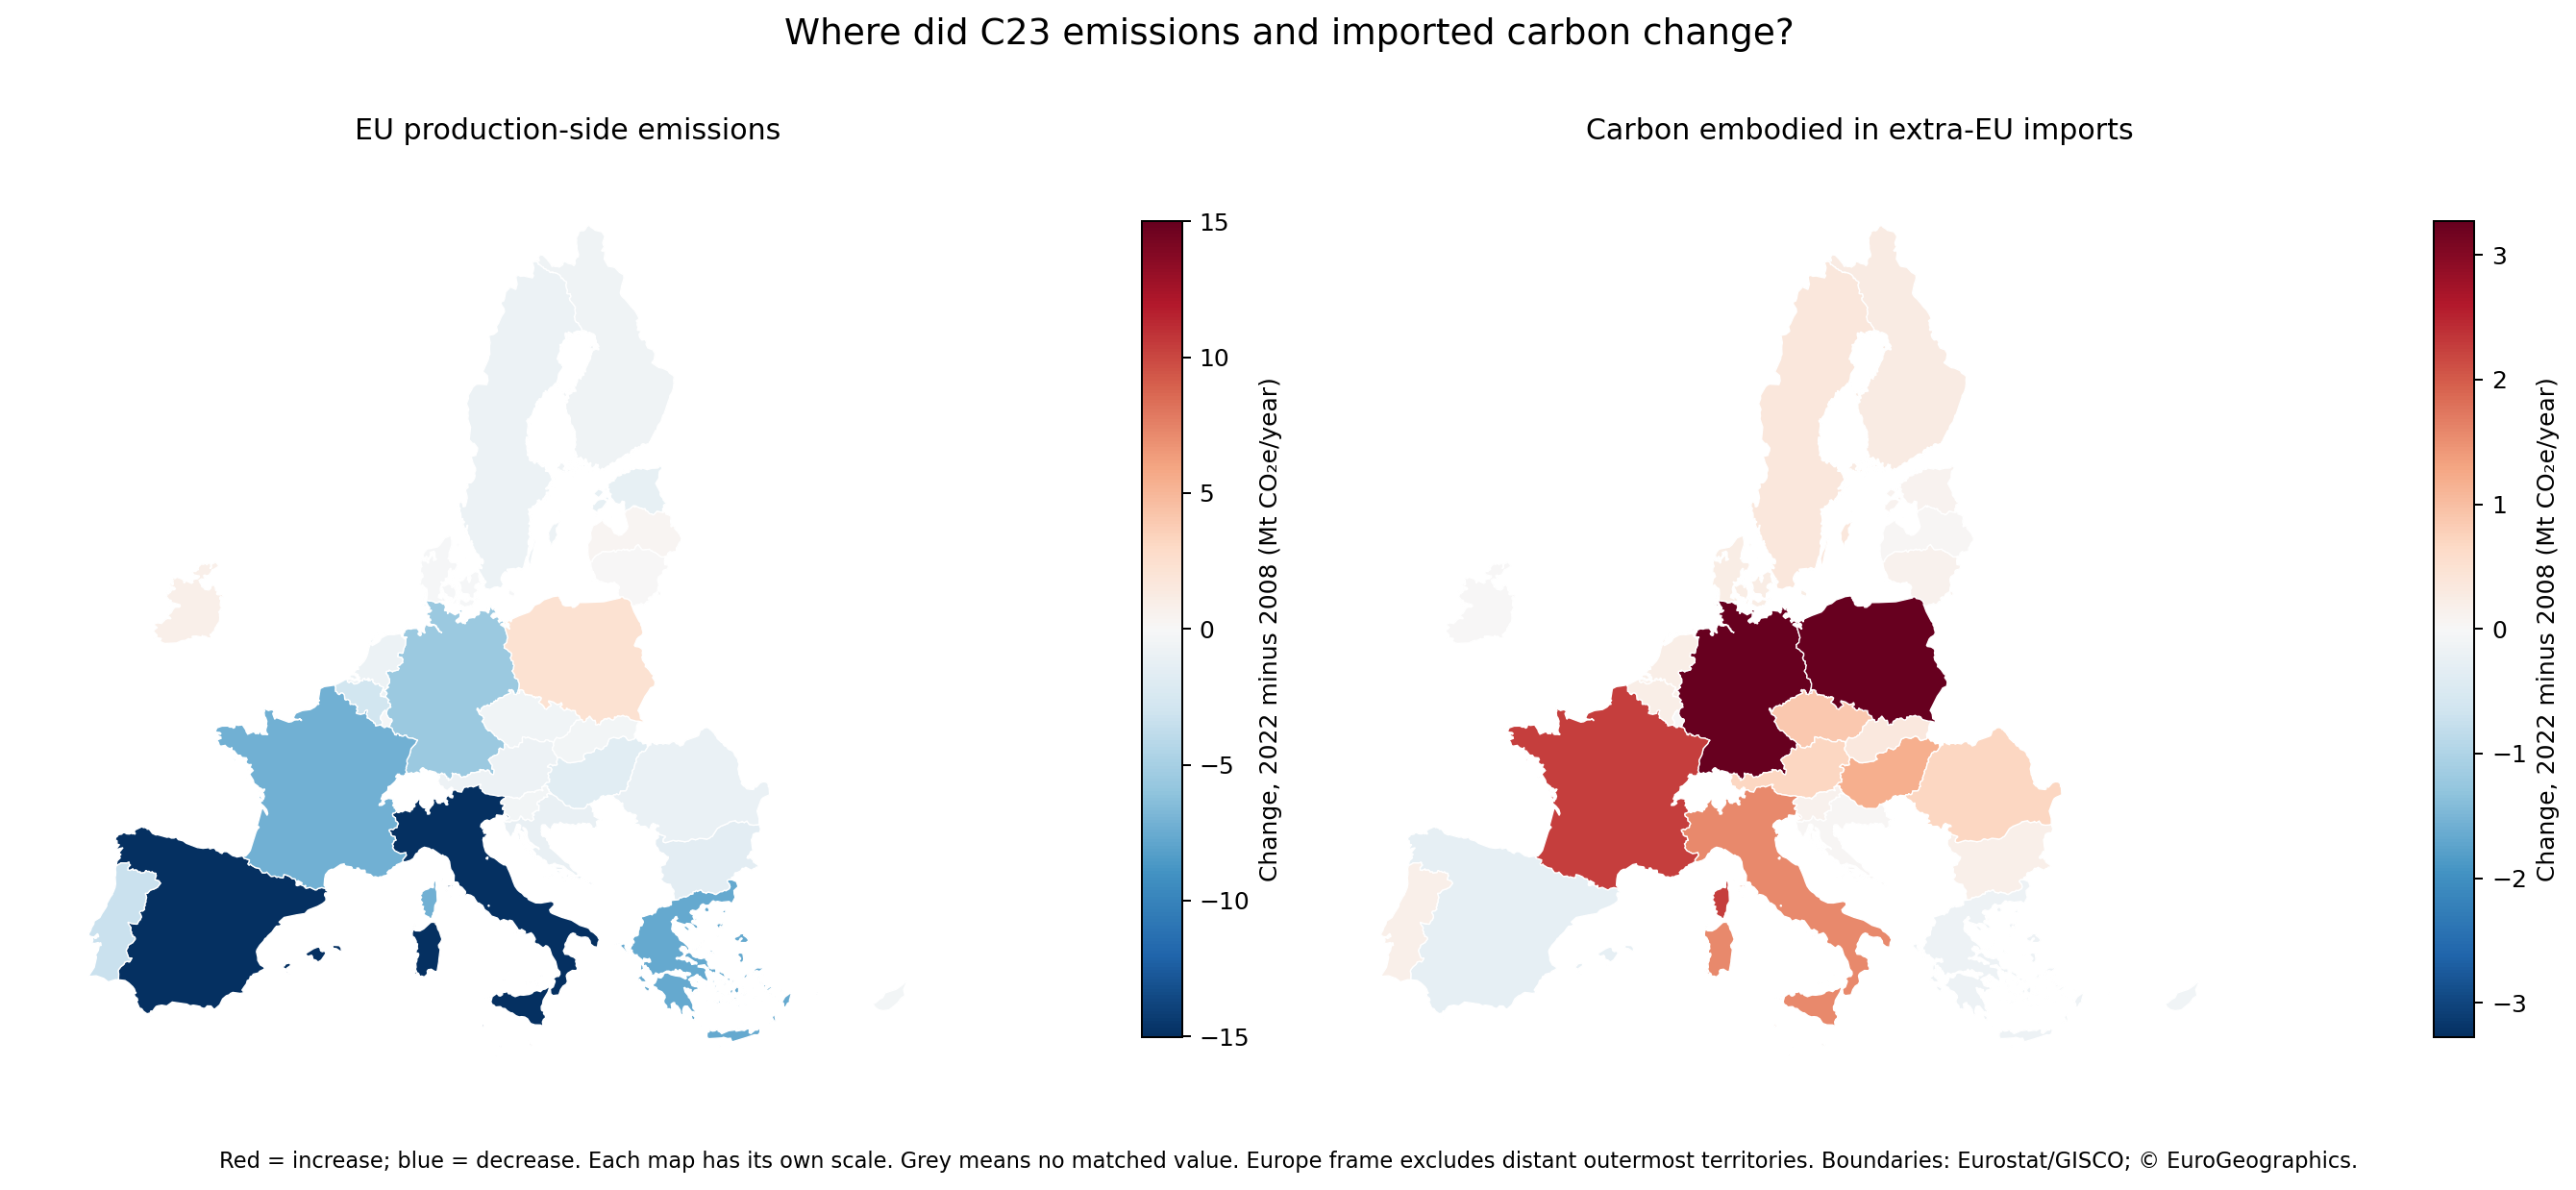

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
map_specs = [
    ('domestic_change_mt', 'EU production-side emissions'),
    ('imported_embodied_change_mt', 'Carbon embodied in extra-EU imports'),
]
features = [f for f in EU_BOUNDARIES['features'] if f['properties'].get('EU_STAT') == 'T']
for ax, (metric, title) in zip(axes, map_specs):
    vals = country_changes[metric].dropna()
    vmax = max(float(vals.abs().quantile(.95)), .01)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    for feature in features:
        code = feature['properties']['CNTR_CODE']
        value = country_changes.loc[code, metric] if code in country_changes.index else np.nan
        face = '#d9dde2' if pd.isna(value) else plt.get_cmap('RdBu_r')(norm(np.clip(value, -vmax, vmax)))
        patch = PathPatch(_geometry_path(feature['geometry']), facecolor=face, edgecolor='white', linewidth=.55)
        ax.add_patch(patch)
    ax.set_xlim(2_300_000, 7_500_000); ax.set_ylim(1_200_000, 5_600_000)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=12, pad=10)
    sm = ScalarMappable(norm=norm, cmap='RdBu_r'); sm.set_array([])
    fig.colorbar(sm, ax=ax, fraction=.035, pad=.02, label='Change, 2022 minus 2008 (Mt CO₂e/year)')
fig.suptitle('Where did C23 emissions and imported carbon change?', fontsize=15, y=.98)
fig.text(.5, .03, 'Red = increase; blue = decrease. Each map has its own scale. Grey means no matched value. Europe frame excludes distant outermost territories. Boundaries: Eurostat/GISCO; © EuroGeographics.', ha='center', fontsize=9)
fig.tight_layout(rect=[0, .06, 1, .94])
fig.savefig(PRESENTATION_DIR / '04-eu-country-map-c23.png', dpi=180, bbox_inches='tight')
plt.show()


### 5. Leading external partners

This ranking shows the largest exporter countries by estimated C23 carbon associated with goods imported by EU27 members in 2022. It describes the modelled estimate associated with trade, not a direct measurement of each shipment’s emissions.

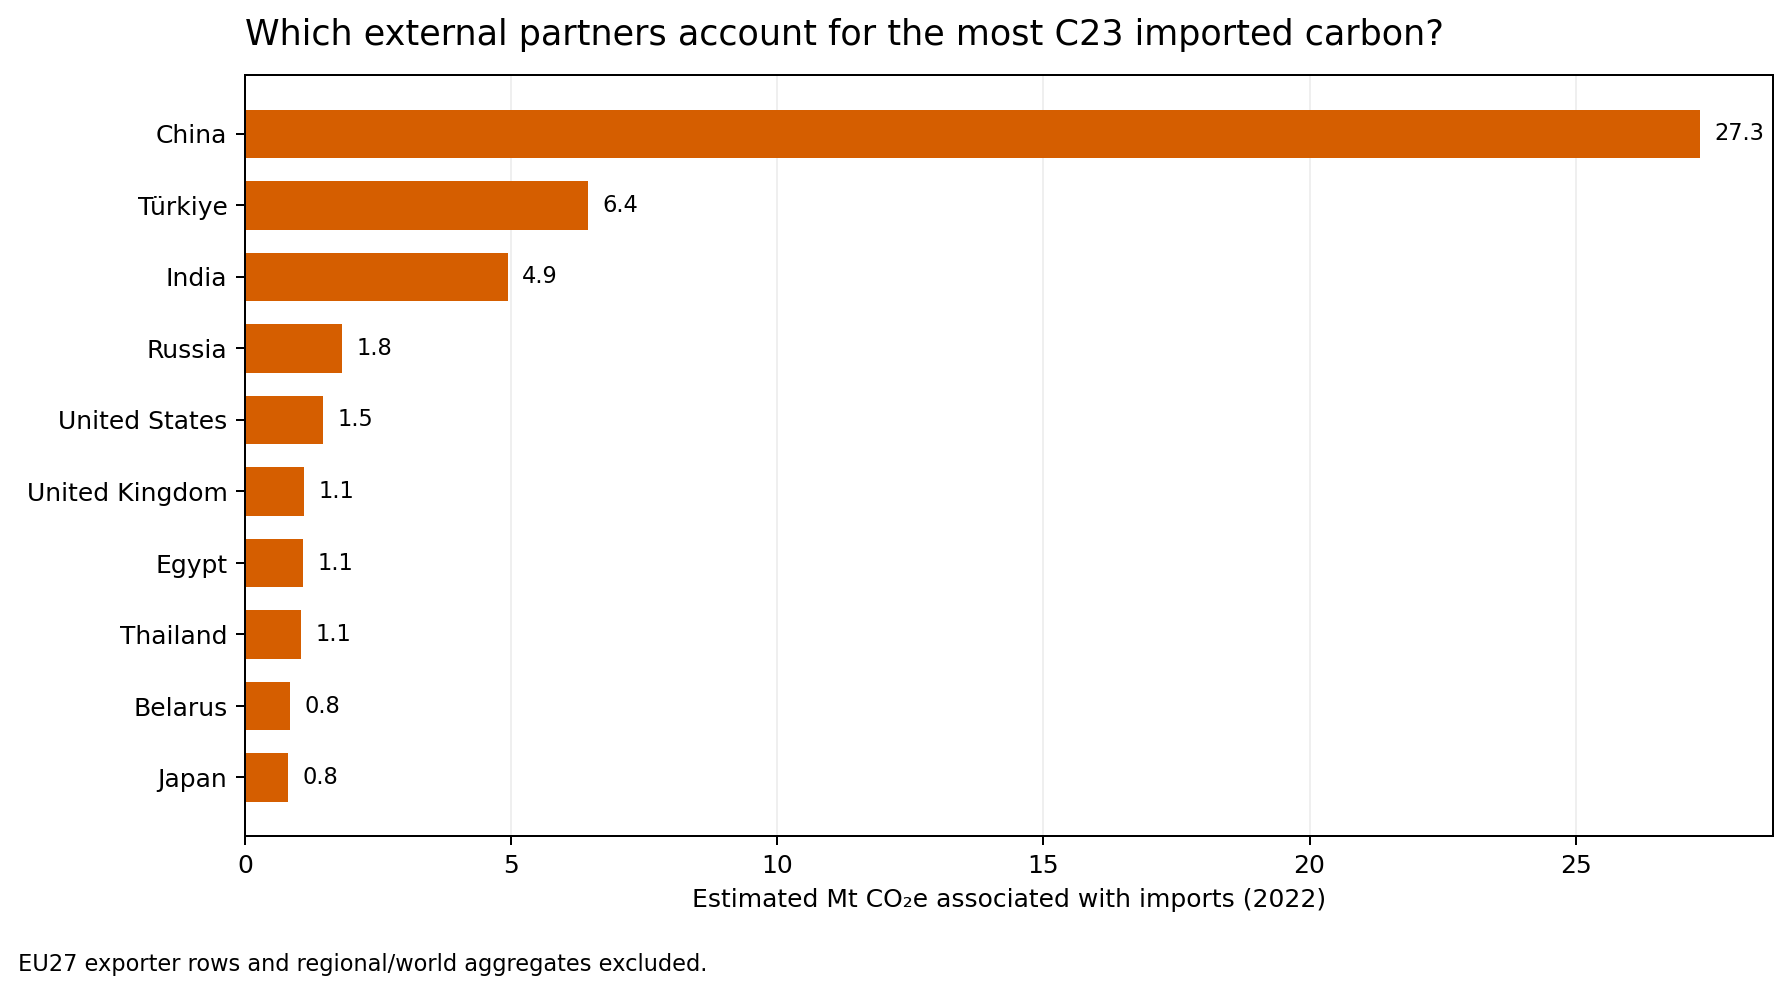

In [5]:
partner_2022 = (_bilat[_bilat['ACTIVITY'].eq('C23') & _bilat['year'].eq(2022)]
                .groupby('EXPORTER')['imported_embodied_ghg_mt'].sum().sort_values(ascending=False).head(10).sort_values())
partner_labels = [PARTNER_NAMES.get(code, code) for code in partner_2022.index]
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(partner_labels, partner_2022.values, color='#D55E00', height=.68)
ax.set_xlabel('Estimated Mt CO₂e associated with imports (2022)')
ax.set_title('Which external partners account for the most C23 imported carbon?', loc='left', fontsize=14, pad=12)
ax.grid(axis='x', alpha=.2); ax.set_axisbelow(True)
for y, value in enumerate(partner_2022.values): ax.text(value + max(partner_2022.values)*.01, y, f'{value:.1f}', va='center', fontsize=9)
fig.text(.01, .01, 'EU27 exporter rows and regional/world aggregates excluded.', fontsize=9)
fig.tight_layout(rect=[0, .04, 1, 1])
fig.savefig(PRESENTATION_DIR / '05-leading-external-partners-c23.png', dpi=180, bbox_inches='tight')
plt.show()


### 6. How the partner mix changed

This stacked area chart shows each partner’s share of estimated C23 carbon in imports from 2008 to 2022. The five largest partners over the full period are shown individually; all remaining extra-EU exporters are combined as “Other partners.”

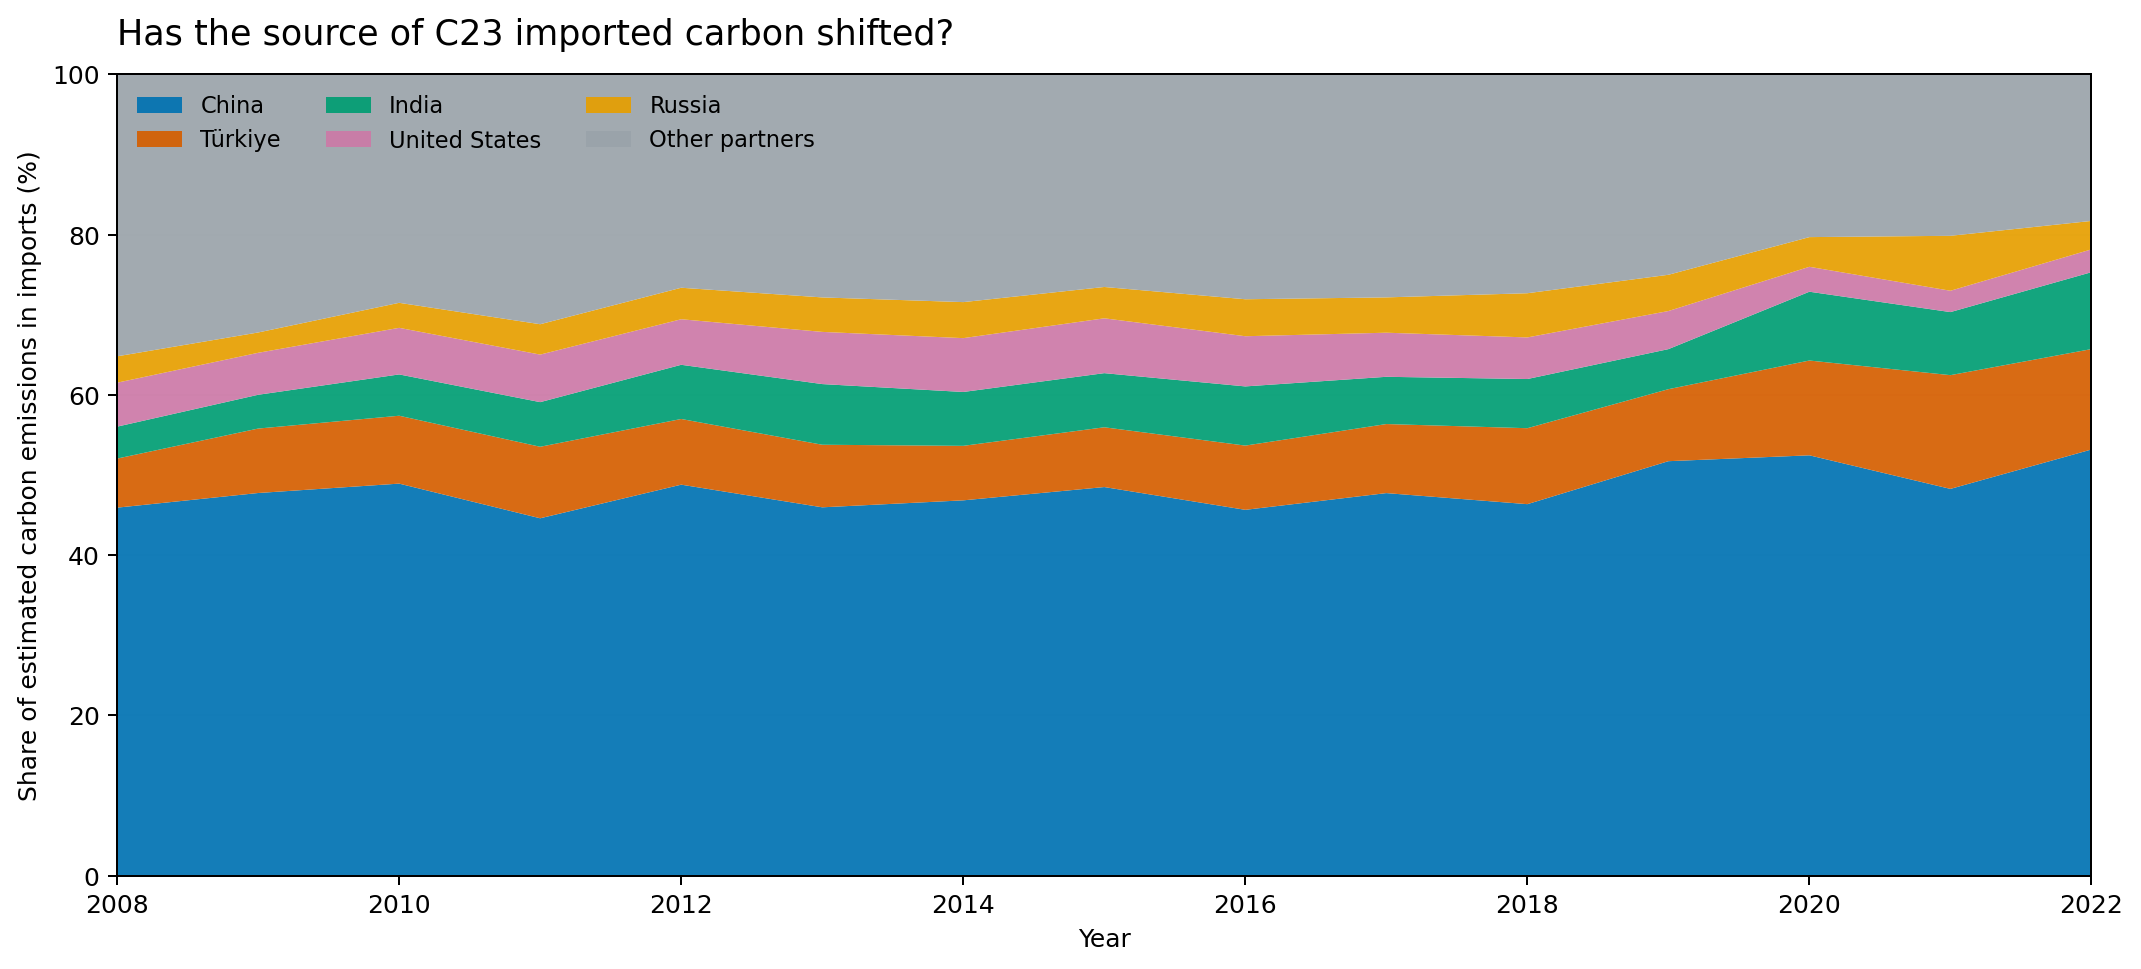

In [6]:
partner_year = (_bilat[_bilat['ACTIVITY'].eq('C23')]
                .groupby(['year', 'EXPORTER'])['imported_embodied_ghg_mt'].sum().unstack(fill_value=0))
leaders = partner_year.sum(axis=0).sort_values(ascending=False).head(5).index.tolist()
partner_mix = partner_year[leaders].copy()
partner_mix['Other partners'] = partner_year.drop(columns=leaders).sum(axis=1)
partner_mix = partner_mix.div(partner_mix.sum(axis=1), axis=0) * 100
partner_mix = partner_mix.rename(columns={c: PARTNER_NAMES.get(c, c) for c in leaders})
fig, ax = plt.subplots(figsize=(12, 5.5))
colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#9AA3AA']
ax.stackplot(partner_mix.index, [partner_mix[c] for c in partner_mix.columns], labels=partner_mix.columns, colors=colors, alpha=.92)
ax.set_ylim(0, 100); ax.set_xlim(2008, 2022)
ax.set_ylabel('Share of estimated carbon emissions in imports (%)'); ax.set_xlabel('Year')
ax.set_title('Has the source of C23 imported carbon shifted?', loc='left', fontsize=14, pad=12)
ax.legend(loc='upper left', ncol=3, frameon=False, fontsize=9)
ax.grid(axis='y', alpha=.18); ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / '06-partner-mix-c23.png', dpi=180, bbox_inches='tight')
plt.show()


### 7. Data and event timeline

The figure aligns the C23 trend with a small number of policy and geopolitical events. The markers provide historical context only; they do not show that an event caused a change in emissions or trade. The observation series ends in 2022.

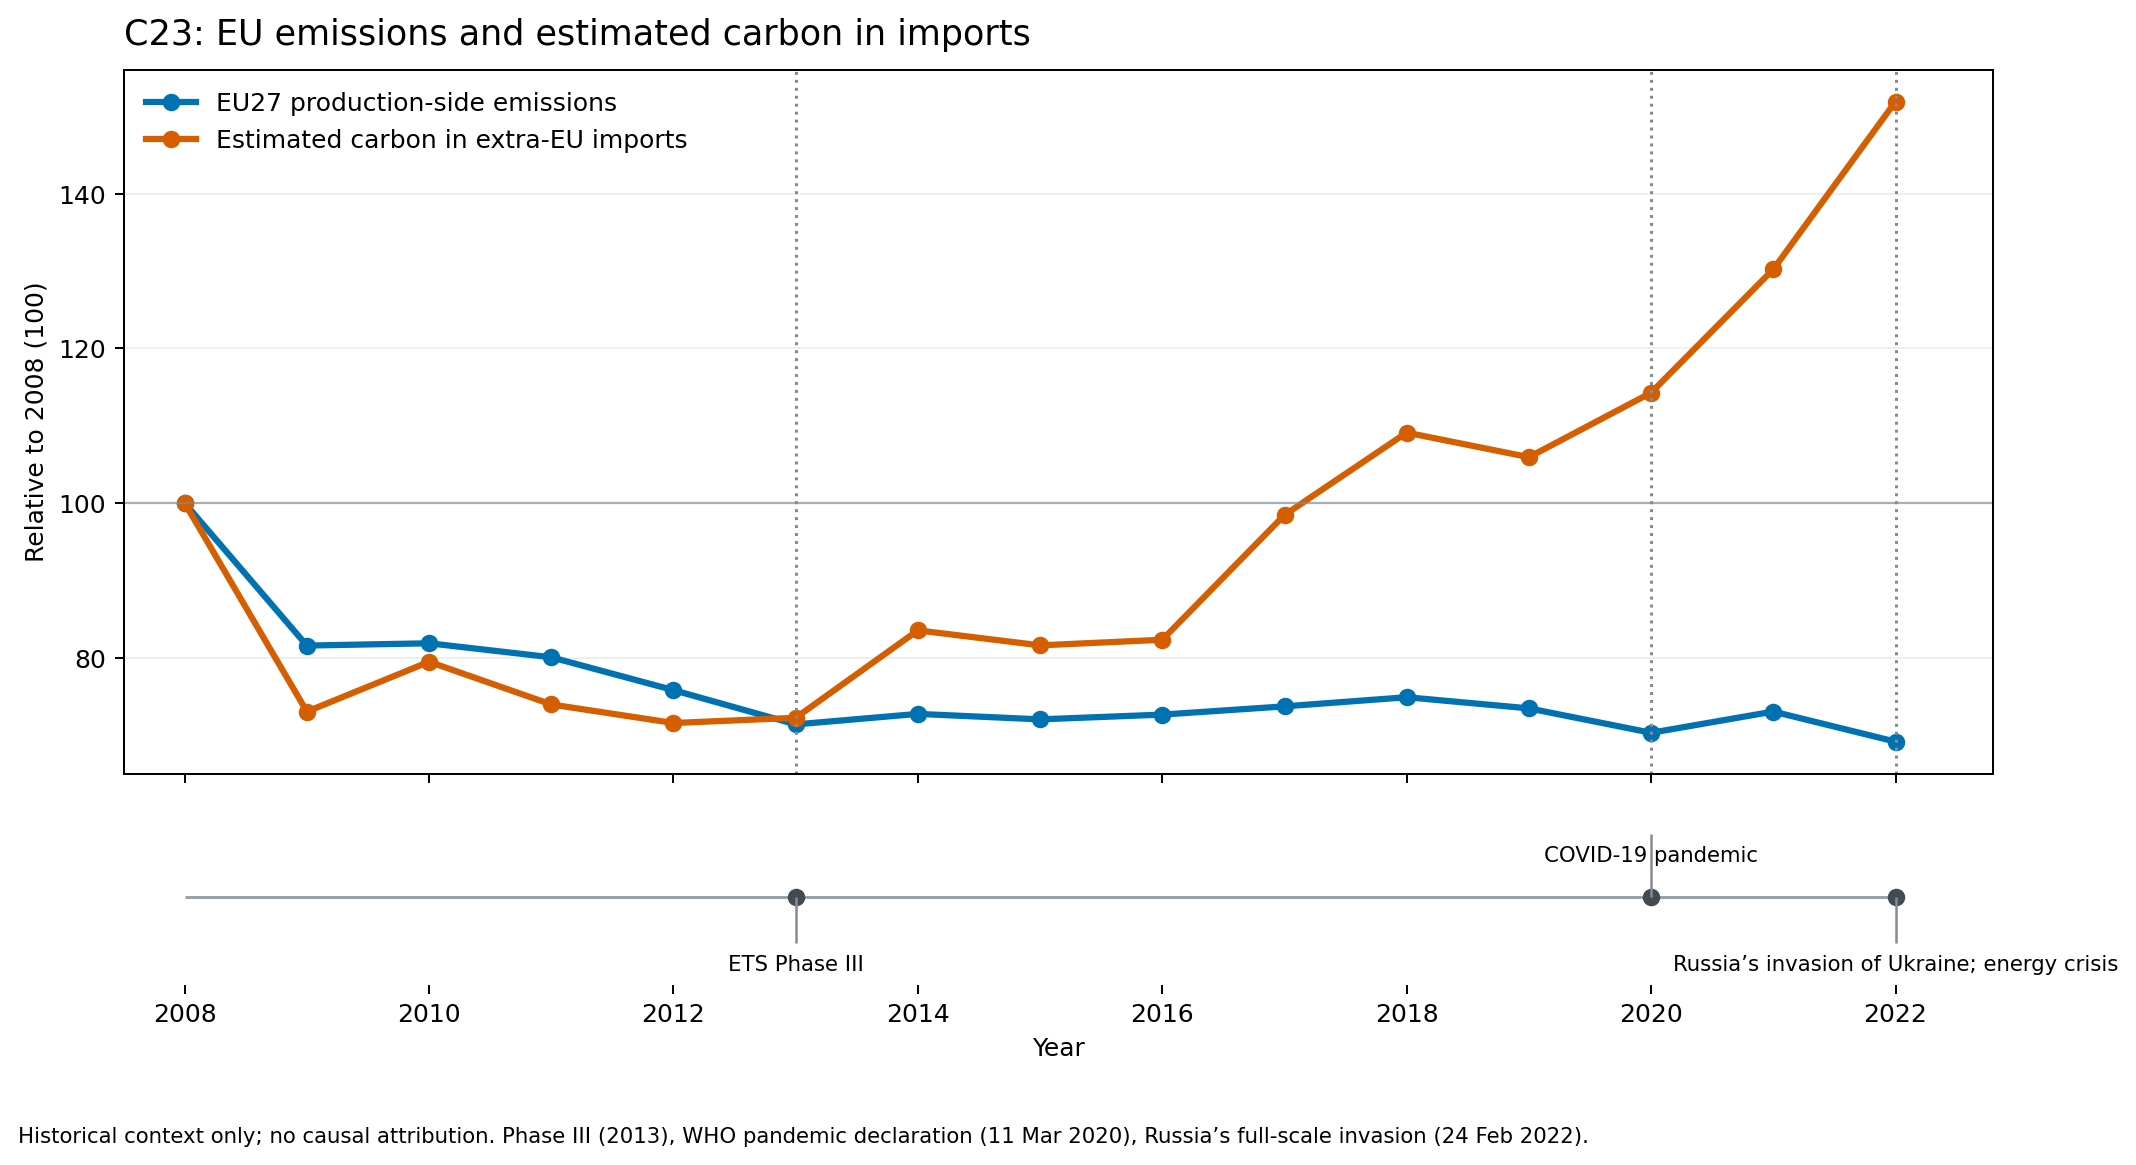

In [7]:
c23 = trend_panel[trend_panel['sector'].eq('C23')].sort_values('year').copy()
c23['domestic_index'] = c23['domestic_emissions_mt'] / c23['domestic_emissions_mt'].iloc[0] * 100
c23['imported_index'] = c23['imported_embodied_ghg_mt'] / c23['imported_embodied_ghg_mt'].iloc[0] * 100
fig, (ax, events_ax) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, gridspec_kw={'height_ratios':[4, 1]})
ax.plot(c23['year'], c23['domestic_index'], color='#0072B2', marker='o', linewidth=2.5, label='EU27 production-side emissions')
ax.plot(c23['year'], c23['imported_index'], color='#D55E00', marker='o', linewidth=2.5, label='Estimated carbon in extra-EU imports')
for year in [2013, 2020, 2022]: ax.axvline(year, color='#858b92', linestyle=':', linewidth=1.2)
ax.axhline(100, color='#858b92', linewidth=.9, alpha=.65)
ax.set_ylabel('Relative to 2008 (100)'); ax.grid(axis='y', alpha=.2); ax.legend(frameon=False, loc='upper left')
ax.set_title('C23: EU emissions and estimated carbon in imports', loc='left', fontsize=14, pad=10)
events_ax.set_ylim(0, 1); events_ax.set_yticks([]); events_ax.set_xlabel('Year')
events_ax.hlines(.5, 2008, 2022, color='#9aa3aa', linewidth=1.2)
event_specs = [(2013, 'ETS Phase III', .06), (2020, 'COVID-19 pandemic', .68), (2022, 'Russia’s invasion of Ukraine; energy crisis', .06)]
for year, label, label_y in event_specs:
    events_ax.plot(year, .5, 'o', color='#424a52', markersize=6)
    events_ax.vlines(year, min(.5, label_y + .18), max(.5, label_y + .18), color='#858b92', linewidth=1)
    events_ax.text(year, label_y, label, ha='center', va='bottom', fontsize=8.5)
events_ax.set_xlim(2007.5, 2022.8); events_ax.spines[['left','right','top','bottom']].set_visible(False)
fig.text(.01, .015, 'Historical context only; no causal attribution. Phase III (2013), WHO pandemic declaration (11 Mar 2020), Russia’s full-scale invasion (24 Feb 2022).', fontsize=8.5)
fig.tight_layout(rect=[0, .06, 1, 1])
fig.savefig(PRESENTATION_DIR / '07-events-context-c23.png', dpi=180, bbox_inches='tight')
plt.show()


### Presentation notes

- Begin with the four-indicator sector screen in Section 11, then use the earlier C23 map and partner charts for geographic context.
- Show the three source-checked project-report examples in Section 12 as a separate form of evidence; explain the two additional secondary-source leads as leads, not confirmed report findings.
- Use Section 13 to explain what is needed before making a causal claim, then Section 14 to frame the 2030 scenarios.
- Present the event timeline as context, not explanation.
- Keep statistical test tables, units, source descriptions, and data limitations available in the earlier notebook sections.

The industry figures are based on broad proxies and include values rather than matched physical quantities. They identify descriptive leads; they do not establish carbon leakage or its cause.


### 8. Emissions embodied in extra-EU imports and exports

This comparison adds the other side of EU27 trade. **Imports minus exports** is the embodied-emissions trade balance: a positive value means the emissions associated with extra-EU imports exceed those associated with EU27 exports in that sector and year. The left-hand panels show the two flows; the right-hand panels show their difference around a zero line.

The OECD estimates cover C19 (coke and refined petroleum), C20 (chemicals), and C23 (other non-metallic mineral products) in both directions in this extract. C17 and C24 export observations are unavailable, so they are not treated as zero and do not appear in the balance chart. These estimates are sector-level modeled trade footprints, not direct product measurements. A positive balance provides context for the leakage-risk analysis; it does not show that EU production moved abroad or establish why the balance changed.

The endpoint table and yearly chart use Mt CO₂e. The CSV saved below keeps one row per sector-year and preserves missing values where one trade direction is unavailable.

,sector,sector_label,2008_imports_mt,2008_exports_mt,2008_net_imports_mt,2022_imports_mt,2022_exports_mt,2022_net_imports_mt,change_in_net_imports_2008_2022_mt
0,C19,Coke and refined petroleum,102.1,68.6,33.4,133.5,46.4,87.1,53.7
1,C20,Chemicals,126.2,100.8,25.4,139.3,97.0,42.3,16.9
2,C23,Other non-metallic mineral products,33.8,28.6,5.2,51.4,29.5,21.9,16.7


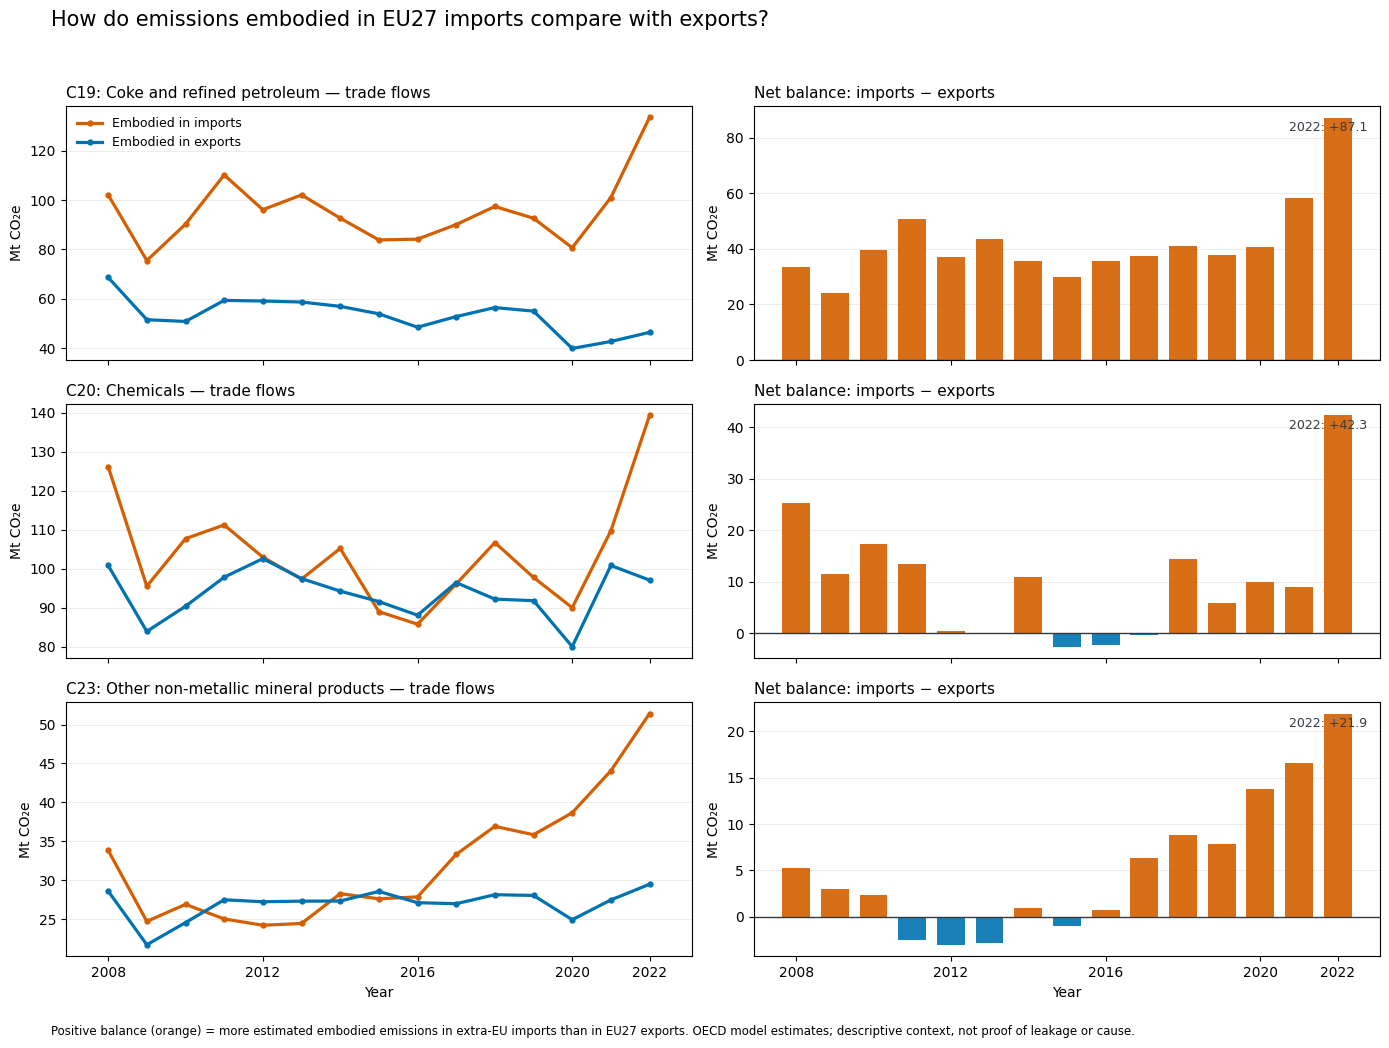

Saved annual trade-balance table to: C:\Users\User\Documents\Codex\2026-09-23\i\outputs\eu27_embodied_emissions_trade_balance_2008_2022.csv
Saved comparison chart to: C:\Users\User\Documents\Codex\2026-09-23\i\outputs\carbon_leakage_figures\08-embodied-emissions-imports-exports-balance.png


In [4]:
# Summarize comparable endpoints, preserving unavailable flows as missing.
TRADE_GAP_OUTPUT = OUTPUT_DIR / 'eu27_embodied_emissions_trade_balance_2008_2022.csv'
trade_gap_summary_rows = []
trade_gap_sectors = [s for s in PRESENTATION_SECTORS if s in set(trade_embodied_panel.loc[trade_embodied_panel['net_embodied_trade_mt'].notna(), 'sector'])]
for sector in trade_gap_sectors:
    row = {'sector': sector, 'sector_label': PRESENTATION_LABELS[sector]}
    for year in [2008, 2022]:
        d = trade_embodied_panel[(trade_embodied_panel['sector'].eq(sector)) & (trade_embodied_panel['year'].eq(year))]
        if d.empty:
            continue
        obs = d.iloc[0]
        row[f'{year}_imports_mt'] = obs['imported_embodied_ghg_mt']
        row[f'{year}_exports_mt'] = obs['exported_embodied_ghg_mt']
        row[f'{year}_net_imports_mt'] = obs['net_embodied_trade_mt']
    row['change_in_net_imports_2008_2022_mt'] = row.get('2022_net_imports_mt', np.nan) - row.get('2008_net_imports_mt', np.nan)
    trade_gap_summary_rows.append(row)
trade_gap_summary = pd.DataFrame(trade_gap_summary_rows)
display(trade_gap_summary.round(1))

trade_embodied_panel.sort_values(['sector', 'year']).to_csv(TRADE_GAP_OUTPUT, index=False)

# Gross flows and the net balance are separated into adjacent panels so the
# audience can read each without switching scales or interpreting a dual axis.
fig, axes = plt.subplots(len(trade_gap_sectors), 2, figsize=(14, 3.4 * len(trade_gap_sectors)), sharex=True)
if len(trade_gap_sectors) == 1:
    axes = np.array([axes])
for row_idx, sector in enumerate(trade_gap_sectors):
    d = trade_embodied_panel[trade_embodied_panel['sector'].eq(sector)].sort_values('year')
    ax_flows, ax_balance = axes[row_idx]
    ax_flows.plot(d['year'], d['imported_embodied_ghg_mt'], color='#D55E00', lw=2.3, marker='o', ms=3.5, label='Embodied in imports')
    ax_flows.plot(d['year'], d['exported_embodied_ghg_mt'], color='#0072B2', lw=2.3, marker='o', ms=3.5, label='Embodied in exports')
    ax_flows.set_title(f'{sector}: {PRESENTATION_LABELS[sector]} — trade flows', loc='left', fontsize=11)
    ax_flows.set_ylabel('Mt CO₂e')
    ax_flows.grid(axis='y', alpha=.22)
    ax_flows.set_axisbelow(True)
    balance = d['net_embodied_trade_mt']
    colors = np.where(balance >= 0, '#D55E00', '#0072B2')
    ax_balance.bar(d['year'], balance, color=colors, width=.72, alpha=.9)
    ax_balance.axhline(0, color='#343a40', linewidth=1)
    ax_balance.set_title('Net balance: imports − exports', loc='left', fontsize=11)
    ax_balance.set_ylabel('Mt CO₂e')
    ax_balance.grid(axis='y', alpha=.22)
    ax_balance.set_axisbelow(True)
    latest = d.loc[d['year'].eq(2022), 'net_embodied_trade_mt']
    if not latest.empty:
        ax_balance.text(.98, .94, f'2022: {latest.iloc[0]:+.1f}', transform=ax_balance.transAxes,
                        ha='right', va='top', fontsize=9, color='#343a40')
for ax in axes[-1]:
    ax.set_xlabel('Year')
    ax.set_xticks([2008, 2012, 2016, 2020, 2022])
axes[0, 0].legend(frameon=False, loc='upper left', fontsize=9)
fig.suptitle('How do emissions embodied in EU27 imports compare with exports?', x=.04, ha='left', fontsize=15, y=1.01)
fig.text(.04, .005, 'Positive balance (orange) = more estimated embodied emissions in extra-EU imports than in EU27 exports. OECD model estimates; descriptive context, not proof of leakage or cause.', fontsize=8.5)
fig.tight_layout(rect=[0, .025, 1, .985])
fig.savefig(PRESENTATION_DIR / '08-embodied-emissions-imports-exports-balance.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved annual trade-balance table to:', TRADE_GAP_OUTPUT)
print('Saved comparison chart to:', PRESENTATION_DIR / '08-embodied-emissions-imports-exports-balance.png')

## 7. Monetary perspective: real output and carbon-value equivalents

This section adds an economic scale to the descriptive leakage-risk signals. It estimates industrial gross output in **constant 2020 euros** using Eurostat Air Emissions Accounts emissions intensities at current prices to reconstruct member-state output values. Those nominal values are summed across EU27 members and deflated with a NACE-specific Eurostat domestic-market Producer Price Index (PPI), rebased to 2020. The PPI is an industry price proxy based on domestic-market prices and may not reflect export-price changes; treat the resulting values as approximate real gross-output estimates, not physical production tonnes.

It also translates emissions into a **hypothetical carbon-value equivalent**. The calculation applies the 2022 average EU ETS allowance price (€80.18 per tCO₂e) to each year's emissions and rebases that price to 2020 euros using the EU27 all-items HICP. Holding the price constant isolates changes in emissions from carbon-market price movements. Domestic GHG and OECD-estimated extra-EU embodied GHG are both shown where available.

These carbon-value equivalents are scenario benchmarks. Domestic Air Emissions Accounts are not the same as verified EU ETS emissions, and modeled emissions embodied in imports were not charged this EU ETS price in the historical period. The figures therefore are not actual compliance costs, import costs, credits, revenue, or a monetary estimate of leakage. Product-level trade values and compatible quantity data remain necessary for that analysis.

Sources: [Eurostat Air Emissions Accounts intensity dataset (env_ac_aeint_r2)](https://ec.europa.eu/eurostat/databrowser/view/env_ac_aeint_r2/default/table); [Eurostat producer prices in industry (sts_inppd_m)](https://ec.europa.eu/eurostat/databrowser/view/sts_inppd_m/default/table); [Eurostat annual HICP (prc_hicp_aind)](https://ec.europa.eu/eurostat/databrowser/view/prc_hicp_aind/default/table); [EEA Trends and projections in the EU ETS, 2025, section 1.2](https://www.eionet.europa.eu/etcs/etc-cm/products/etc-cm-report-2025-06/@@download/file/ETS-Report_2025_final.pdf).

The annual EU27 HICP and industry PPI series are cached in `F:\Carbon Leak\external_data`. The PPI index is averaged from monthly observations and rebased to 2020 for gross-output estimates. HICP is used only to express the €80.18 2022 reference price in 2020 euros.


In [44]:
# Monetary layer: constant-price gross output and a fixed-price carbon-value scenario.
# Reconstruct nominal output by country from matched AEA emissions and intensity, then sum.
AEA_CURRENT_INTENSITY_PATH = EXTERNAL_DIR / 'eurostat_aea_intensity_eu27_ghg_output_currentprices.csv'
HICP_PATH = EXTERNAL_DIR / 'eurostat_hicp_eu27_annual_2008_2022.csv'
PPI_PATH = EXTERNAL_DIR / 'eurostat_eu27_domestic_ppi_annual_C17_C24_2008_2022.csv'

_current_intensity = pd.read_csv(AEA_CURRENT_INTENSITY_PATH, low_memory=False)
_current_intensity = _current_intensity[
    _current_intensity['geo'].isin(EU27_EUROSTAT_GEO)
    & _current_intensity['nace_r2'].isin(ANALYSIS_SECTORS)
    & _current_intensity['unit'].eq('G_EUR_CP')
    & _current_intensity['airpol'].eq('GHG')
    & _current_intensity['na_item'].eq('P1')
].copy()
_current_intensity['year'] = _current_intensity['time'].astype(int)
_current_intensity = _current_intensity.rename(columns={'nace_r2':'sector','OBS_VALUE':'ghg_g_per_current_eur'})
_em_money = _em[['geo','nace_r2','year','OBS_VALUE']].rename(columns={'nace_r2':'sector','OBS_VALUE':'emissions_kt'})
_country_money = _em_money.merge(
    _current_intensity[['geo','sector','year','ghg_g_per_current_eur']],
    on=['geo','sector','year'], how='inner', validate='one_to_one'
)
# kt emissions / (g GHG per current EUR) yields billions of current euros.
_country_money['nominal_output_eur_bn'] = (
    _country_money['emissions_kt'] / _country_money['ghg_g_per_current_eur']
)
_nominal_output = (
    _country_money.groupby(['sector','year'], as_index=False)
    .agg(nominal_output_eur_bn=('nominal_output_eur_bn','sum'),
         domestic_emissions_mt=('emissions_kt',lambda s:s.sum()/1000),
         countries=('geo','nunique'))
)

# Annual-average domestic-market PPI (2021=100), by sector.
if not PPI_PATH.exists():
    _ppi_monthly = fetch_eurostat_json('sts_inppd_m', {
        'geo':'EU27_2020','nace_r2':ANALYSIS_SECTORS,
        'indic_bt':'PRC_PRR_DOM','unit':'I21','s_adj':'NSA',
        'sinceTimePeriod':'2008-01','untilTimePeriod':'2022-12'
    })
    _ppi_monthly['year'] = _ppi_monthly['time'].astype(str).str[:4].astype(int)
    _ppi_annual = (_ppi_monthly.groupby(['nace_r2','year'],as_index=False)['OBS_VALUE'].mean()
                   .rename(columns={'nace_r2':'sector','OBS_VALUE':'domestic_ppi_2021_100'}))
    _ppi_annual.to_csv(PPI_PATH,index=False)
else:
    _ppi_annual = pd.read_csv(PPI_PATH)
_ppi_2020 = _ppi_annual[_ppi_annual['year'].eq(2020)].set_index('sector')['domestic_ppi_2021_100']
_ppi_annual = _ppi_annual.merge(_ppi_2020.rename('domestic_ppi_2020'),on='sector',how='left')
real_gross_output = _nominal_output.merge(_ppi_annual,on=['sector','year'],how='inner',validate='one_to_one')
real_gross_output['gross_output_2020_eur_bn'] = (
    real_gross_output['nominal_output_eur_bn']
    * real_gross_output['domestic_ppi_2020']
    / real_gross_output['domestic_ppi_2021_100']
)
real_gross_output = real_gross_output[real_gross_output['year'].between(2008,2022)]

# Use cached Eurostat HICP when available; otherwise retrieve the small EU27 series.
if not HICP_PATH.exists():
    _hicp = fetch_eurostat_json('prc_hicp_aind', {
        'geo':'EU27_2020','coicop':'CP00','unit':'INX_A_AVG','freq':'A',
        'sinceTimePeriod':'2008','untilTimePeriod':'2022'
    })
    _hicp['year'] = _hicp['time'].astype(int)
    _hicp.rename(columns={'OBS_VALUE':'hicp_index'}).to_csv(HICP_PATH,index=False)
hicp = pd.read_csv(HICP_PATH)
hicp_2020 = float(hicp.loc[hicp['year'].eq(2020),'hicp_index'].iloc[0])
hicp_2022 = float(hicp.loc[hicp['year'].eq(2022),'hicp_index'].iloc[0])
EUA_2022_EUR_PER_T = 80.18
carbon_price_2020_eur_per_t = EUA_2022_EUR_PER_T * hicp_2020 / hicp_2022

monetary_panel = real_gross_output.merge(extra_eu_embodied,on=['sector','year'],how='left')
monetary_panel['domestic_carbon_value_2020_eur_bn'] = (
    monetary_panel['domestic_emissions_mt']*carbon_price_2020_eur_per_t/1000
)
monetary_panel['imported_carbon_value_2020_eur_bn'] = (
    monetary_panel['imported_embodied_ghg_mt']*carbon_price_2020_eur_per_t/1000
)
monetary_panel=monetary_panel.sort_values(['sector','year'])
print(f'2022 EUA benchmark: €{EUA_2022_EUR_PER_T:.2f}/tCO₂e')
print(f'Rebased benchmark: €{carbon_price_2020_eur_per_t:.2f}/tCO₂e in 2020 euros')
print('EU27 sector-years with real gross output:',len(real_gross_output))
print('Sectors with comparable OECD extra-EU embodied-GHG values:',sorted(monetary_panel.loc[monetary_panel['imported_embodied_ghg_mt'].notna(),'sector'].unique()))


2022 EUA benchmark: €80.18/tCO₂e
Rebased benchmark: €71.37/tCO₂e in 2020 euros
Country-sector-year output observations: 1170
Sectors with comparable OECD extra-EU embodied-GHG values: ['C19', 'C20', 'C23']


### Real gross output and hypothetical carbon-value equivalents

The first chart shows gross output after removing NACE-specific domestic producer-price inflation, expressed in 2020 euros. Member-state current-price output estimates are summed before deflation; the PPI is an industry price proxy, so treat these real output estimates as approximate. The second chart uses one benchmark carbon price across every year, so its movement comes from the emissions series rather than annual EUA price swings.


### Does real gross output show a declining trend?

A one-sided Spearman trend screen tests whether each sector's annual gross output in constant 2020 euros declined over 2008–2022. Benjamini–Hochberg adjustment covers the five sector tests. This is an exploratory monotonic trend check; it does not account for serial correlation. The carbon-value series uses emissions multiplied by a constant price and is therefore not tested separately from the underlying emissions trends.


In [48]:
# One-sided Spearman trend screen for real gross output (expected direction: decrease).
_output_test_rows=[]
for sector in ANALYSIS_SECTORS:
    d=monetary_panel[monetary_panel['sector'].eq(sector)].dropna(
        subset=['gross_output_2020_eur_bn']
    ).sort_values('year')
    result=spearmanr(d['year'],d['gross_output_2020_eur_bn'],alternative='less')
    _output_test_rows.append({
        'sector':sector,'sector_name':PRESENTATION_LABELS[sector],
        'n_years':len(d),'spearman_rho':result.statistic,
        'p_one_sided':result.pvalue,
    })
output_trend_tests=pd.DataFrame(_output_test_rows)
output_trend_tests['q_bh']=benjamini_hochberg(output_trend_tests['p_one_sided'])
output_trend_tests['declining_trend_q_lt_05']=(
    output_trend_tests['spearman_rho'].lt(0)&output_trend_tests['q_bh'].lt(.05)
)
_test_view=output_trend_tests.copy()
for _pcol in ['p_one_sided','q_bh']:
    _test_view[_pcol]=_test_view[_pcol].map(lambda value:'<0.0001' if value<0.0001 else f'{value:.4f}')
display(_test_view.round({'spearman_rho':3}))


sector            sector_name  n_years  spearman_rho p_one_sided   q_bh  declining_trend_q_lt_05
   C17         Paper products       15         0.525      0.9778 0.9976                    False
   C19        Coke & refining       15        -0.811      0.0001 0.0006                     True
   C20              Chemicals       15         0.686      0.9976 0.9976                    False
   C23 Other mineral products       15         0.229      0.7937 0.9976                    False
   C24           Basic metals       15        -0.139      0.3103 0.7757                    False

In [45]:
# Endpoint comparison in billions of constant 2020 euros.
monetary_measures = {
    'gross_output_2020_eur_bn':'Gross output',
    'domestic_carbon_value_2020_eur_bn':'Domestic emissions value',
    'imported_carbon_value_2020_eur_bn':'Extra-EU imported-carbon value',
}
_money_rows=[]
for sector in ANALYSIS_SECTORS:
    d=monetary_panel[monetary_panel['sector'].eq(sector)].sort_values('year')
    for column,label in monetary_measures.items():
        z=d.dropna(subset=[column])
        if z.empty: continue
        first,last=z.iloc[0],z.iloc[-1]
        _money_rows.append({
            'sector':sector,'measure':label,
            'start':f"{int(first['year'])}: €{first[column]:,.2f}bn",
            'end':f"{int(last['year'])}: €{last[column]:,.2f}bn",
            'change_pct':(last[column]/first[column]-1)*100 if first[column] else np.nan,
            'years':len(z),
        })
monetary_summary=pd.DataFrame(_money_rows)
display(monetary_summary.round({'change_pct':1}))


sector                        measure           start             end  change_pct  years
   C17                   Gross output 2008: €164.11bn 2022: €169.82bn         3.5     15
   C17       Domestic emissions value   2008: €2.84bn   2022: €2.05bn       -27.9     15
   C19                   Gross output 2008: €321.28bn 2022: €267.61bn       -16.7     15
   C19       Domestic emissions value  2008: €11.22bn   2022: €9.11bn       -18.8     15
   C19 Extra-EU imported-carbon value   2008: €7.28bn   2022: €9.53bn        30.8     15
   C20                   Gross output 2008: €424.34bn 2022: €428.05bn         0.9     15
   C20       Domestic emissions value  2008: €14.25bn   2022: €9.25bn       -35.1     15
   C20 Extra-EU imported-carbon value   2008: €9.01bn   2022: €9.94bn        10.4     15
   C23                   Gross output 2008: €247.71bn 2022: €218.38bn       -11.8     15
   C23       Domestic emissions value  2008: €18.04bn  2022: €12.47bn       -30.9     15
   C23 Extra-EU impor

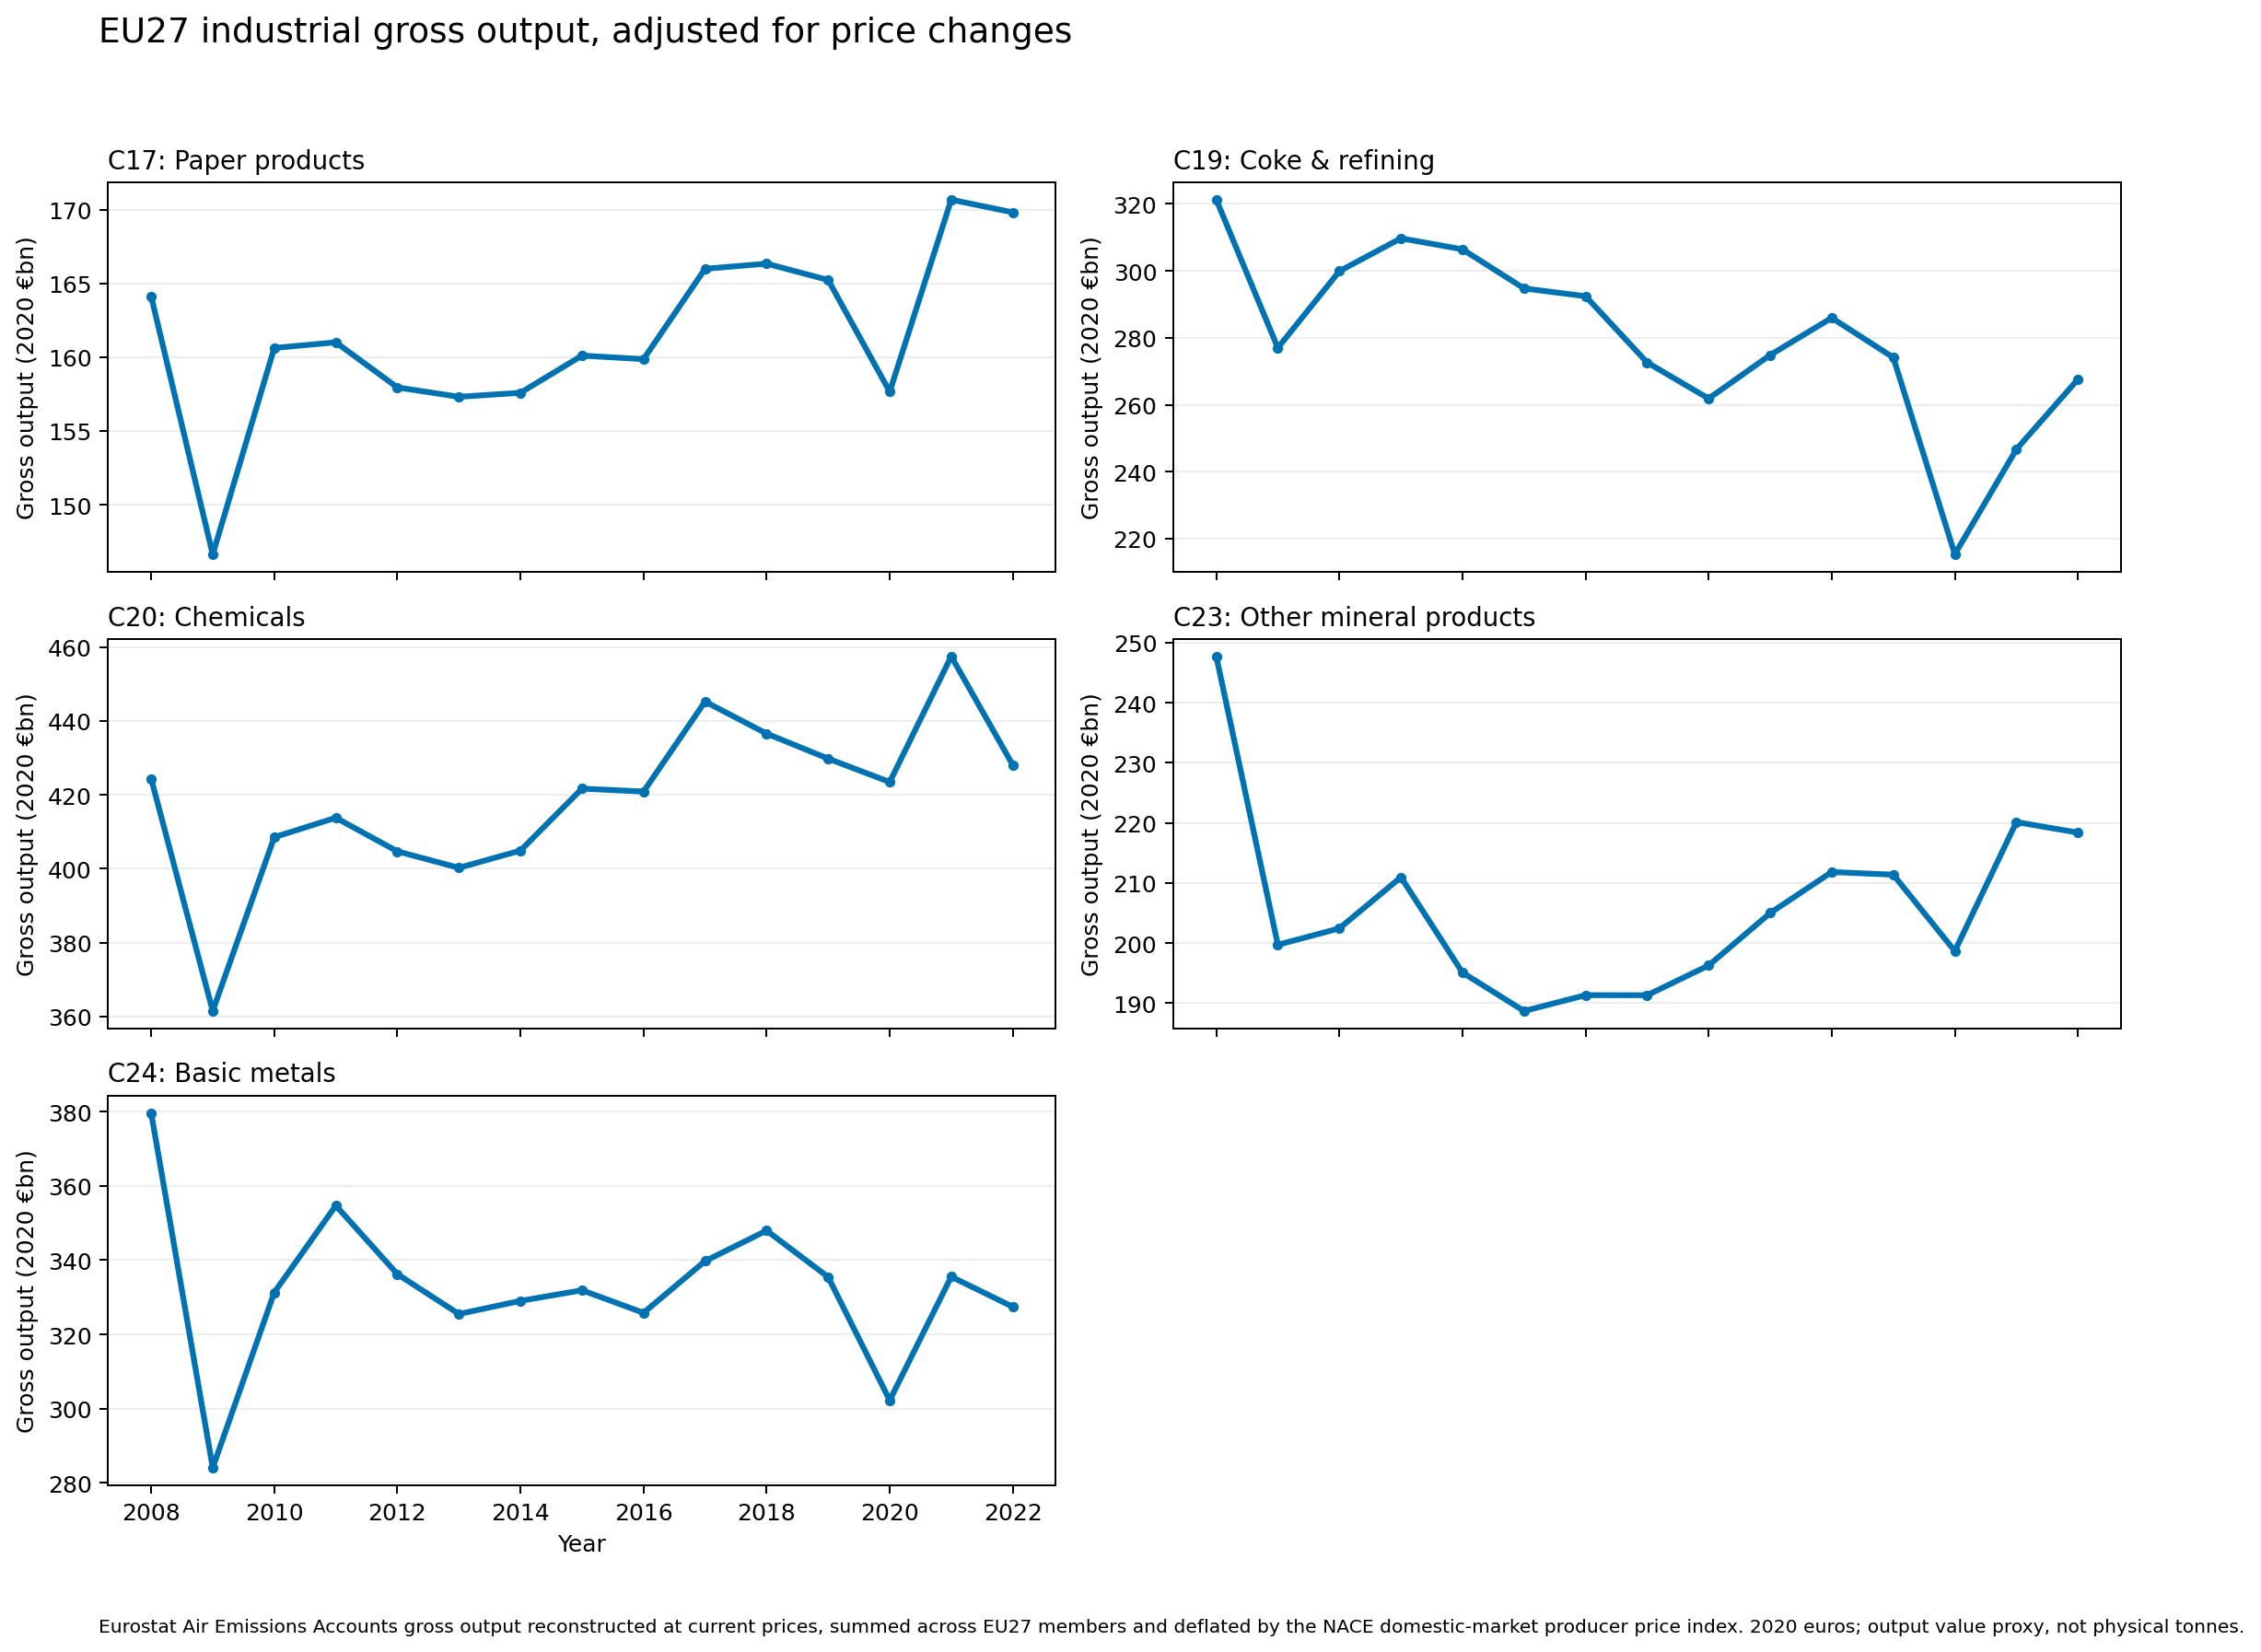

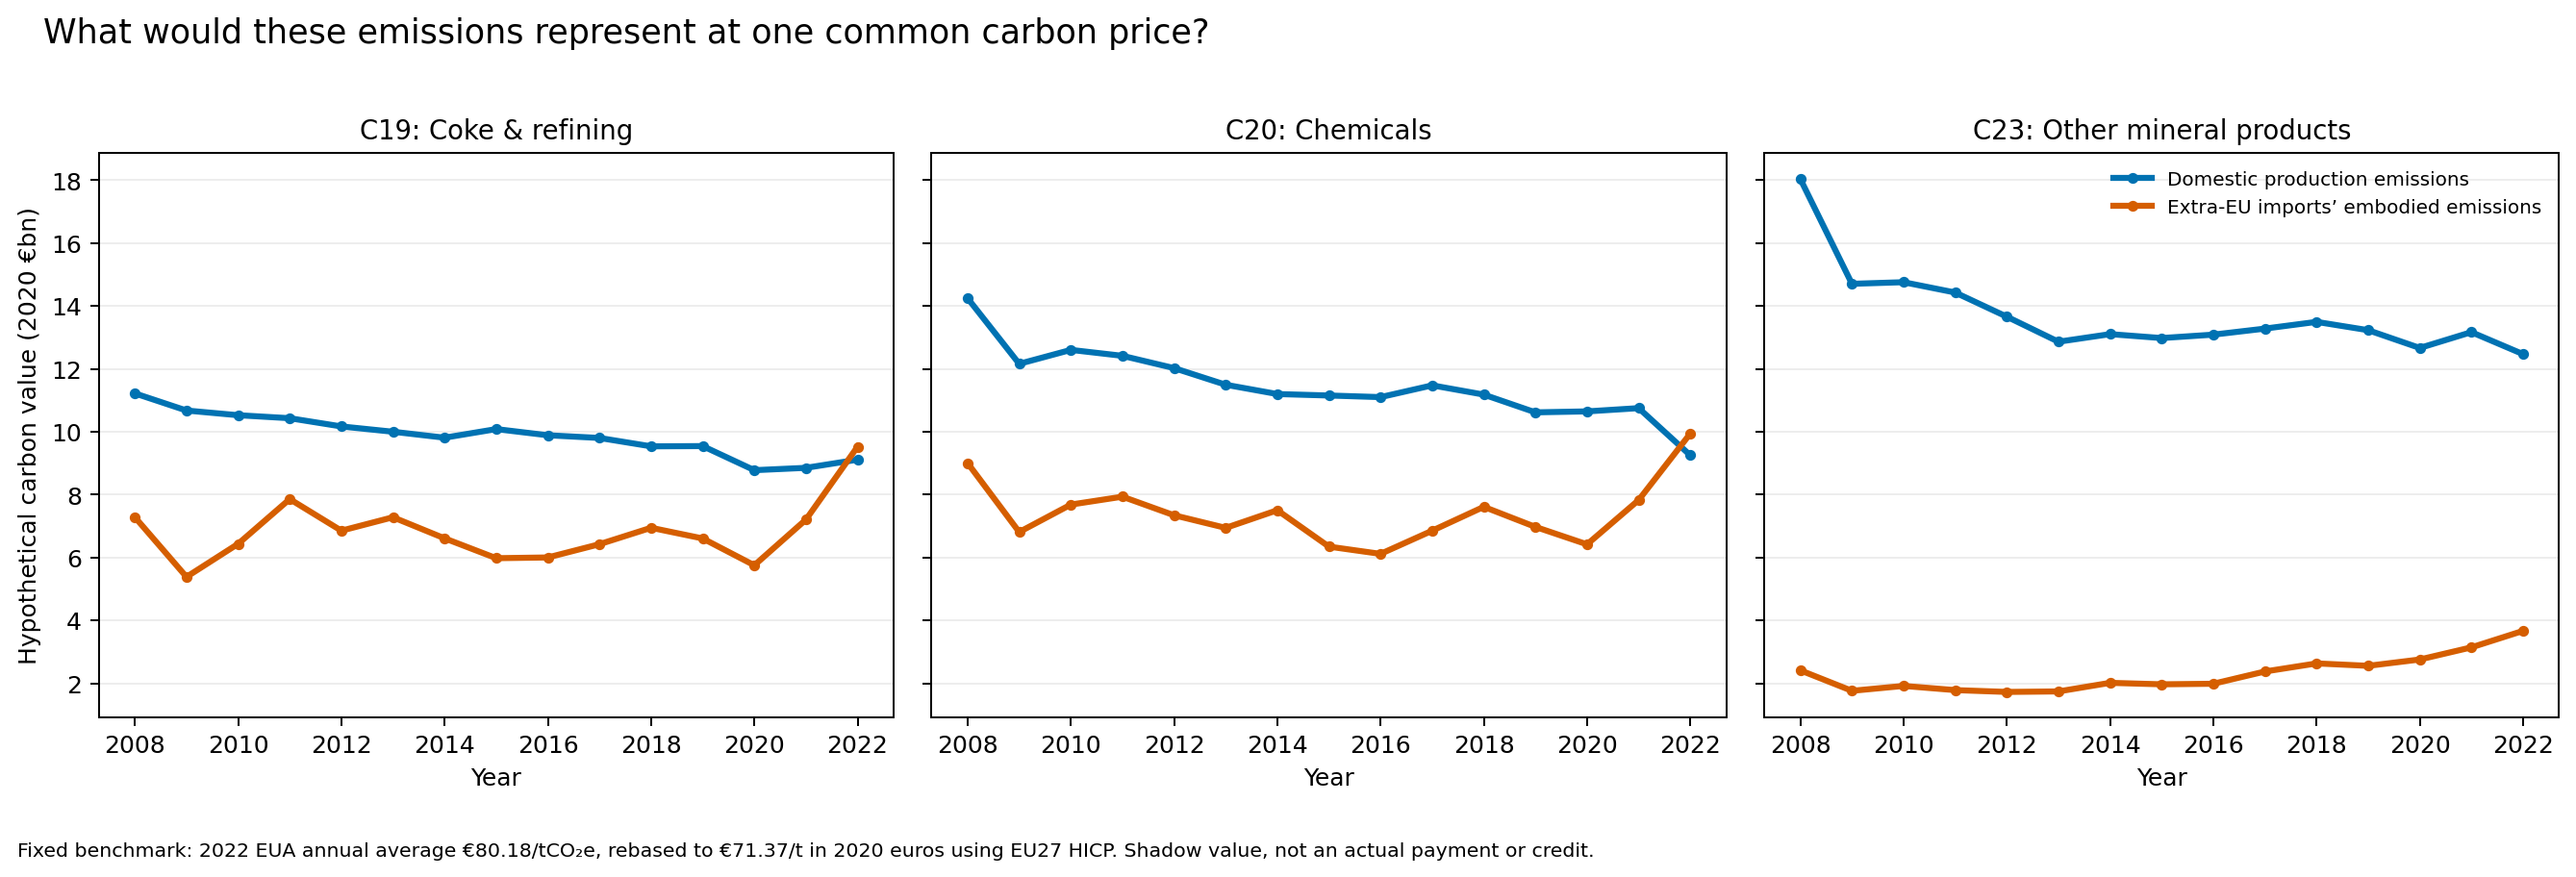

In [46]:
# Real gross output in 2020 euros and a constant-price carbon-value scenario.
MONETARY_LABELS = {'C17':'Paper products','C19':'Coke & refining','C20':'Chemicals','C23':'Other mineral products','C24':'Basic metals'}
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)
for ax, sector in zip(axes.flat, ANALYSIS_SECTORS):
    d=monetary_panel[monetary_panel['sector'].eq(sector)]
    ax.plot(d['year'],d['gross_output_2020_eur_bn'],color='#0072B2',lw=2.5,marker='o',ms=3.5)
    ax.set_title(f"{sector}: {MONETARY_LABELS[sector]}",loc='left',fontsize=11)
    ax.set_ylabel('Gross output (2020 €bn)')
    ax.grid(axis='y',alpha=.22)
axes.flat[-1].axis('off')
for ax in axes[-1,:]: ax.set_xlabel('Year')
fig.suptitle('EU27 industrial gross output, adjusted for price changes',x=.05,ha='left',fontsize=15,y=.99)
fig.text(.05,.015,'Eurostat current-price gross output reconstructed from emissions intensities, then deflated by the NACE domestic-market producer price index. 2020 euros; this is an economic output measure, not physical tonnes.',fontsize=8.5)
fig.tight_layout(rect=[0,.04,1,.96])
fig.savefig(PRESENTATION_DIR/'08-real-gross-output-2020-euros.png',dpi=180,bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, sector in zip(axes,['C19','C20','C23']):
    d=monetary_panel[monetary_panel['sector'].eq(sector)]
    ax.plot(d['year'],d['domestic_carbon_value_2020_eur_bn'],color='#0072B2',lw=2.5,marker='o',ms=3.5,label='Domestic production emissions')
    ax.plot(d['year'],d['imported_carbon_value_2020_eur_bn'],color='#D55E00',lw=2.5,marker='o',ms=3.5,label='Extra-EU imports’ embodied emissions')
    ax.set_title(f"{sector}: {MONETARY_LABELS[sector]}",fontsize=11)
    ax.set_xlabel('Year'); ax.grid(axis='y',alpha=.22)
axes[0].set_ylabel('Hypothetical carbon value (2020 €bn)')
axes[-1].legend(frameon=False,fontsize=8,loc='best')
fig.suptitle('What would these emissions represent at one common carbon price?',x=.02,ha='left',fontsize=14,y=1.02)
fig.text(.01,.01,f'Fixed benchmark: 2022 EUA annual average €{EUA_2022_EUR_PER_T:.2f}/tCO₂e, rebased to €{carbon_price_2020_eur_per_t:.2f}/t in 2020 euros using EU27 HICP. This is a shadow value, not an actual payment or credit.',fontsize=8.2)
fig.tight_layout(rect=[0,.055,1,1])
fig.savefig(PRESENTATION_DIR/'09-shadow-carbon-value-2020-euros.png',dpi=180,bbox_inches='tight')
plt.show()


## 8. Offset-project cross-check: what do the projects actually do?

The earlier analysis looks for leakage-risk patterns in EU industrial production, emissions, imports, and imported carbon. This section adds a separate view of **carbon-offset projects located in EU27 countries**. A project’s host country is not the same as the country where its credits are bought or retired.

Here, project leakage means that an activity restricted or changed inside a project boundary may move somewhere else. For example, lower timber harvest inside a forest project could be offset by more harvesting elsewhere; tree planting could displace grazing or farming. The actual pathway depends on the project and its accounting method. [Verra’s explanation of leakage](https://verra.org/faq/) gives forest-management and tree-planting examples.

OffsetsDB assigns projects a broad **category** and a more specific **project type**. Its documentation says the type is inferred from protocol information and can be manually overridden. These labels help us understand the intended activity, but they are not measurements of leakage. [OffsetsDB classification notes](https://offsets-db-data.readthedocs.io/en/stable/data-processing.html#project-type-categorization).

### Data coverage and first-pass limits

This section uses the CarbonPlan OffsetsDB archive in `F:\Carbon Leak\external_data\offsetsdb_carbonplan_snapshot_2026-06-01.csv.zip`. The archive metadata dates the snapshot to **1 June 2026**; OffsetsDB documentation currently notes that updates are paused, so treat these counts as a dated snapshot rather than a live register. [Data access](https://offsets-db-data.readthedocs.io/en/stable/data-access.html) · [Update notice](https://offsets-db-data.readthedocs.io/en/latest/).

The first filter keeps projects whose recorded project country is one of the EU27 member states. It finds **178 EU27-hosted projects**, of which **35** are in the database’s forest category. This is a project inventory, not an EU-wide measure of all offsets used by EU buyers.

The available project/credit tables include project activity labels and cumulative issued/retired credit totals, but do not include a direct project-level leakage-emissions amount or leakage rate. Therefore this pass can identify project types and possible leakage routes; it cannot quantify actual leakage. To quantify that, we would need each relevant project’s design, monitoring, and verification reports and would extract its methodology-specific leakage deductions or leakage estimates.


In [49]:
# Load the dated CarbonPlan OffsetsDB project table and filter to the EU27 host countries.
from pathlib import Path
from zipfile import ZipFile
import json
import pandas as pd

OFFSETSDB_ZIP = EXTERNAL_DIR / "offsetsdb_carbonplan_snapshot_2026-06-01.csv.zip"
if not OFFSETSDB_ZIP.exists():
    OFFSETSDB_ZIP = DATA_ROOT / "offsets-db.csv.zip"
EU27 = {"Austria","Belgium","Bulgaria","Croatia","Cyprus","Czech Republic","Denmark","Estonia","Finland","France","Germany","Greece","Hungary","Ireland","Italy","Latvia","Lithuania","Luxembourg","Malta","Netherlands","Poland","Portugal","Romania","Slovakia","Slovenia","Spain","Sweden"}

with ZipFile(OFFSETSDB_ZIP) as archive:
    offsetsdb_metadata = json.loads(archive.read("metadata.json"))
    projects_all = pd.read_csv(archive.open("projects.csv"))
    credit_transactions_all = pd.read_csv(
        archive.open("credits.csv"),
        usecols=["project_id", "quantity", "transaction_date", "transaction_type"],
    )

projects_eu27 = projects_all[projects_all["country"].isin(EU27)].copy()
credit_transactions_eu27 = credit_transactions_all[
    credit_transactions_all["project_id"].isin(projects_eu27["project_id"])
].copy()
credit_transactions_eu27["transaction_date"] = pd.to_datetime(
    credit_transactions_eu27["transaction_date"], errors="coerce", utc=True
)
credit_transactions_eu27["transaction_year"] = credit_transactions_eu27["transaction_date"].dt.year
annual_credit_flows = (
    credit_transactions_eu27.loc[credit_transactions_eu27["transaction_type"].isin(["issuance", "retirement"])]
    .groupby(["transaction_year", "transaction_type"], as_index=False)["quantity"]
    .sum()
    .pivot(index="transaction_year", columns="transaction_type", values="quantity")
    .fillna(0)
    .rename_axis("year")
    .reset_index()
    .rename(columns={"issuance": "credits_issued", "retirement": "credits_retired"})
)
annual_credit_flows.to_csv(OUTPUT_DIR / "eu27_hosted_credit_transactions_by_year.csv", index=False)
projects_eu27["project_type_display"] = projects_eu27["project_type"].fillna("Unknown / not classified").replace({"Unknown": "Unknown / not classified"})
print(f"Snapshot date: {offsetsdb_metadata['generated_at']}")
print(f"EU27-hosted project records: {projects_eu27['project_id'].nunique():,}")
print(f"Forest-category project records: {projects_eu27.loc[projects_eu27['category'].eq('forest'),'project_id'].nunique():,}")


### What each recorded project type means

The plain-language descriptions below explain the activity label and the leakage question worth checking. A possible route is a hypothesis to investigate, not evidence that displacement occurred.

| OffsetsDB project type | What the activity means | Possible leakage question |
|---|---|---|
| Unknown / not classified | OffsetsDB does not provide a usable specific activity label for this record. | Open the registry listing and project documents before assigning a leakage pathway. |
| Afforestation + Reforestation | Planting trees on land that is not currently forest, or restoring tree cover where forest has been lost. | Could move farming, grazing, or wood gathering to nearby land. |
| Biochar | Heating biomass with little oxygen to make a stable carbon-rich material that can be added to soil or used in products. | Check whether sourcing biomass changes harvesting, land use, or other uses elsewhere. |
| Biomass | Producing energy from biological material such as wood, crops, or organic waste. | Check where the biomass comes from and whether harvesting or land use increases elsewhere. |
| Centralized Solar | Generating electricity at a larger, grid-connected solar facility. | Check whether it replaces fossil generation in the relevant grid and period. |
| Concrete CCS | Capturing carbon dioxide associated with concrete or cement production for storage or use. | Check whether production or imports shift across locations; project type alone cannot establish industrial leakage. |
| Distributed Solar | Generating electricity with smaller solar systems near where it is used, such as rooftop installations. | Check what electricity source is displaced and whether generation changes elsewhere. |
| Electric Vehicle | Replacing some trips in fuel-burning vehicles with electric vehicles. | Check the electricity mix, vehicle use, and any changes in transport activity outside the project. |
| Feed Additive | Adding a supplement to animal feed intended to reduce methane produced by livestock. | Check for changes in livestock numbers or production outside participating farms. |
| Geothermal | Generating energy using heat from underground. | Check which existing energy supply is displaced and whether that supply moves elsewhere. |
| Hydropower | Generating electricity from moving or stored water. | Check the power sources displaced and any changes in land use or electricity trade. |
| Improved Forest Management | Changing how an existing forest is managed, often by reducing or changing timber harvest and allowing more carbon to remain in the forest. | If less timber is supplied from the project area, harvesting or timber production could shift elsewhere. |
| Manure Biodigester | Treating animal manure in a sealed digester so methane is captured and may be used as biogas. | Check whether livestock or manure handling shifts to other farms; the project type alone does not show that it did. |
| Mine Methane | Capturing or destroying methane released from coal mines, sometimes using the gas for energy. | Check whether the credited activity changes mine output or simply captures gas that would otherwise escape; the label alone cannot show displaced coal production. |
| Ozone Depleting Substances | Collecting and destroying powerful greenhouse gases used in or released from products such as refrigeration equipment and foams. | Check whether production, collection, or disposal of the relevant gases or products shifts elsewhere. |
| Recycling | Recovering materials from waste so they can be used again instead of some newly produced material. | Check whether demand and production of virgin materials actually fall, or move to another market. |
| Rock Weathering | Applying crushed silicate rock to land so chemical reactions gradually remove carbon dioxide from the air. | Check the emissions and land impacts of mining, processing, and transporting rock; the label does not measure them. |
| Shipping | A project classified under shipping, which can include changes in vessel fuels or efficiency depending on its methodology. | The label is broad; the project documents are needed to identify the activity and any route or freight shifts. |
| Sustainable Agriculture | Changing crop, soil, or livestock practices to reduce emissions or increase carbon stored in soils and vegetation. | If the project reduces output or restricts land use, production could shift to other farms or regions. |
| Waste Diversion | Keeping waste out of landfill through reuse, recycling, composting, or other treatment. | Check whether waste is actually avoided or sent to another landfill or treatment site. |
| Wastewater Methane | Capturing methane released during wastewater treatment instead of allowing it into the atmosphere. | Check whether treatment or waste flows are redirected to facilities outside the project boundary. |
| Wetland | Protecting or restoring wet areas such as peatlands and marshes that store carbon and can emit greenhouse gases when drained. | If drainage, farming, or extraction is restricted, check whether those activities move to another site. |
| Wind | Generating electricity from wind turbines. | Check whether the project changes fossil electricity generation or merely adds capacity; displacement is a market-wide question. |


In [50]:
# Project counts and cumulative credit totals by the database's activity labels.
offset_type_summary = (
    projects_eu27.groupby("project_type_display", as_index=False)
    .agg(
        projects=("project_id", "nunique"),
        credits_issued_tCO2e=("issued", "sum"),
        credits_retired_tCO2e=("retired", "sum"),
    )
    .sort_values(["projects", "project_type_display"], ascending=[False, True])
)
forest_type_summary = (
    projects_eu27.loc[projects_eu27["category"].eq("forest")]
    .groupby("project_type_display", as_index=False)
    .agg(projects=("project_id", "nunique"), credits_issued_tCO2e=("issued", "sum"), credits_retired_tCO2e=("retired", "sum"))
    .sort_values("projects", ascending=False)
)
display(offset_type_summary)
display(forest_type_summary.rename(columns={"project_type_display":"Forest-category project type"}))


In [51]:
# Plain-language guide to every project type present in this EU27-hosted subset.
project_type_meanings = [
    {'project_type': 'Unknown / not classified', 'activity_in_plain_language': 'OffsetsDB does not provide a usable specific activity label for this record.', 'possible_leakage_question': 'Open the registry listing and project documents before assigning a leakage pathway.'},
    {'project_type': 'Afforestation + Reforestation', 'activity_in_plain_language': 'Planting trees on land that is not currently forest, or restoring tree cover where forest has been lost.', 'possible_leakage_question': 'Could move farming, grazing, or wood gathering to nearby land.'},
    {'project_type': 'Biochar', 'activity_in_plain_language': 'Heating biomass with little oxygen to make a stable carbon-rich material that can be added to soil or used in products.', 'possible_leakage_question': 'Check whether sourcing biomass changes harvesting, land use, or other uses elsewhere.'},
    {'project_type': 'Biomass', 'activity_in_plain_language': 'Producing energy from biological material such as wood, crops, or organic waste.', 'possible_leakage_question': 'Check where the biomass comes from and whether harvesting or land use increases elsewhere.'},
    {'project_type': 'Centralized Solar', 'activity_in_plain_language': 'Generating electricity at a larger, grid-connected solar facility.', 'possible_leakage_question': 'Check whether it replaces fossil generation in the relevant grid and period.'},
    {'project_type': 'Concrete CCS', 'activity_in_plain_language': 'Capturing carbon dioxide associated with concrete or cement production for storage or use.', 'possible_leakage_question': 'Check whether production or imports shift across locations; project type alone cannot establish industrial leakage.'},
    {'project_type': 'Distributed Solar', 'activity_in_plain_language': 'Generating electricity with smaller solar systems near where it is used, such as rooftop installations.', 'possible_leakage_question': 'Check what electricity source is displaced and whether generation changes elsewhere.'},
    {'project_type': 'Electric Vehicle', 'activity_in_plain_language': 'Replacing some trips in fuel-burning vehicles with electric vehicles.', 'possible_leakage_question': 'Check the electricity mix, vehicle use, and any changes in transport activity outside the project.'},
    {'project_type': 'Feed Additive', 'activity_in_plain_language': 'Adding a supplement to animal feed intended to reduce methane produced by livestock.', 'possible_leakage_question': 'Check for changes in livestock numbers or production outside participating farms.'},
    {'project_type': 'Geothermal', 'activity_in_plain_language': 'Generating energy using heat from underground.', 'possible_leakage_question': 'Check which existing energy supply is displaced and whether that supply moves elsewhere.'},
    {'project_type': 'Hydropower', 'activity_in_plain_language': 'Generating electricity from moving or stored water.', 'possible_leakage_question': 'Check the power sources displaced and any changes in land use or electricity trade.'},
    {'project_type': 'Improved Forest Management', 'activity_in_plain_language': 'Changing how an existing forest is managed, often by reducing or changing timber harvest and allowing more carbon to remain in the forest.', 'possible_leakage_question': 'If less timber is supplied from the project area, harvesting or timber production could shift elsewhere.'},
    {'project_type': 'Manure Biodigester', 'activity_in_plain_language': 'Treating animal manure in a sealed digester so methane is captured and may be used as biogas.', 'possible_leakage_question': 'Check whether livestock or manure handling shifts to other farms; the project type alone does not show that it did.'},
    {'project_type': 'Mine Methane', 'activity_in_plain_language': 'Capturing or destroying methane released from coal mines, sometimes using the gas for energy.', 'possible_leakage_question': 'Check whether the credited activity changes mine output or simply captures gas that would otherwise escape; the label alone cannot show displaced coal production.'},
    {'project_type': 'Ozone Depleting Substances', 'activity_in_plain_language': 'Collecting and destroying powerful greenhouse gases used in or released from products such as refrigeration equipment and foams.', 'possible_leakage_question': 'Check whether production, collection, or disposal of the relevant gases or products shifts elsewhere.'},
    {'project_type': 'Recycling', 'activity_in_plain_language': 'Recovering materials from waste so they can be used again instead of some newly produced material.', 'possible_leakage_question': 'Check whether demand and production of virgin materials actually fall, or move to another market.'},
    {'project_type': 'Rock Weathering', 'activity_in_plain_language': 'Applying crushed silicate rock to land so chemical reactions gradually remove carbon dioxide from the air.', 'possible_leakage_question': 'Check the emissions and land impacts of mining, processing, and transporting rock; the label does not measure them.'},
    {'project_type': 'Shipping', 'activity_in_plain_language': 'A project classified under shipping, which can include changes in vessel fuels or efficiency depending on its methodology.', 'possible_leakage_question': 'The label is broad; the project documents are needed to identify the activity and any route or freight shifts.'},
    {'project_type': 'Sustainable Agriculture', 'activity_in_plain_language': 'Changing crop, soil, or livestock practices to reduce emissions or increase carbon stored in soils and vegetation.', 'possible_leakage_question': 'If the project reduces output or restricts land use, production could shift to other farms or regions.'},
    {'project_type': 'Waste Diversion', 'activity_in_plain_language': 'Keeping waste out of landfill through reuse, recycling, composting, or other treatment.', 'possible_leakage_question': 'Check whether waste is actually avoided or sent to another landfill or treatment site.'},
    {'project_type': 'Wastewater Methane', 'activity_in_plain_language': 'Capturing methane released during wastewater treatment instead of allowing it into the atmosphere.', 'possible_leakage_question': 'Check whether treatment or waste flows are redirected to facilities outside the project boundary.'},
    {'project_type': 'Wetland', 'activity_in_plain_language': 'Protecting or restoring wet areas such as peatlands and marshes that store carbon and can emit greenhouse gases when drained.', 'possible_leakage_question': 'If drainage, farming, or extraction is restricted, check whether those activities move to another site.'},
    {'project_type': 'Wind', 'activity_in_plain_language': 'Generating electricity from wind turbines.', 'possible_leakage_question': 'Check whether the project changes fossil electricity generation or merely adds capacity; displacement is a market-wide question.'},
]
project_type_guide = pd.DataFrame(project_type_meanings)
display(project_type_guide)


### Where these project types are concentrated

The bars count projects in the EU27 subset. The forest panel isolates the types most directly connected to land-use leakage pathways. The chart does not show measured leakage.

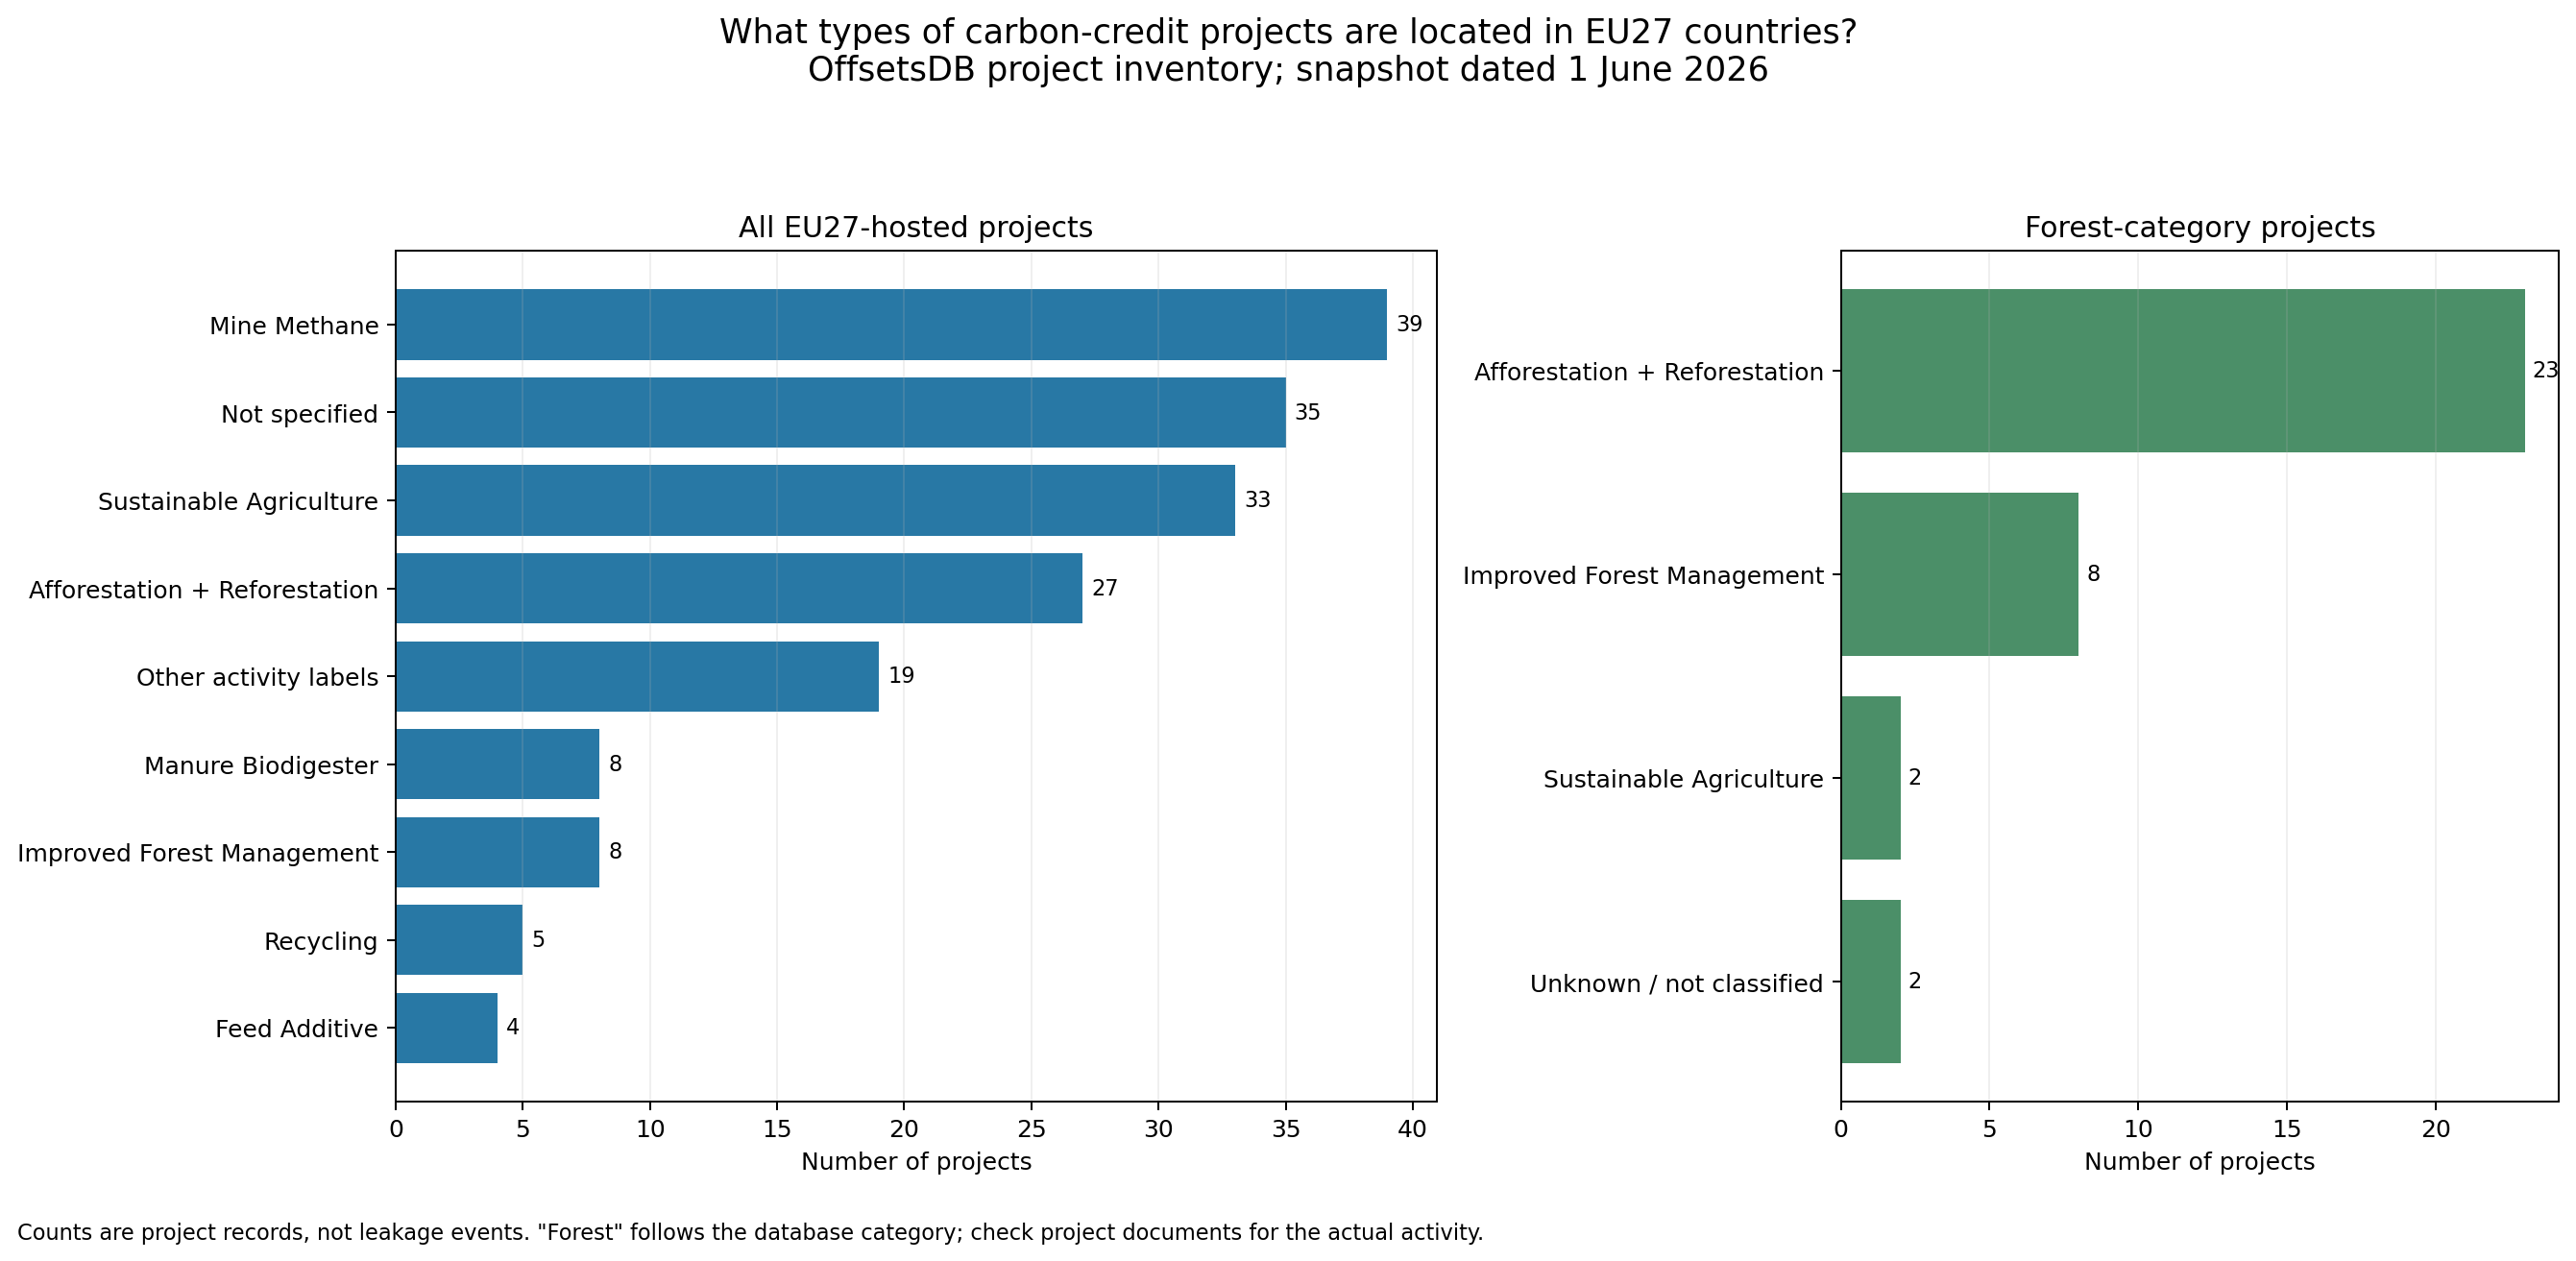

In [52]:
# Readable inventory chart: project records by reported type, with forest projects shown separately.
import matplotlib.pyplot as plt

counts = offset_type_summary.loc[~offset_type_summary["project_type_display"].eq("Unknown / not classified")].copy()
top_types = counts.head(7).copy()
other_count = int(counts.iloc[7:]["projects"].sum())
chart_counts = top_types[["project_type_display", "projects"]].copy()
if other_count:
    chart_counts.loc[len(chart_counts)] = ["Other activity labels", other_count]
chart_counts.loc[len(chart_counts)] = ["Not specified", int(offset_type_summary.loc[offset_type_summary["project_type_display"].eq("Unknown / not classified"), "projects"].iloc[0])]
chart_counts = chart_counts.sort_values("projects", ascending=True)
forest_counts = forest_type_summary.sort_values("projects", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1.45, 1]})
axes[0].barh(chart_counts["project_type_display"], chart_counts["projects"], color="#2878A5")
axes[0].set_title("All EU27-hosted projects")
axes[0].set_xlabel("Number of projects")
axes[0].grid(axis="x", alpha=.2)
for y, v in enumerate(chart_counts["projects"]): axes[0].text(v + .35, y, str(int(v)), va="center", fontsize=9)
axes[1].barh(forest_counts["project_type_display"], forest_counts["projects"], color="#4B8F68")
axes[1].set_title("Forest-category projects")
axes[1].set_xlabel("Number of projects")
axes[1].grid(axis="x", alpha=.2)
for y, v in enumerate(forest_counts["projects"]): axes[1].text(v + .25, y, str(int(v)), va="center", fontsize=9)
fig.suptitle("What types of carbon-credit projects are located in EU27 countries?\nOffsetsDB project inventory; snapshot dated 1 June 2026", fontsize=14, y=1.02)
fig.text(.01, .01, 'Counts are project records, not leakage events. "Forest" follows the database category; check project documents for the actual activity.', fontsize=9)
plt.tight_layout(rect=[0, .04, 1, .96])
fig.savefig(PRESENTATION_DIR / "11-offsetdb-eu27-project-types.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
# Annual registry transactions for credits generated by projects hosted in EU27 countries.
# A 2026 bar is partial because this OffsetsDB snapshot was generated on 1 June 2026.
annual_credit_flows["credits_issued_million"] = annual_credit_flows["credits_issued"] / 1_000_000
annual_credit_flows["credits_retired_million"] = annual_credit_flows["credits_retired"] / 1_000_000

display(annual_credit_flows)
print(f"Cumulative issued in snapshot: {projects_eu27['issued'].sum():,.0f}")
print(f"Cumulative retired in snapshot: {projects_eu27['retired'].sum():,.0f}")


### Carbon credits issued and retired: what the counts mean

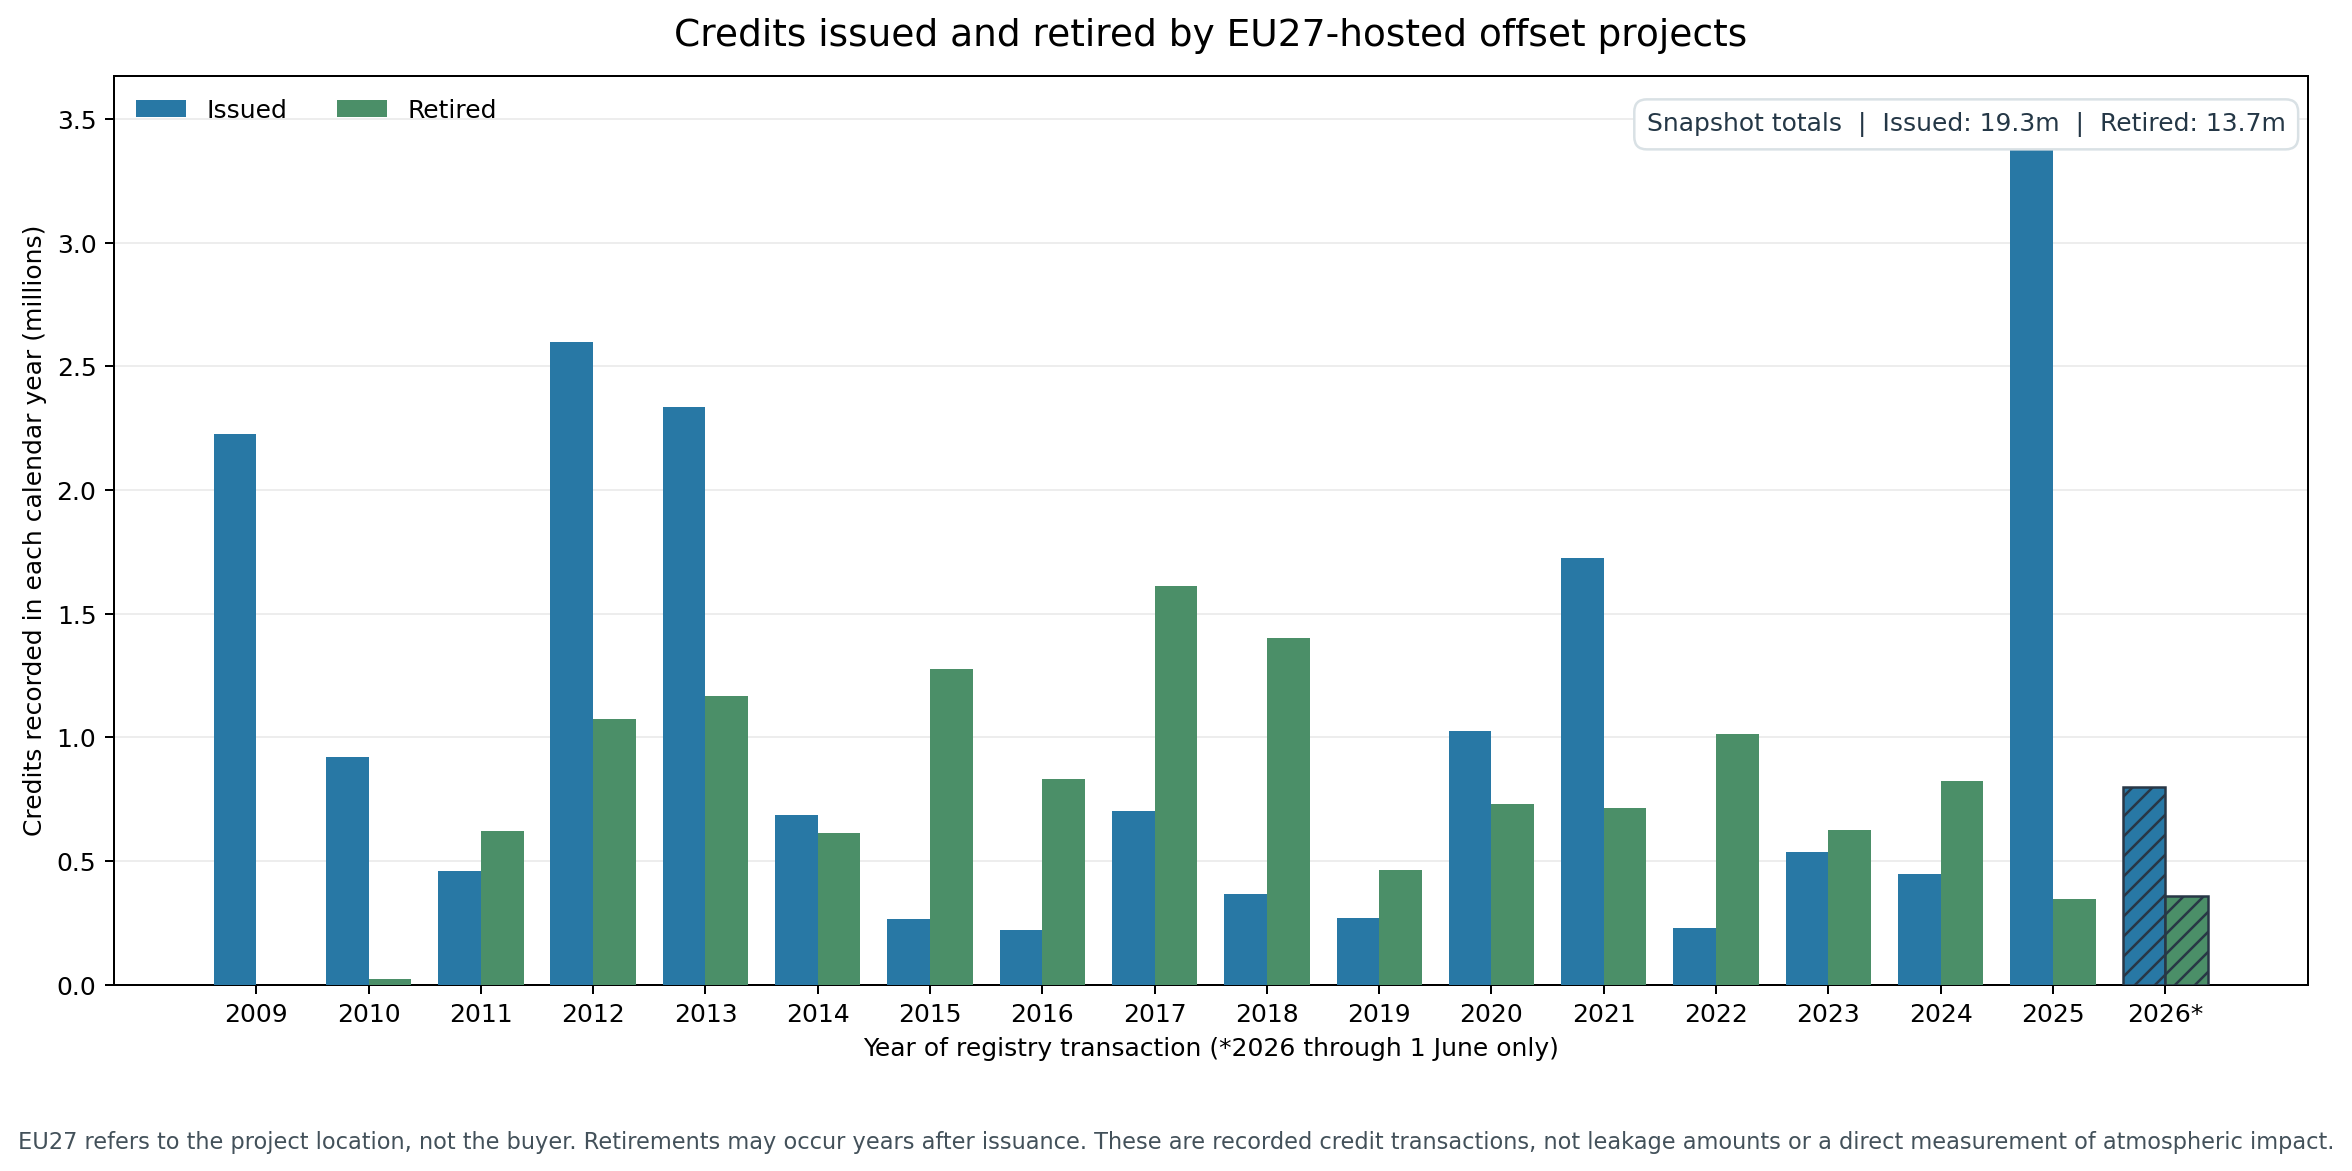

In simple terms, **issued** means a registry has recorded credits for reductions or removals reported by a project after the applicable checks. The credits can then be held or traded. **Retired** means credits have been taken out of circulation for a claim or use, so the same units cannot be used again. Under Verra’s VCS, one VCU represents one tonne of CO₂-equivalent; this chart combines multiple registries, so it reports their recorded credit quantities rather than independently measured tonnes of leakage.

This chart groups transactions by the year they were recorded. A retirement in one year may use credits issued in an earlier year, so the two bars are not meant to match year by year. The 2026 bars are partial, through 1 June 2026. “EU27” identifies where the projects are located, not where the buyers are.

For EU27-hosted projects, the snapshot records **19.31 million credits issued** and **13.70 million retired** cumulatively as of 1 June 2026. These figures show registry activity; they do not show how much leakage occurred, whether a credit fully counterbalanced an emission, or whether the project’s reported climate benefit caused a real-world change.

[Download annual transaction totals](eu27_hosted_credit_transactions_by_year.csv)


### What this first pass shows

- The EU27 subset contains **178 projects** across 10 database categories and 21 member states. The most frequent broad project types are mine methane capture/destruction (39 records), sustainable agriculture (33), and afforestation/reforestation (27).
- The **35 forest-category projects** include 23 afforestation/reforestation records and 8 improved-forest-management records. The remaining labels are sustainable agriculture or unspecified. No EU27-hosted project is tagged REDD+ in this snapshot.
- The 1 June 2026 snapshot records **19.31 million credits issued** and **13.70 million retired** by EU27-hosted projects. Section 8 compares annual transaction volumes and explains the difference between issuance and retirement. These are registry credit records, **not** leakage totals.
- The highest-priority follow-up is to inspect project documents for the EU27 forest and agriculture projects, extract reported leakage estimates/deductions and monitoring periods, then compare their definitions and units. A consistent value can only be assembled where source documentation supports it.

**Interpretation:** this cross-check tells us which offset activities are present and where project documents may contain leakage accounting. It does not establish that leakage happened, and it does not directly validate the separate EU industrial-import risk signals.


### Sources and interpretation notes

- CarbonPlan, [OffsetsDB data processing and project classifications](https://offsets-db-data.readthedocs.io/en/stable/data-processing.html). The documentation explains that categories are broad approaches and project types are more specific labels assigned from protocols, with manual overrides.
- CarbonPlan, [OffsetsDB data access](https://offsets-db-data.readthedocs.io/en/stable/data-access.html), and [current update notice](https://offsets-db-data.readthedocs.io/en/latest/).
- Verra, [FAQ: leakage](https://verra.org/faq/), which describes activity shifting and market leakage in land-based projects.
- Verra, [AFOLU Project Market Leakage module](https://verra.org/methodologies/afolu-project-market-leakage/), which describes assessing production of agricultural, livestock, and forest commodities that may shift elsewhere.

- Verra, [Verified Carbon Units](https://verra.org/programs/verified-carbon-standard/verified-carbon-units-vcus/), for the VCS unit definition and registry meaning of issuance and retirement.


## 9. Three levels of leakage evidence: current findings together

These labels keep descriptive patterns, project accounting, and causal conclusions distinct. They can complement one another, but they are not interchangeable measures and must not be added into one score.

| Evidence level | What the label means | Current finding | Assessment |
|---|---|---|---|
| **1. Risk signal** | A pattern is consistent with emissions or production shifting beyond the EU, without proving why it happened. | In the 2008-2022 endpoint comparison, C20 (chemicals) and C23 (other non-metallic mineral products) show falling domestic emissions and constant-euro sold-production value, alongside rising broad-proxy extra-EU import values and OECD-modeled import carbon. | **Four-direction endpoint pattern in C20 and C23; provisional because trade mapping is broad and trends are not smooth in every indicator.** |
| **2. Project-reported leakage** | A project design, monitoring, or verification document estimates or deducts emissions it attributes to activity shifting or market effects under its own method. | Three project reports were source-checked in the first pass: AgreenaCarbon gives an ex-ante estimate; Silvador gives a verified-period total; Westphalen gives no activity shifting for one period but applies a market leakage factor. Two more projects (Rotunda and Carpathia) have secondary-source leads, but their primary report claims are not yet verified in this review. | **Source-checked evidence in 3 of 70 prioritized records; two secondary leads remain pending primary-document review. Methods and periods differ, so totals are not comparable.** |
| **3. Causally established leakage** | Evidence links a change in one location to an increase elsewhere and supports the conclusion that the first change caused the displacement. | The industrial panel is aggregate and descriptive. Project reports apply project accounting methods. Neither links a measured output change to a measured emissions increase elsewhere against a credible comparison. | **Not established by current data.** |

### Combined reading

C20 and C23 remain **broad-sector descriptive risk-screen candidates** based on the 2008-2022 endpoint directions. We then expanded the product-level comparison using official PRODCOM-CN links. Of 1,317 product codes in the supplied five-division extract, 666 meet the strict matching rules and have complete sold-quantity series. Among those, 141 have falling EU sold output and rising extra-EU imports between 2008 and 2022; 33 also show both expected monotonic trends after adjusting for multiple tests. These are production-and-trade risk signals: there is no product-level emissions or imported-carbon series in the matched data, and the analysis does not identify why the measures changed. C19 is represented by only one PRODCOM code in the supplied extract. The product-level findings do not prove that EU climate policy caused relocation.

Project-report findings are separate. In one example the report gives a long-horizon estimate, in another it gives a verified-period total, and in the third it reports a 20% market leakage factor alongside no activity shifting in that period. Two secondary-source leads flag questions to check in Rotunda and Carpathia documents, but those leads are not counted as source-checked leakage findings. A project host country does not by itself identify where credits were purchased or where displaced activity occurred.

**Presentation wording:** "Two industrial sectors show all four expected start-to-end directions in a preliminary screen. Three source-checked project reports show how project-level leakage can be estimated or deducted. Two additional cases raise document-review questions. Neither body of evidence establishes that EU production changes caused emissions to rise elsewhere."


## 10. The story we will tell, in four steps

The presentation will follow four questions, in order. It shows what the data say, what they do not yet establish, and what must happen before a 2030 outlook is credible.

| Step | Audience question | Current position | Next piece of work |
|---|---|---|---|
| **1. Where do we see a possible signal?** | Are EU production and emissions falling while extra-EU imports and imported carbon rise? | **Expanded screen:** Of 666 strictly matched products across C17, C19, C20, C23 and C24, 141 show falling output and rising extra-EU imports at the endpoints; 33 show both expected monotonic trends after multiple-test adjustment. Product-level emissions are not matched. | Check historical classification continuity, seek product-level emissions intensity and examine the 141 candidates; keep production/trade signals separate from project-accounted leakage and causal claims. |
| **2. What do offset projects report?** | Do project documents estimate or deduct activity-shifting or market leakage? | **Credit lifecycle and source-checked reports:** annual issuance and retirement are charted for EU27-hosted projects; AgreenaCarbon, Silvador, and Westphalen have source-checked examples. Rotunda and Carpathia are secondary-source leads only. | Continue through the 70-record review queue and capture report type, unit, method, period, boundary, and verification; obtain primary documents for the two leads. |
| **3. Can we attribute the change to displacement?** | Do we know that a change here caused production or emissions to rise somewhere else? | **Not established:** no linked displaced activity and emissions series or credible counterfactual are available. | Build a comparison with aligned sectors, destinations, time periods, and demand/energy controls where the data permit. |
| **4. What might happen by 2030?** | How could the risk develop under plausible conditions? | **Illustrative 2030 paths added:** three historical growth windows are projected for the four core indicators in C20 and C23, plus the net embodied-emissions trade balance in C19, C20 and C23. The OECD series ends in 2022, so all paths are conditional on historical trends. | Update the imported-carbon series and harmonized production/trade panel beyond 2022, then refresh the paths and show their sensitivity; keep project-accounted leakage separate. |

### First project-document review queue

The priority queue contains **70 project records**: 27 afforestation/reforestation, 8 improved forest management, 33 sustainable agriculture, and 2 wetland projects. Three reports have source-checked leakage findings. Of the **67 records still marked Not reviewed** in the primary-document queue, two have secondary-source leads awaiting direct report review; the other 65 have not yet had even this secondary-source screen. No missing report or amount is treated as zero.

The queue records project IDs, report availability, leakage estimates or factors, methods, monitoring periods, verification status, and source links. The two secondary leads are tracked separately so they are not mistaken for source-checked project-report findings.

[Open the EU27 offset-project review queue](offsetdb_eu27_project_review_queue.csv)

[Open the reviewed project-leakage examples table](offset_project_leakage_report_examples.csv)

[Open the secondary-source leads for follow-up](offsetdb_secondary_source_leads.csv)


## 11. First-pass industrial risk screen

### What changed

We combined annual EU27 sold-production value, domestic industry emissions, extra-EU import values, and modeled carbon embodied in extra-EU imports for 2008-2022. The comparison is presented as an index (2008 = 100) so the audience can read direction without comparing unlike units.

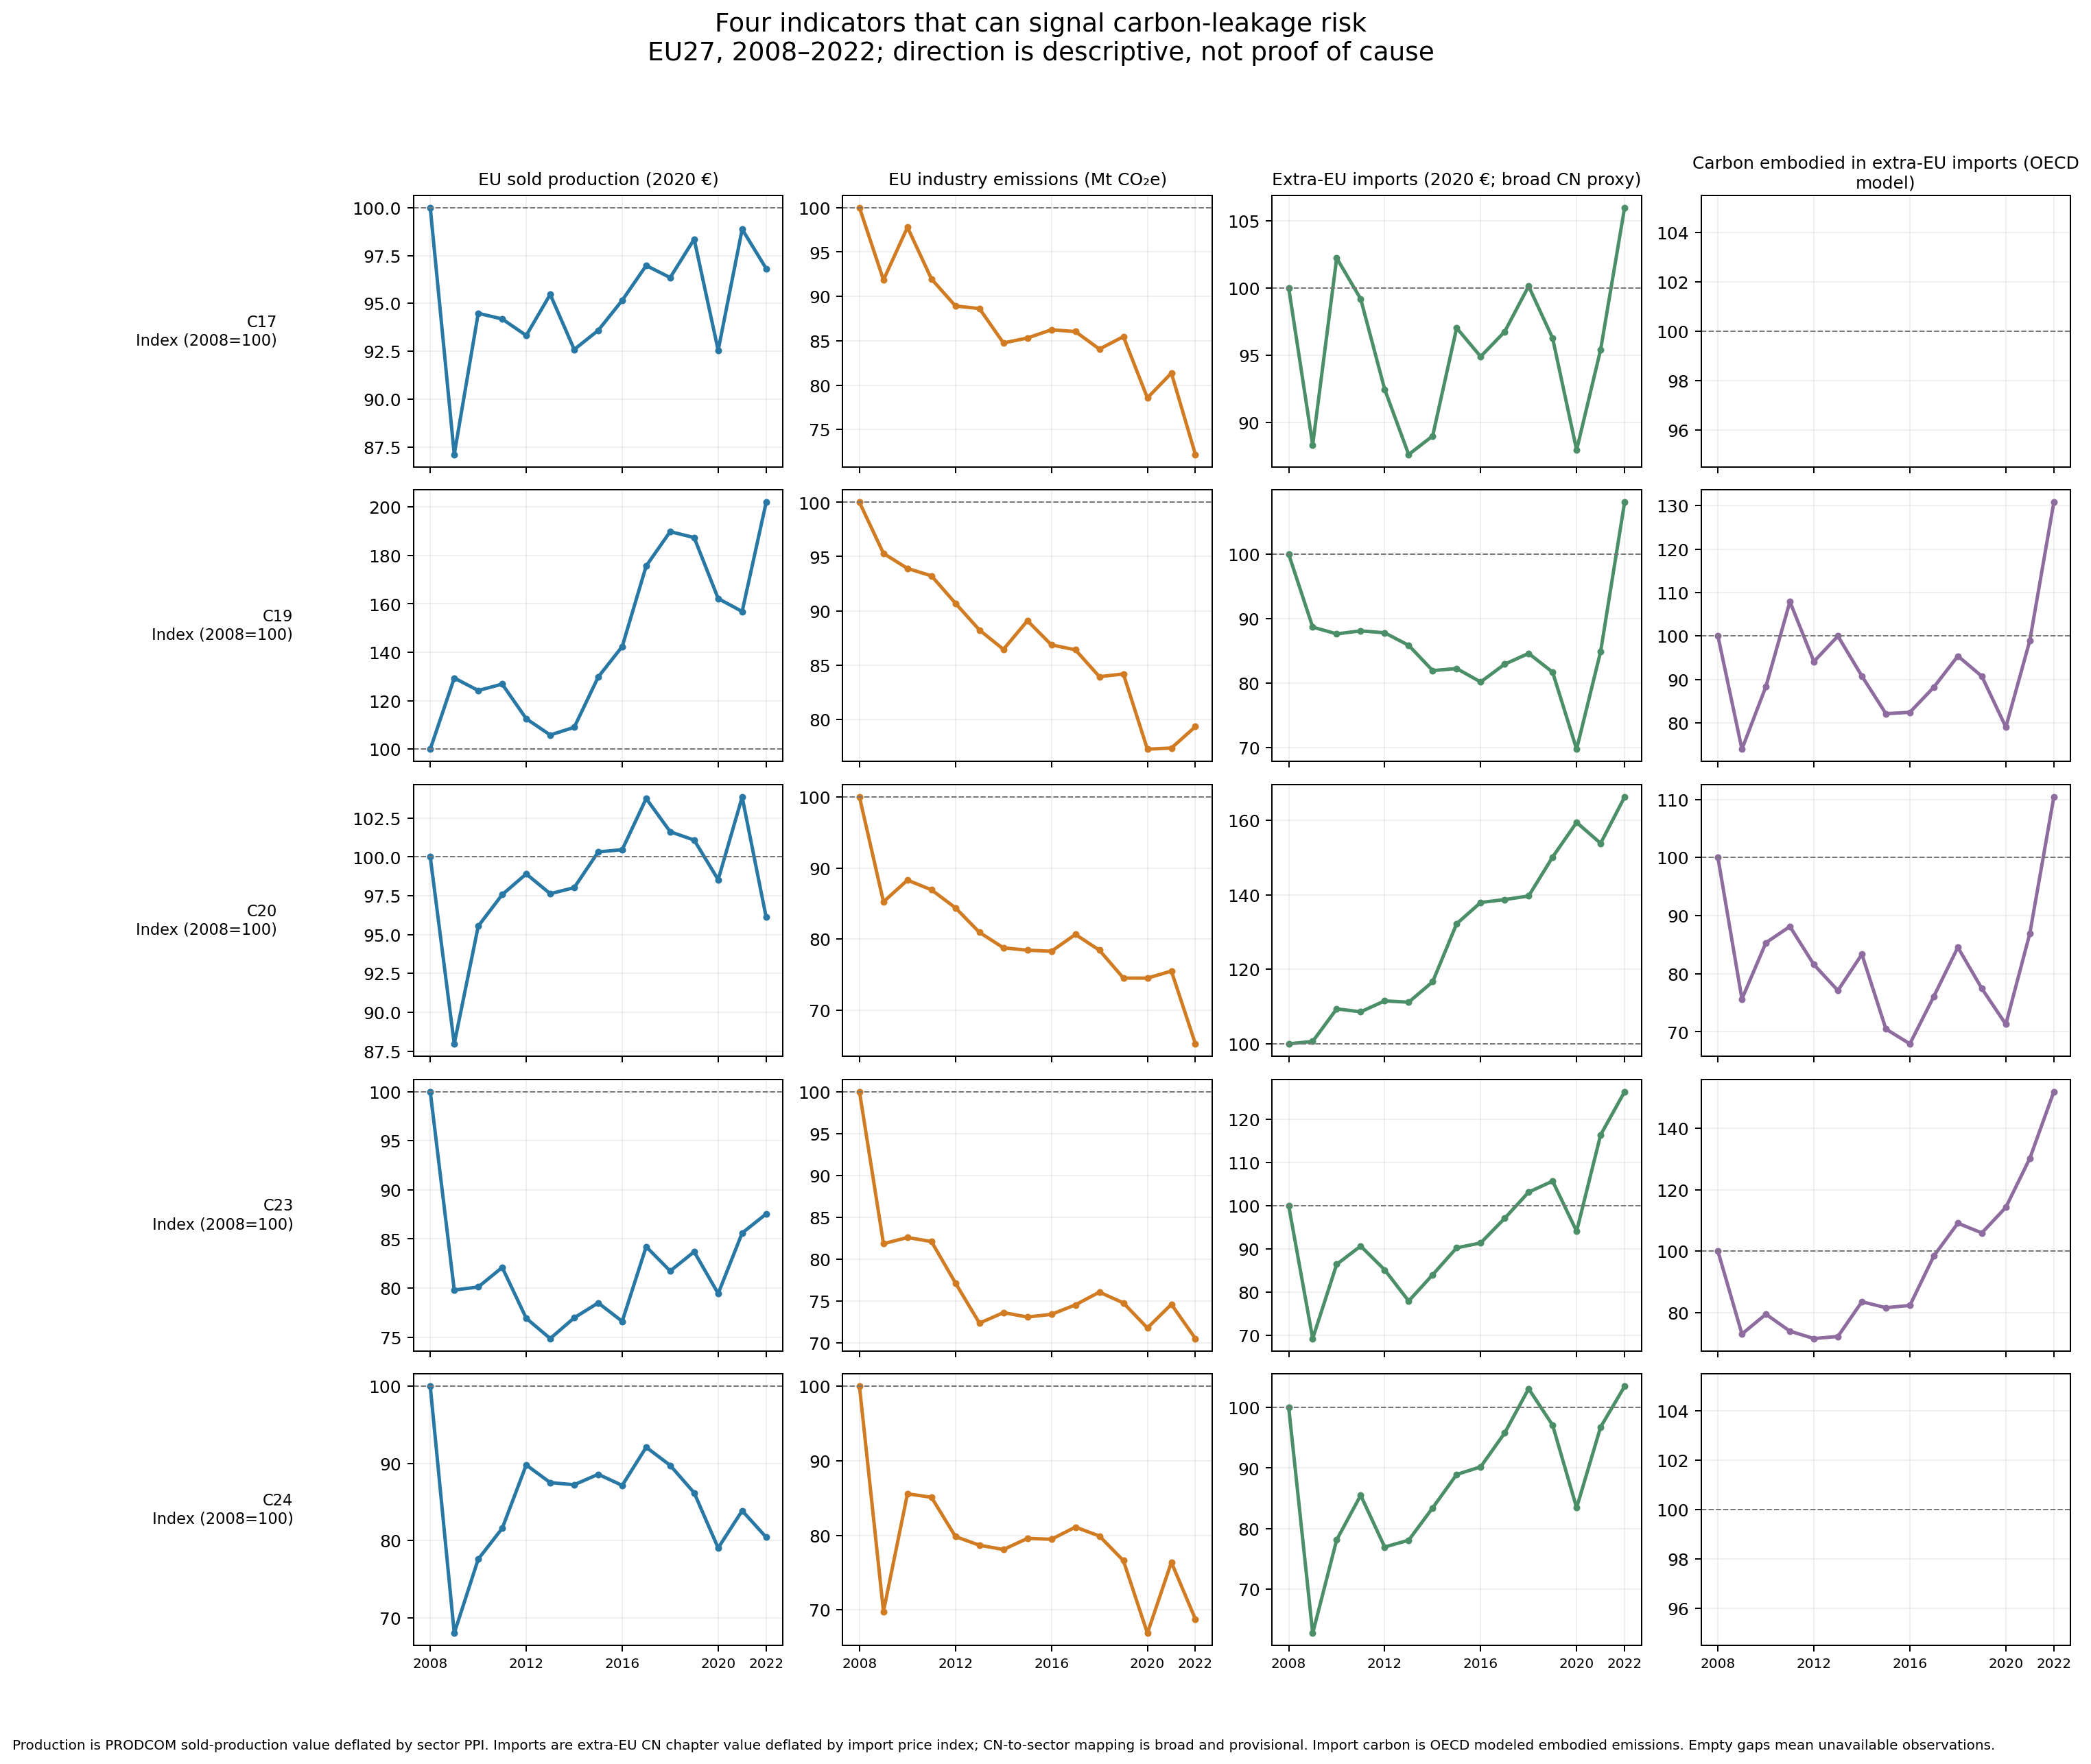

### What the first pass shows

| Industry division | Sold production value, 2008-2022 | Domestic emissions | Extra-EU imports | Carbon embodied in imports | Reading |
|---|---:|---:|---:|---:|---|
| C20 - Chemicals | -3.9% | -34.8% | +66.2% | +10.4% | All four start-to-end directions; imported-carbon trend is not statistically clear. |
| C23 - Other non-metallic mineral products | -12.5% | -29.5% | +26.4% | +51.9% | All four start-to-end directions; three indicators show a clear monotonic trend, while production does not. |

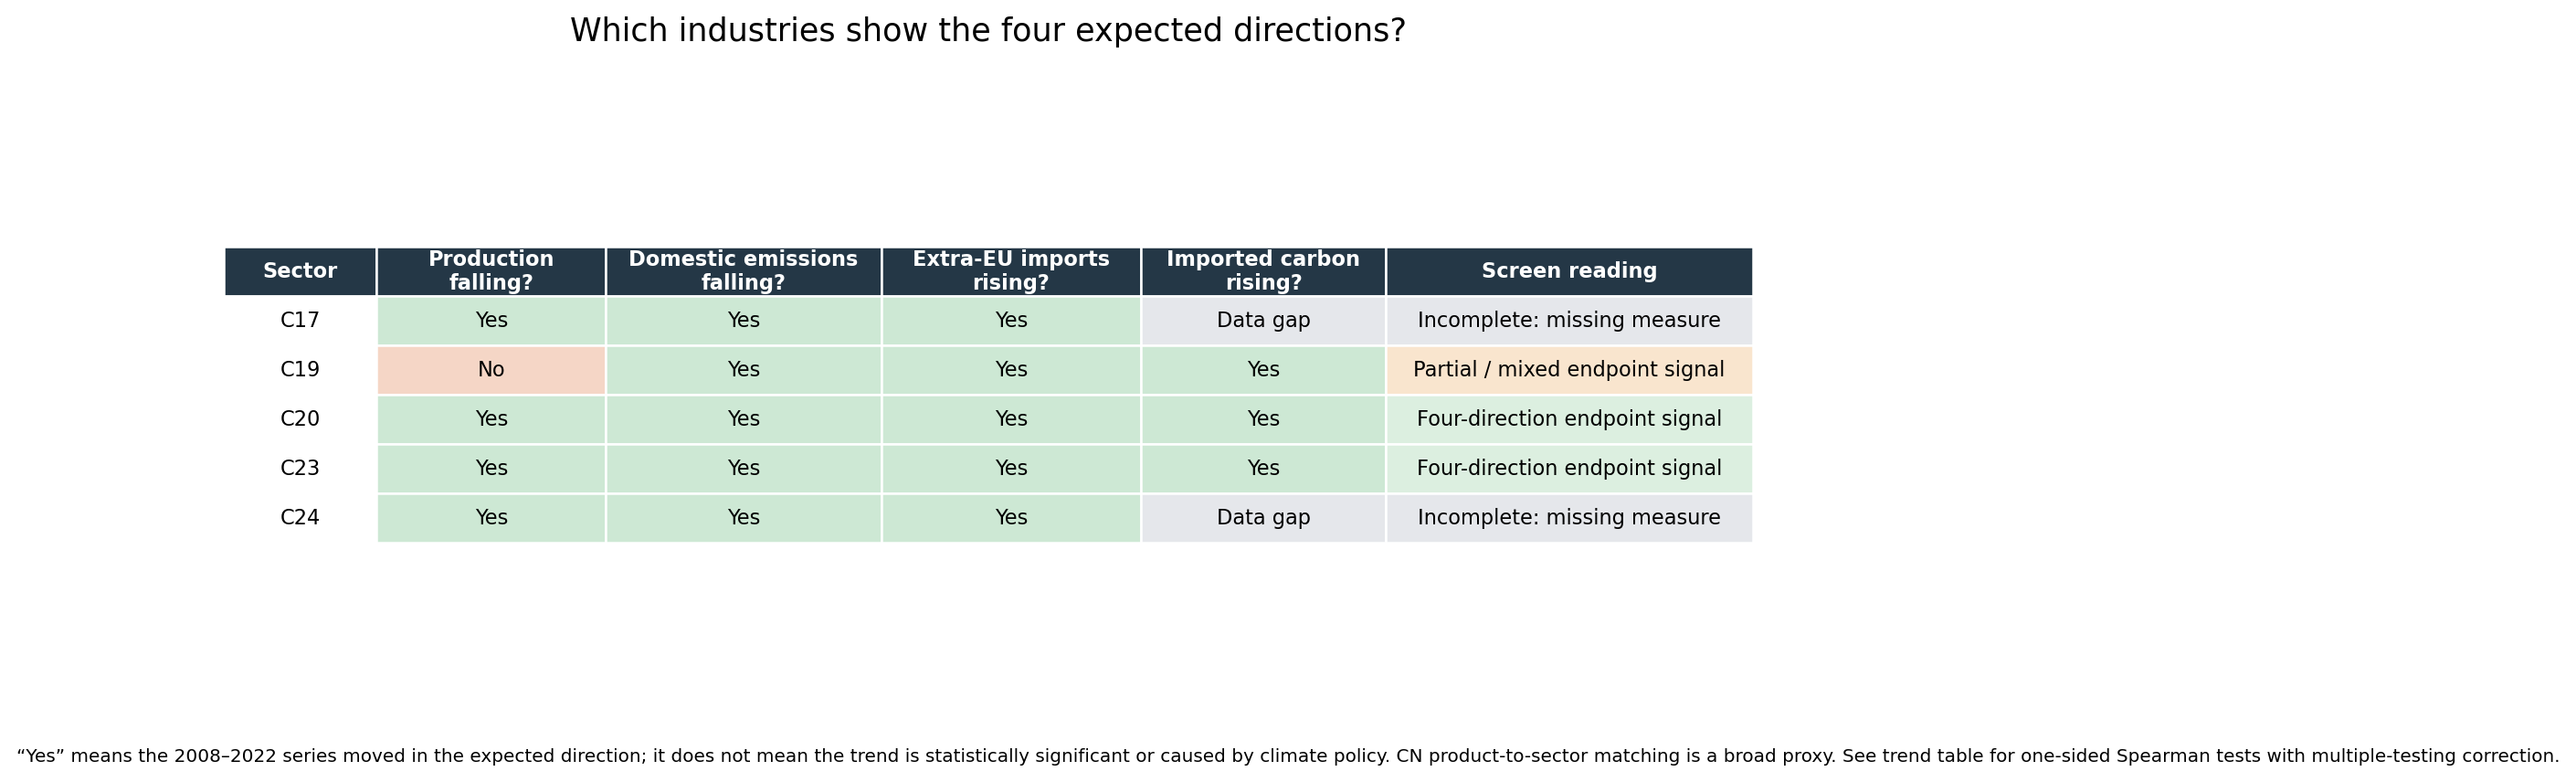

These are **constant-euro value changes**, not tonnes of physical production. The Comext imports are extra-EU CN chapters grouped into broad industry proxies, and the OECD embodied-carbon figures are model estimates. C19 production is represented by only one PRODCOM code in the extract, so it should not be read as full-sector production. OECD carbon data are unavailable for C17 and C24.

The one-sided Spearman checks ask whether each annual series follows the expected direction consistently over time. P-values were adjusted across the 18 available sector-indicator tests; `q < 0.05` indicates a clear monotonic trend for this exploratory screen. The checks do not prove cause, and they do not adjust for year-to-year autocorrelation.

| Indicator trend test | C20 result | C23 result |
|---|---|---|
| Production value trending down | No clear downward trend (q=1.000); endpoint fell 3.9% | No clear downward trend (q=1.000); endpoint fell 12.5% |
| Domestic emissions trending down | Clear downward trend (q<0.001) | Clear downward trend (q=0.005) |
| Extra-EU import value trending up | Clear upward trend (q<0.001) | Clear upward trend (q=0.005) |
| Imported carbon trending up | No clear upward trend (q=0.783) | Clear upward trend (q=0.001) |

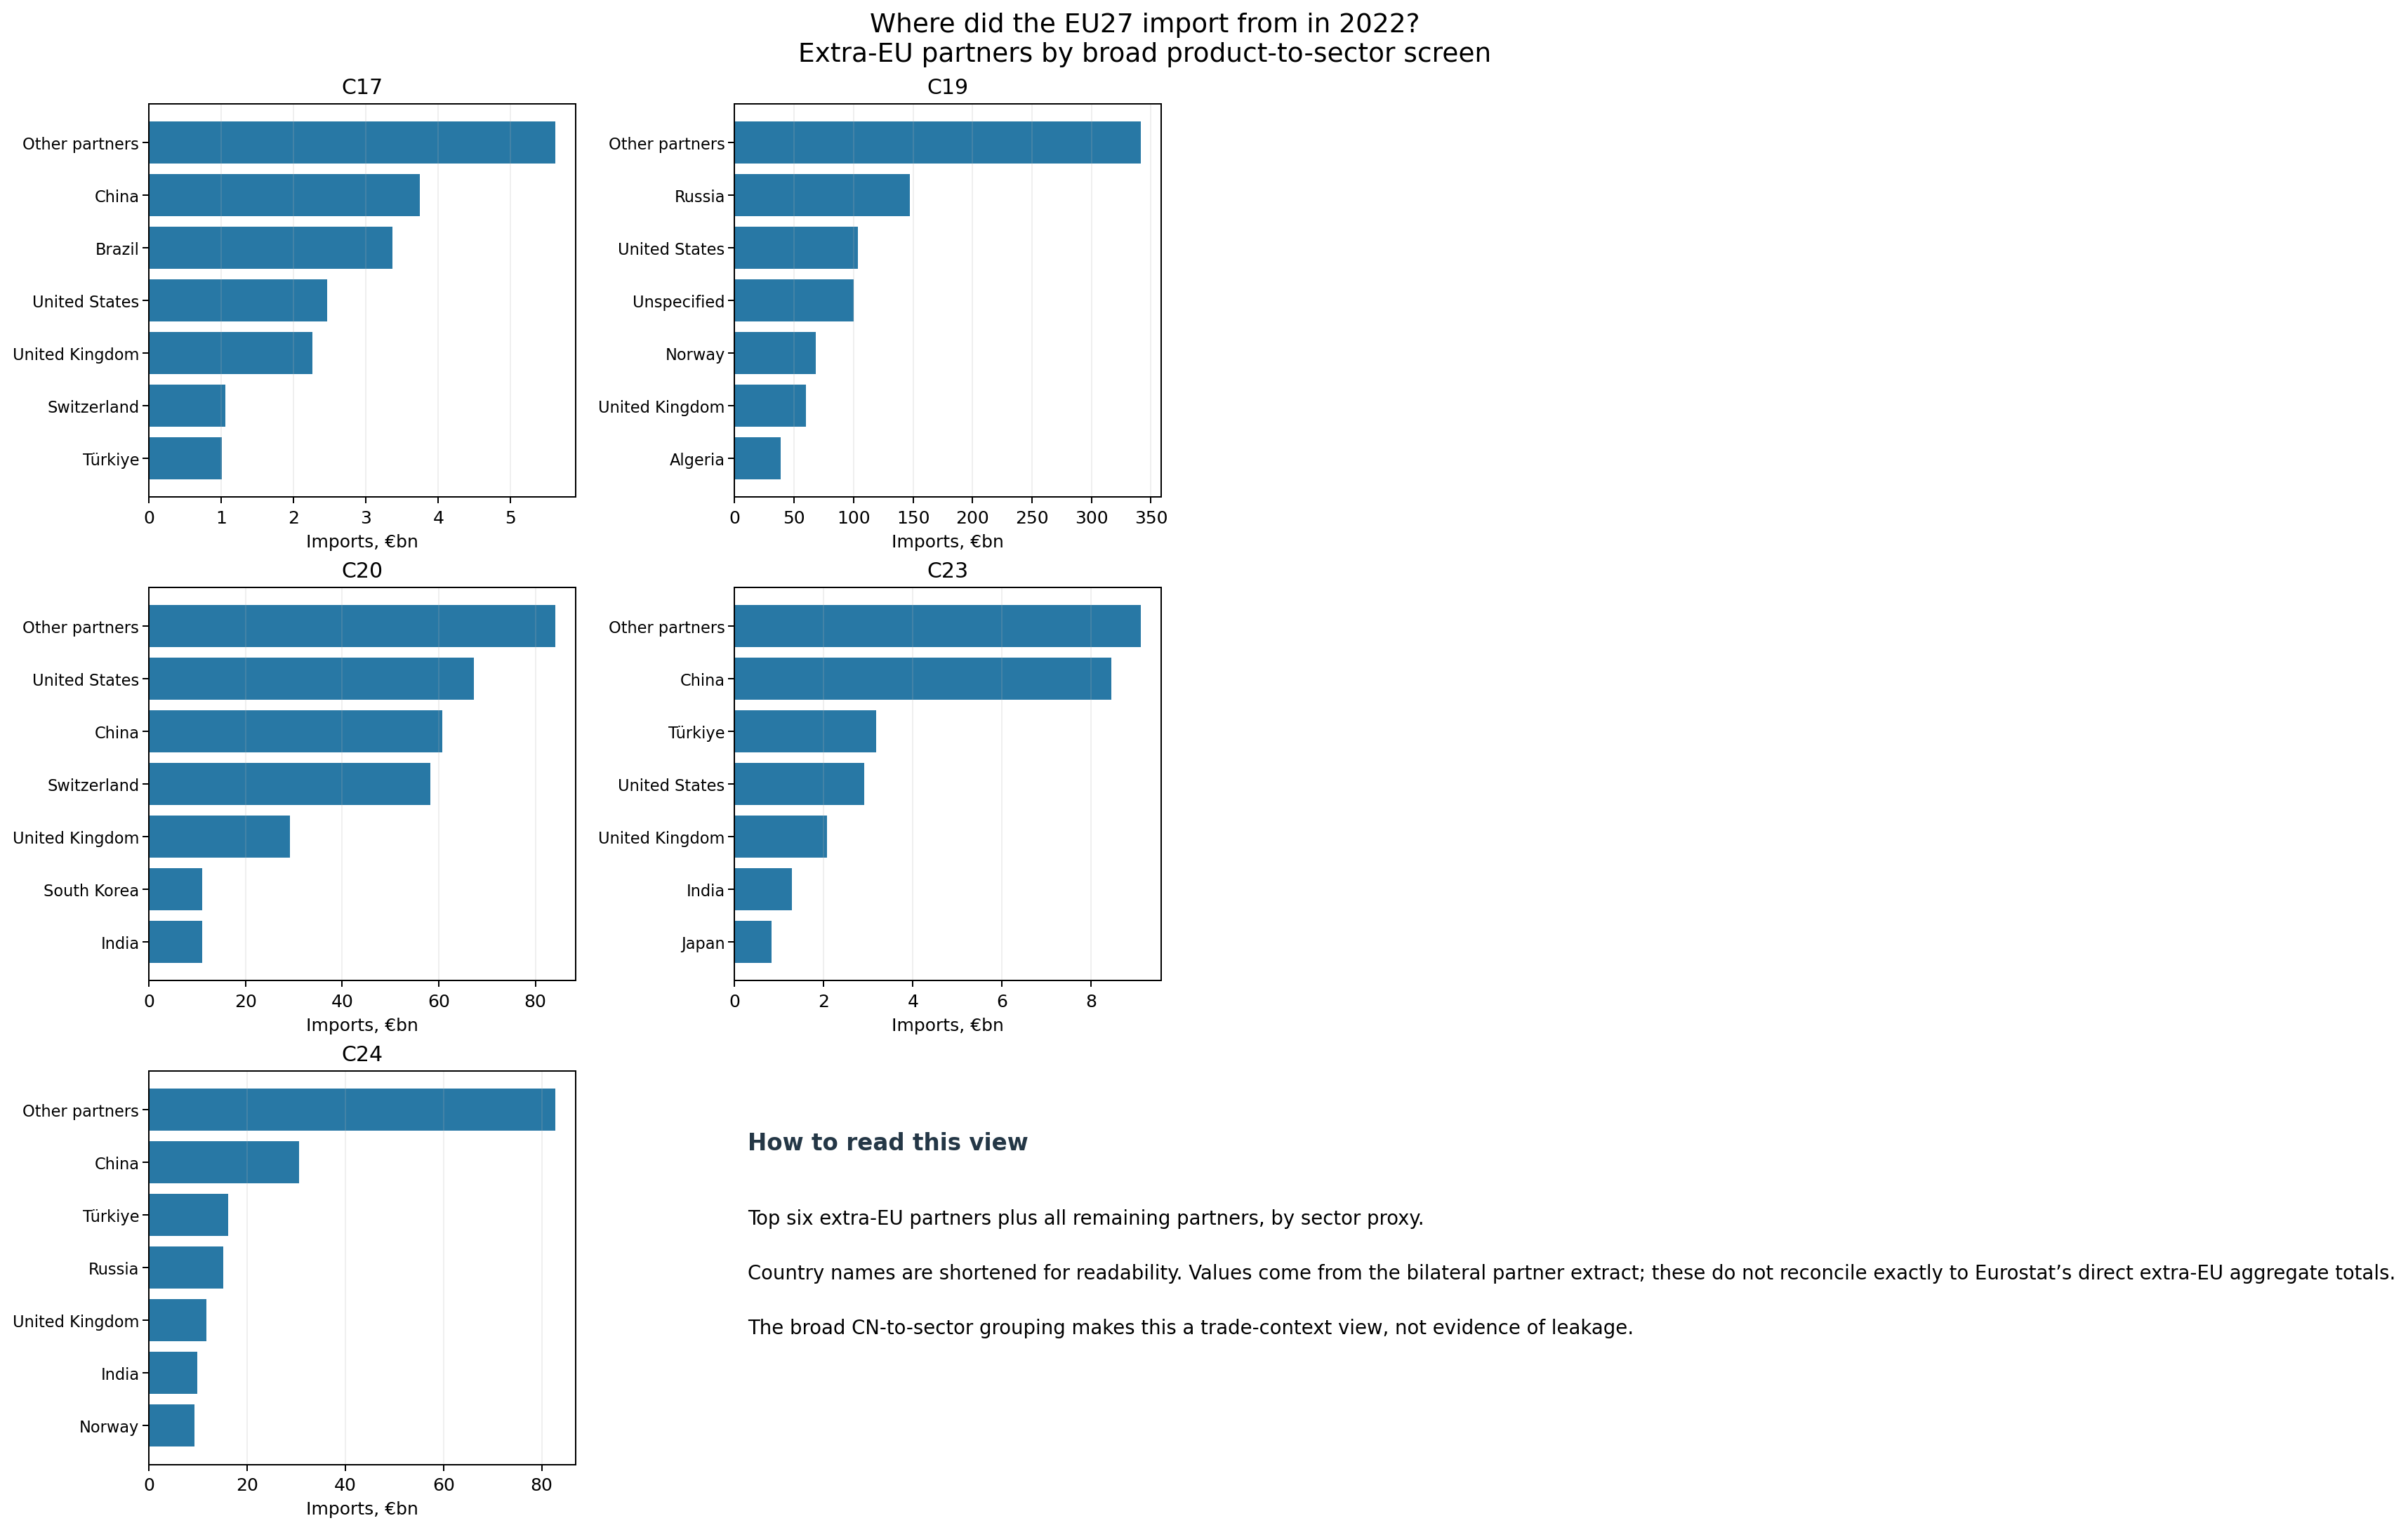

Headline import totals come from Eurostat’s direct extra-EU aggregate. Bilateral partner rows are used for the partner chart and do not sum exactly to the aggregate (typically about 1–2%, with larger gaps in some sector-years); the reconciliation is saved in [this table](comext_partner_vs_aggregate_reconciliation.csv). The partner view provides trade context, not a leakage verdict. A product-level check for four goods with official PRODCOM-to-CN matches and physical quantities follows below. It improves alignment but is only a small sample; the product-level imported-carbon series is not available in the supplied data.

Sources: [Eurostat PRODCOM](https://ec.europa.eu/eurostat/en/web/prodcom/information-data), [Eurostat Comext](https://ec.europa.eu/eurostat/web/user-guides/data-browser/api-data-access/api-getting-started/comext-database), [Eurostat Air Emissions Accounts](https://ec.europa.eu/eurostat/databrowser/view/env_ac_ainah_r2/default/table?lang=en), [OECD GHG Footprints](https://data-explorer.oecd.org/vis?df%5Bag%5D=OECD.STI.PIE&df%5Bds%5D=dsDisseminateFinalDMZ&df%5Bid%5D=DSD_ICIO_GHG_TRADE_2025%40DF_ICIO_GHG_TRADE_2025&df%5Bvs%5D=1.0).


In [ ]:
# Reopen the saved first-pass tables used in the figures above.
industry_screen = pd.read_csv(OUTPUT_DIR / 'eu27_industry_leakage_screen_summary.csv')
industry_trend_tests = pd.read_csv(OUTPUT_DIR / 'eu27_industry_leakage_screen_trends.csv')
display(industry_screen)
display(industry_trend_tests)
trade_reconciliation = pd.read_csv(OUTPUT_DIR / 'comext_partner_vs_aggregate_reconciliation.csv')
display(trade_reconciliation.head())


### Pilot: four illustrative product matches

We first tested whether the broad-sector pattern appears for four identifiable goods. The expanded screen below now covers many more products. To make that initial check, we matched four PRODCOM sold-production series to CN8 extra-EU import series: polypropylene and ethylene (chemicals, C20), plus cement clinker and ready-mixed concrete (non-metallic minerals, C23). The official PRODCOM 2022 list confirms the product references and physical units. Each series has observations for 2008–2022. These four products are examples with usable quantity matches, not a complete inventory of either industry.

#### Chart 1 — EU sold output and extra-EU imports

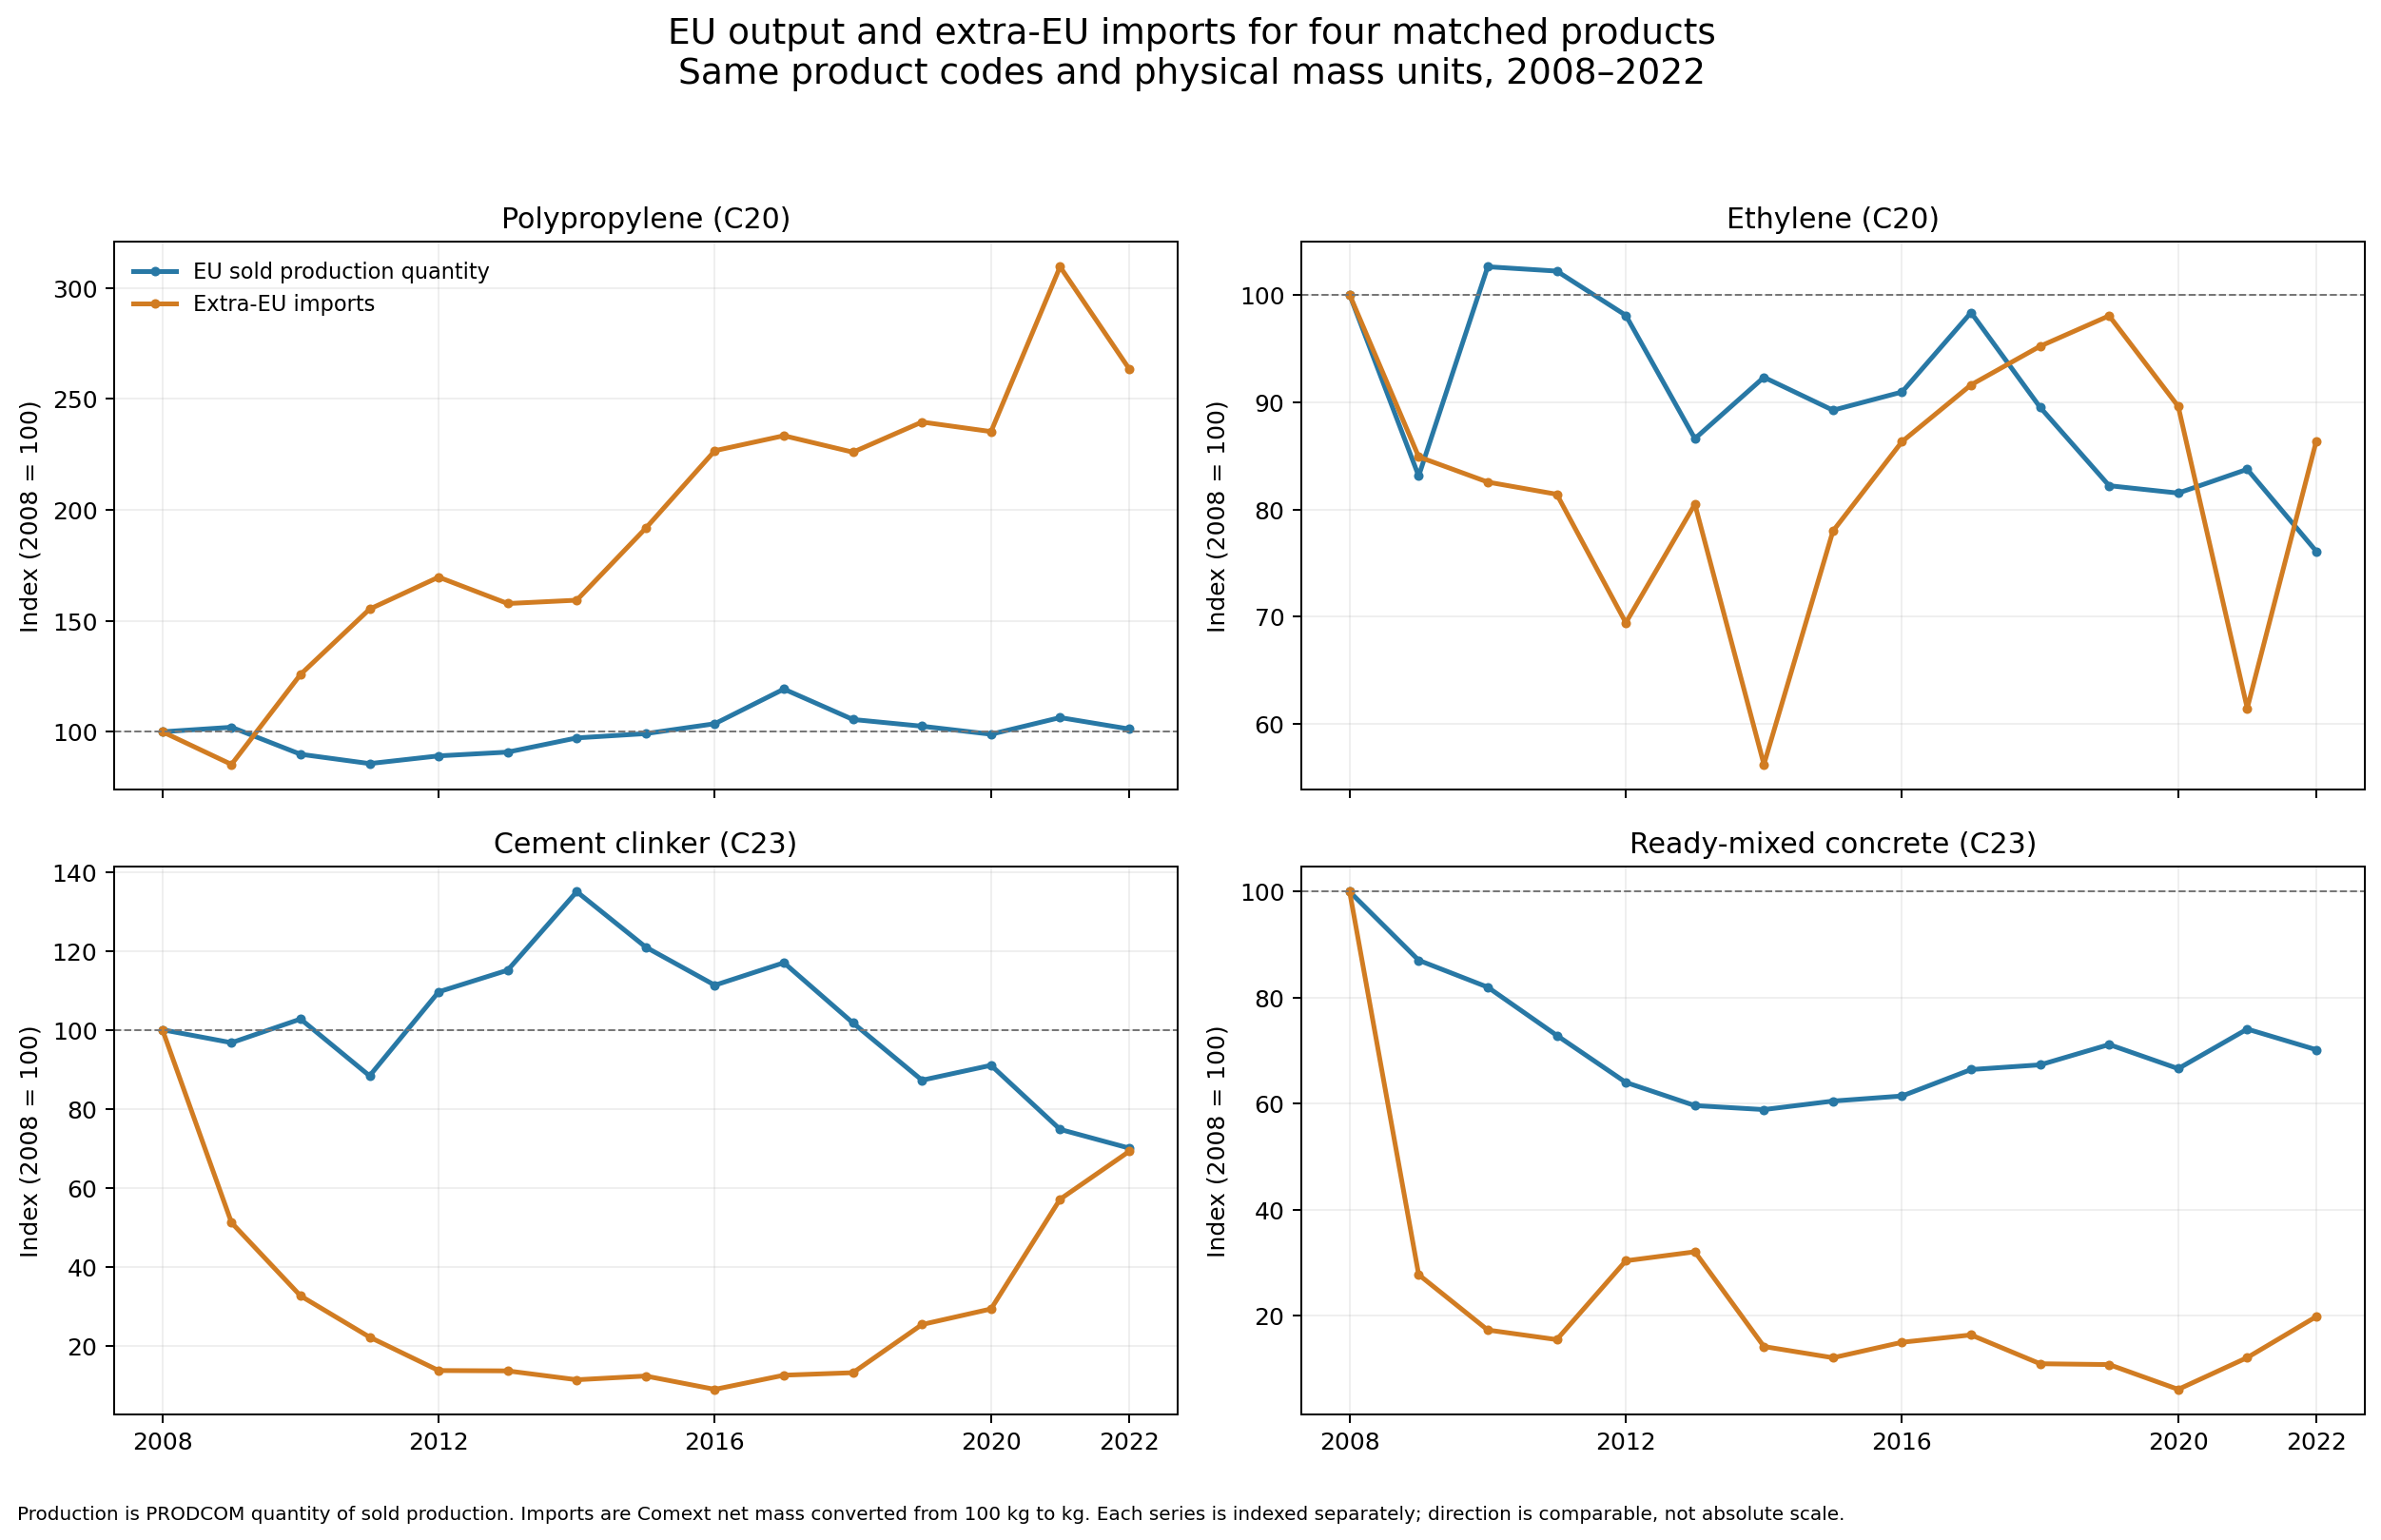

**How to read it:** Each coloured line starts at 100 in 2008. A value of 150 means that measure is 50% above its own 2008 level; 80 means 20% below. Output and imports are indexed separately, so their directions and timing can be compared, but the vertical distance between the two lines does not compare their physical quantities. Blue is PRODCOM sold-production quantity; orange is extra-EU imports, with Comext's 100 kg measure converted to kilograms.

**What is happening:** Polypropylene imports rise strongly while EU sold output stays close to its starting level. Ethylene output trends down, but imports do not rise consistently. Cement clinker and ready-mixed concrete both show declines in EU output and extra-EU imports over the period. In these four examples, no product has the paired pattern of falling EU output and rising extra-EU imports.

#### Chart 2 — Extra-EU imports as a share of output plus imports

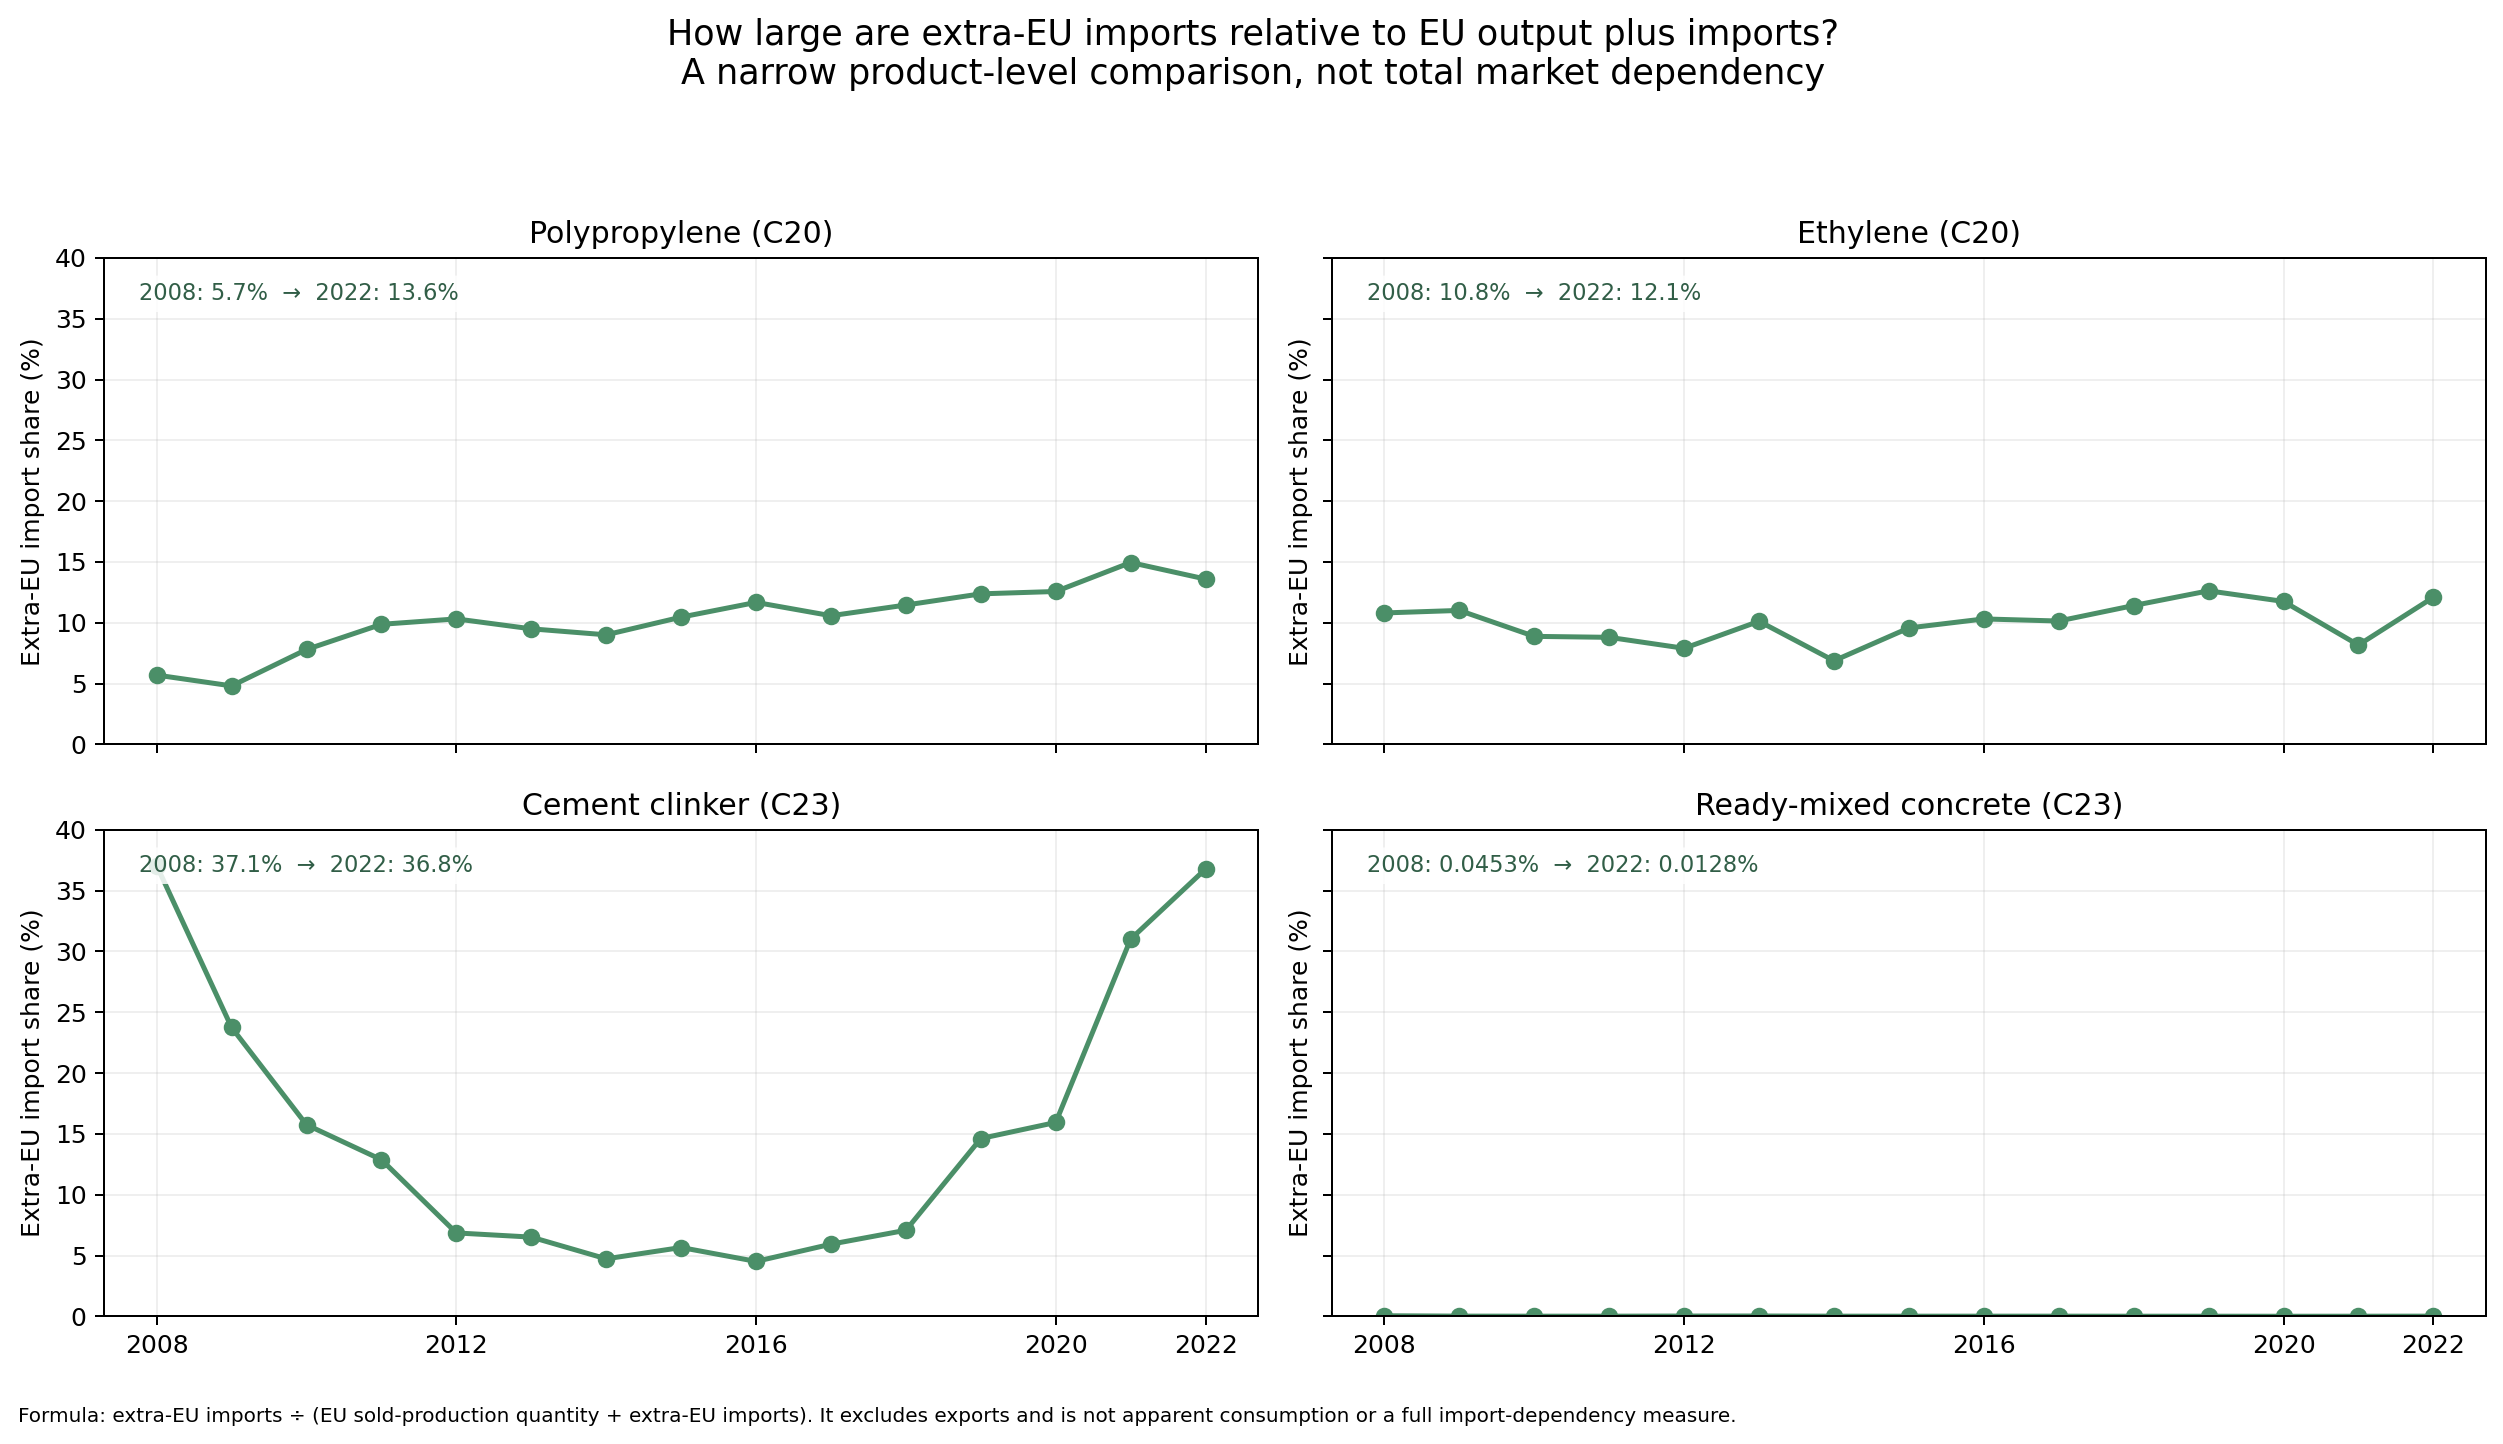

**How to read it:** The vertical axis uses one shared 0–40% scale in every panel, so the product levels are directly comparable. The line is calculated as `extra-EU imports ÷ (EU sold-production quantity + extra-EU imports)`. Endpoint labels make the very small ready-mixed-concrete values visible.

**What is happening:** Cement clinker has the largest extra-EU share among these four products, while polypropylene's share increases over time. The ready-mixed-concrete share is close to zero on this common scale (0.045% in 2008 and 0.013% in 2022). This is only a narrow proxy: it excludes exports and intra-EU trade, and sold production is not the same as total domestic supply. It must not be described as the full EU market's import dependency or apparent consumption.

#### Chart 3 — Simple endpoint screen

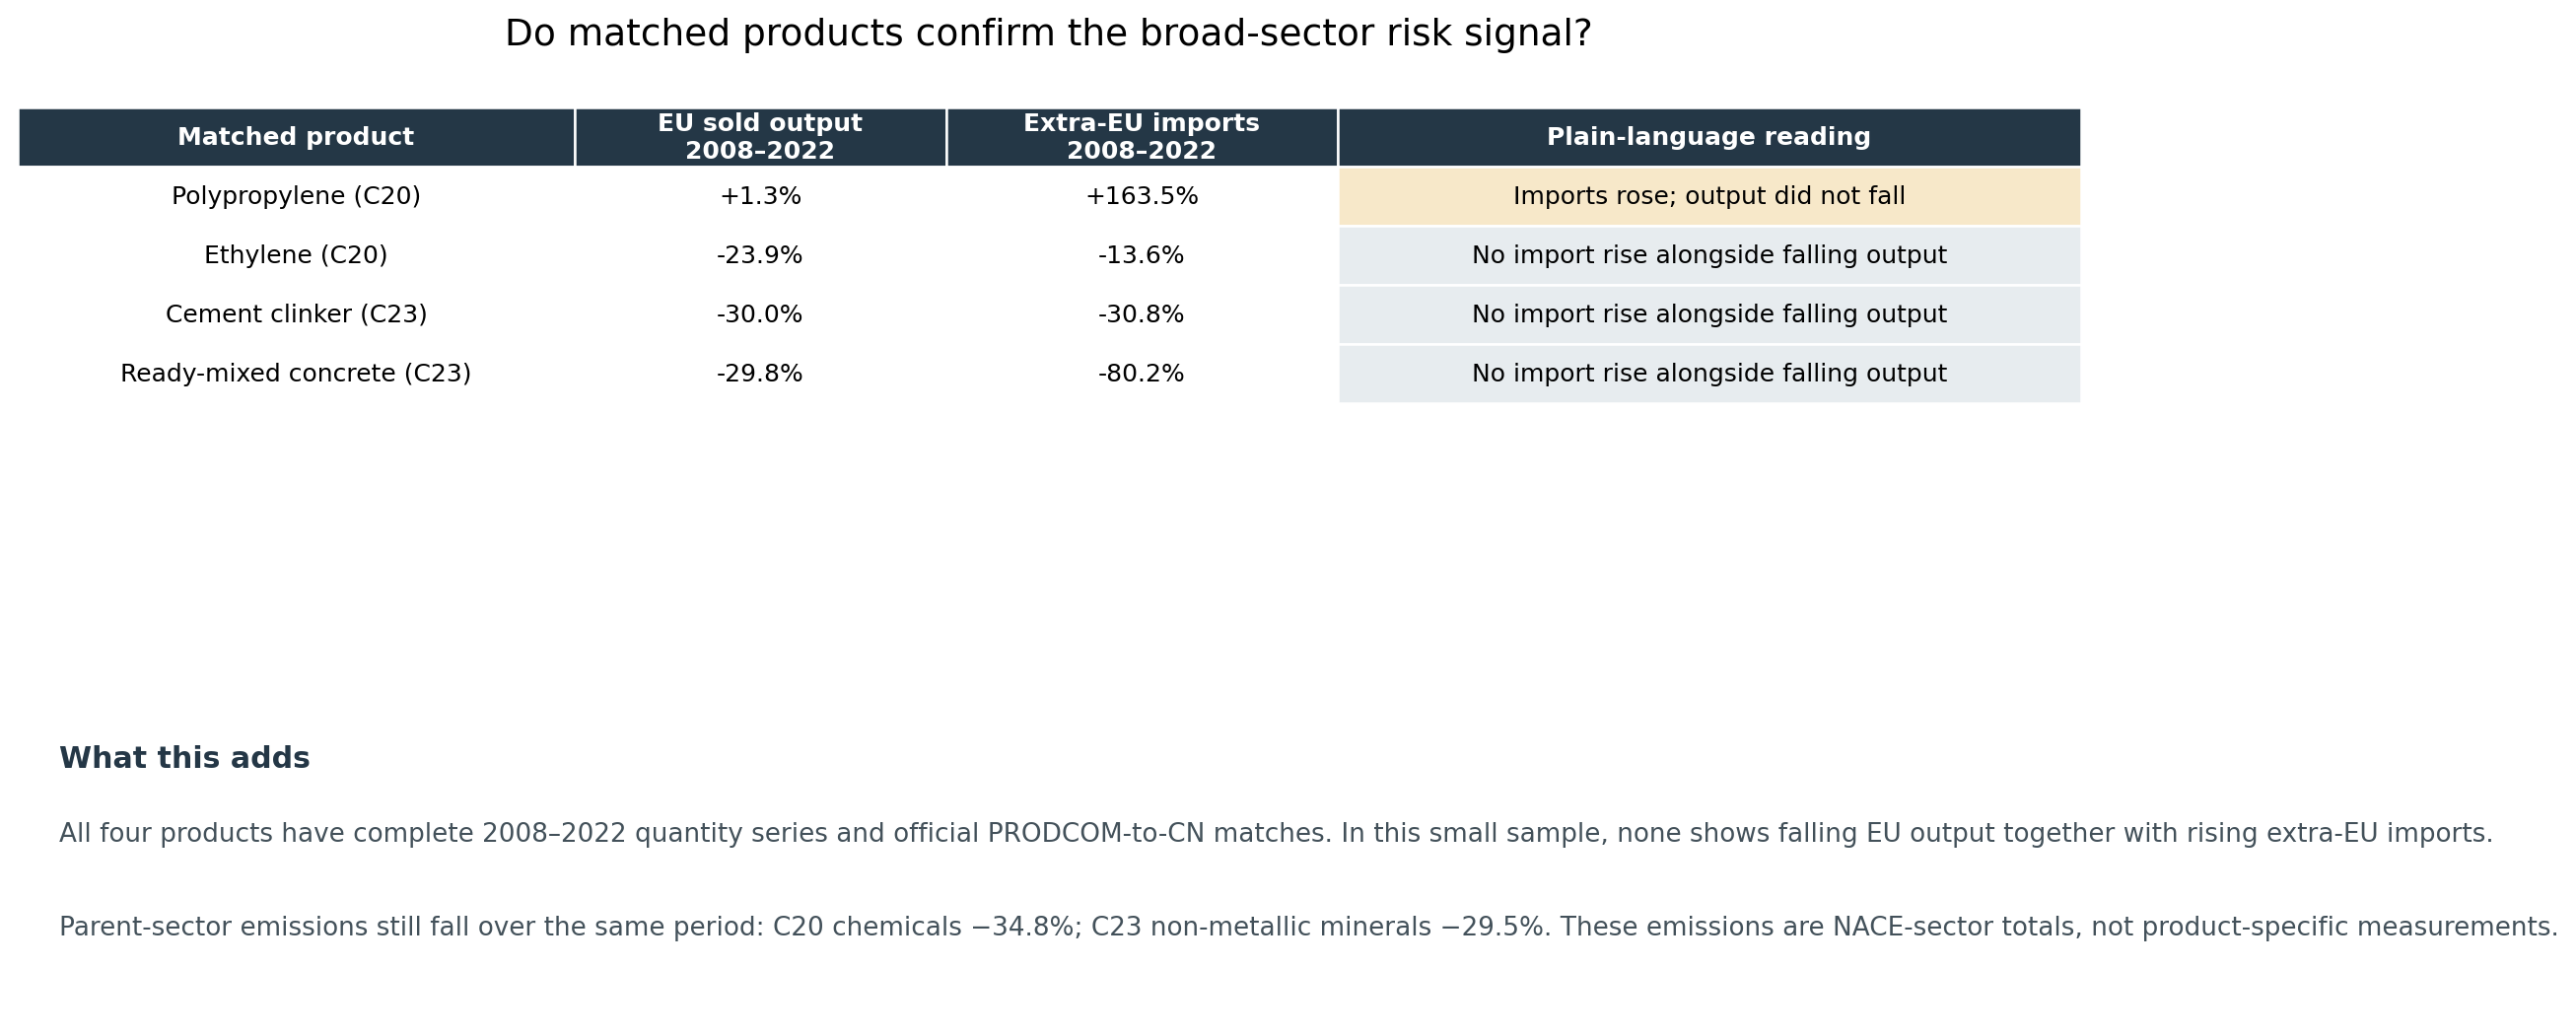

**How to read it:** The table compares 2008 with 2022, so it summarizes endpoints rather than every year. The green category would identify both expected directions (output down and imports up); the highlighted polypropylene row means imports rose but output did not fall; grey rows mean imports did not rise alongside falling output.

**What is happening:** None of the four matched products meets the two-direction screen. Polypropylene is the clearest import-growth example, but its EU sold output is approximately flat (+1.3%). Ethylene, clinker, and ready-mixed concrete have declining endpoint imports as well as declining output. Sector emissions are shown only as context: C20 emissions fell 34.8% and C23 emissions fell 29.5%; these are whole-sector figures and cannot be assigned to the four products.

#### Trend tests and limits

The next table applies one-sided Spearman trend tests to each product's annual series (15 years each): downward for production and upward for imports. The Benjamini–Hochberg adjusted value (`q`) accounts for the eight product-indicator tests; `q < 0.05` marks a clear monotonic trend in the pre-specified direction. Only polypropylene imports show a clear upward trend, and only ethylene sold output shows a clear downward trend. No product has both. These exploratory tests do not establish cause and do not correct for serial correlation between adjacent years.

Eurostat defines PRODCOM production here as goods produced and sold/invoiced during the reference period. The match uses the official PRODCOM–CN references and common mass units; see [PRODCOM information](https://ec.europa.eu/eurostat/en/web/prodcom/information-data), the [PRODCOM 2022 list](https://op.europa.eu/en/web/eu-vocabularies/dataset/-/resource?uri=http://publications.europa.eu/resource/dataset/prodcom2022), and the [Comext API guide](https://ec.europa.eu/eurostat/web/user-guides/data-browser/api-data-access/api-getting-started/comext-database).



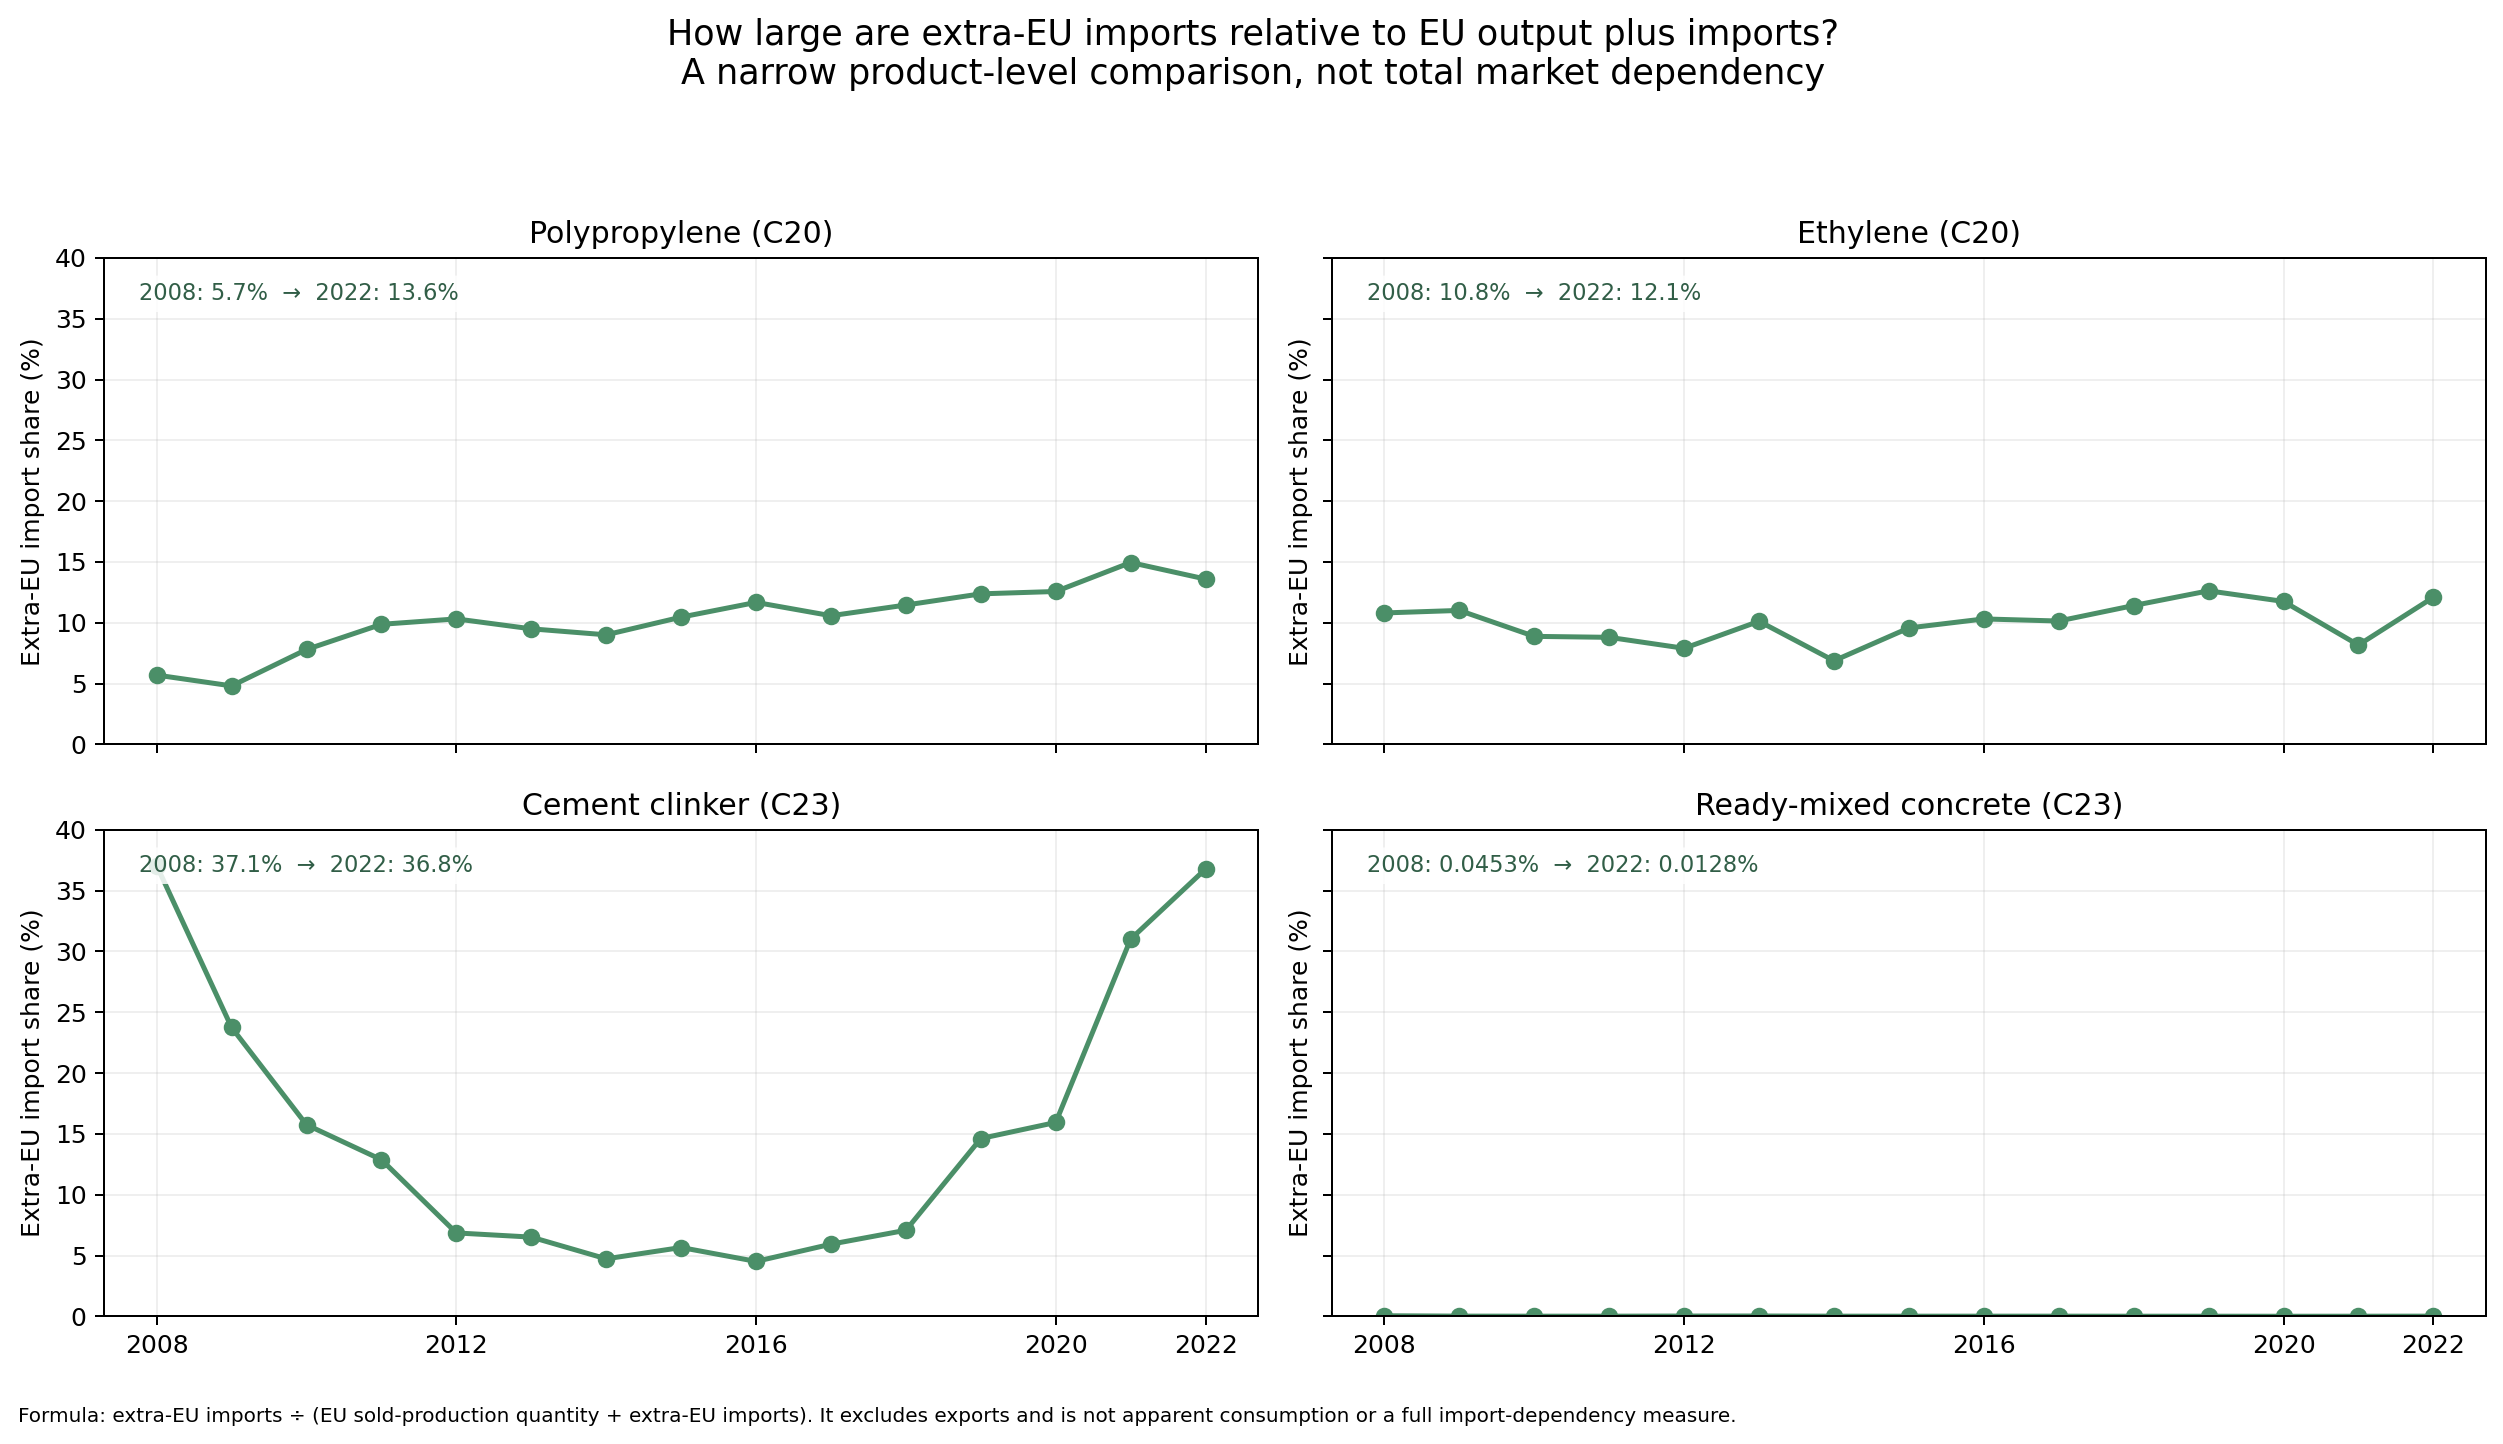


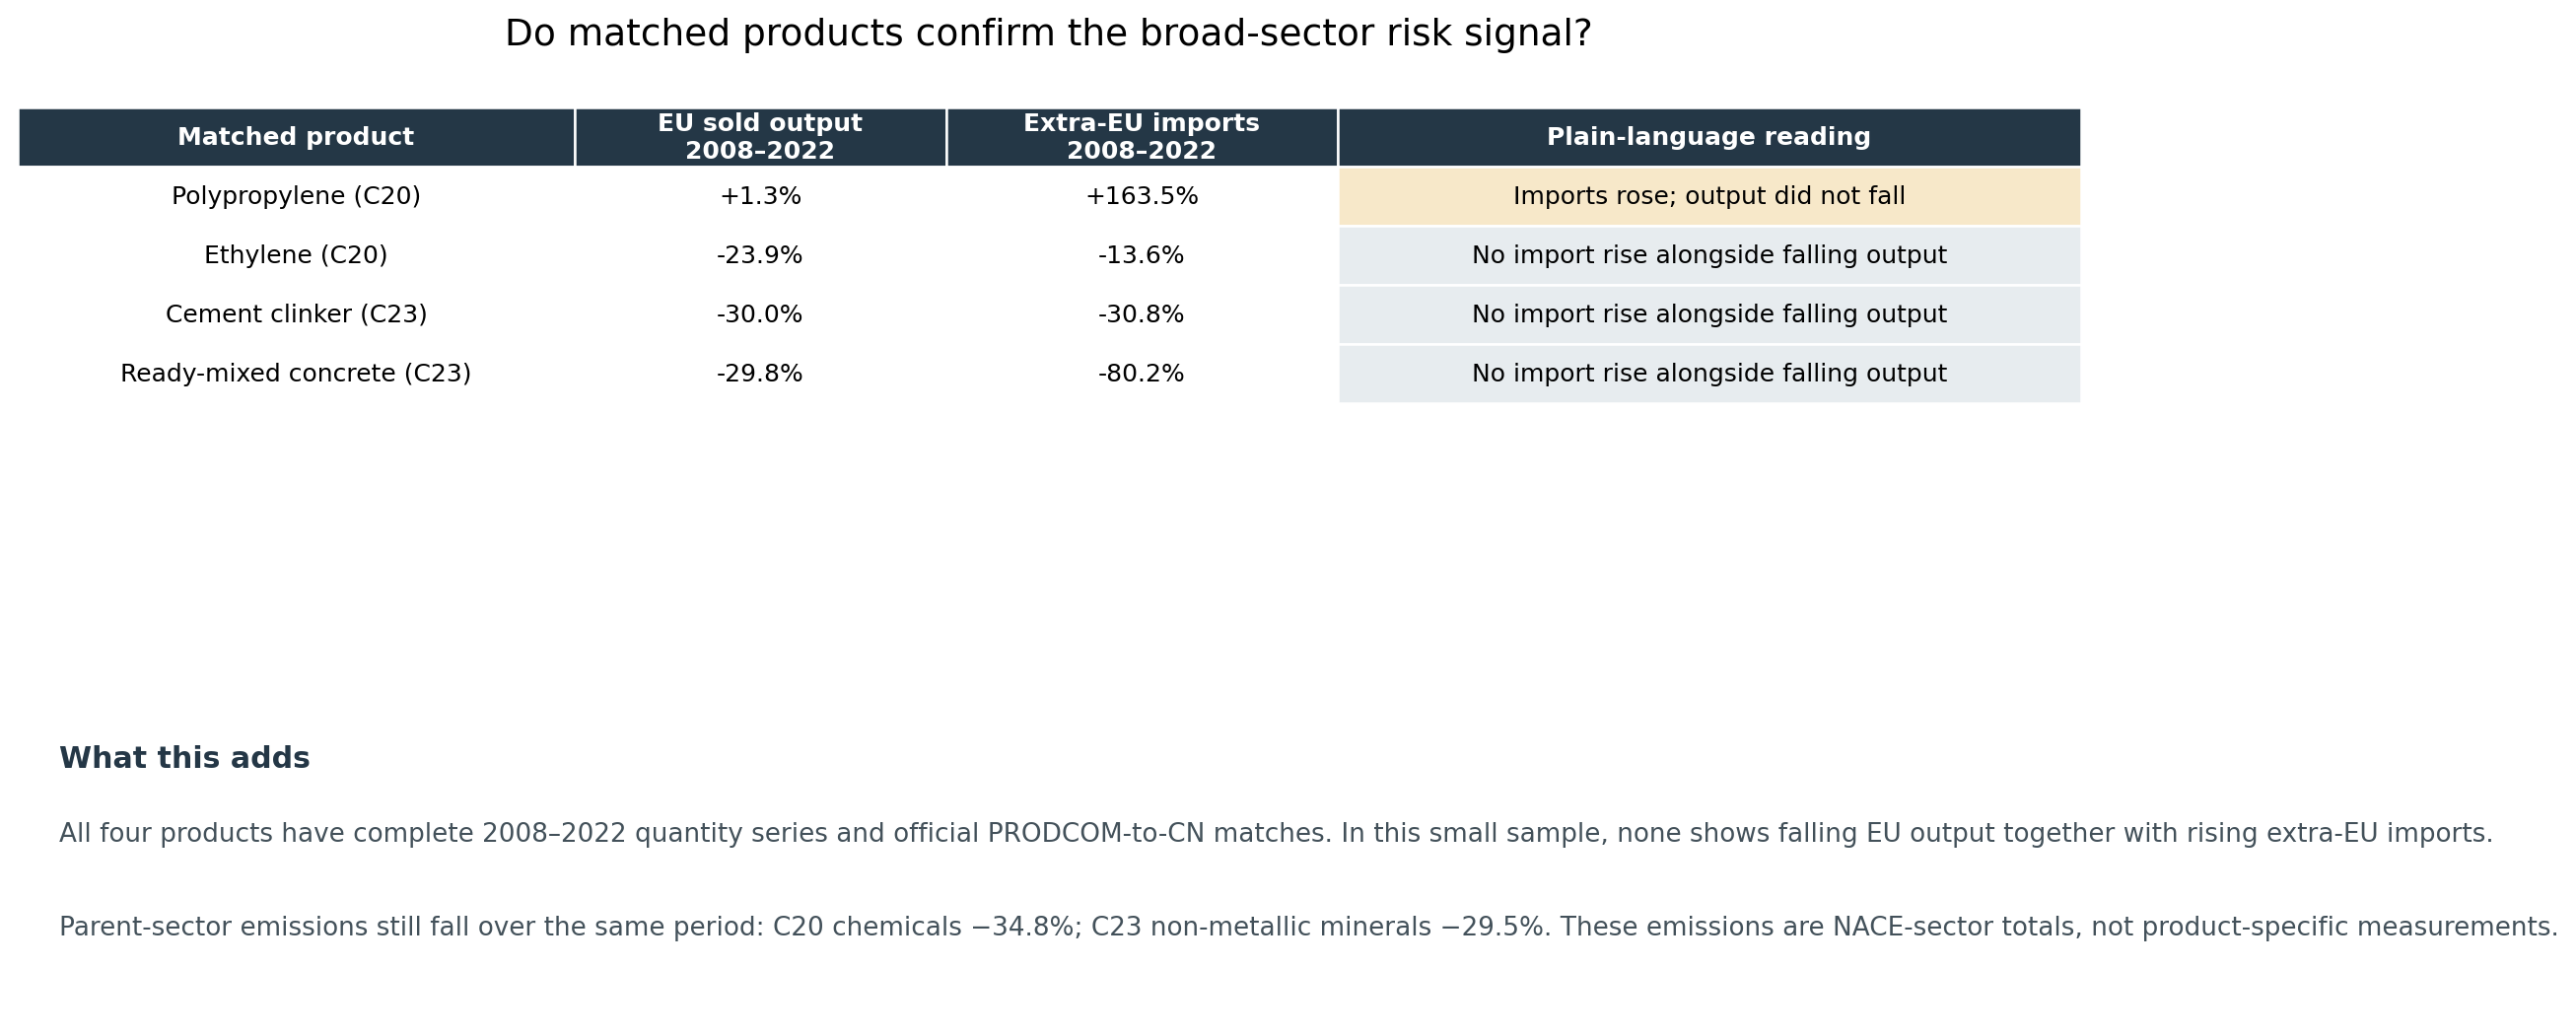

In [ ]:
product_summary = pd.read_csv(OUTPUT_DIR / 'eu27_exact_product_summary.csv')
product_trend_tests = pd.read_csv(OUTPUT_DIR / 'eu27_exact_product_trend_tests.csv')
product_code_mapping = pd.read_csv(OUTPUT_DIR / 'eu27_selected_product_code_mapping.csv')
display(product_summary[['sector', 'product', 'prodcom_code', 'cn8_code', 'prodcom_unit', 'matched_years', 'production_change_2008_2022_pct', 'extra_eu_import_change_2008_2022_pct', 'import_share_2008_pct', 'import_share_2022_pct']])
display(product_trend_tests)
display(product_code_mapping)


#### Product-level results and reproducibility

The displays below provide the endpoint summary, the adjusted trend tests, and the exact code mapping used. The mapping audit records the official reference and units; the annual panel preserves the quantity data used in the charts. The four-product result is a validation check on the broad sector screen, not a conclusion about every product in C20 or C23.

[Open annual production and import quantities](eu27_exact_product_production_extra_eu_imports_2008_2022.csv) · [Open product summary](eu27_exact_product_summary.csv) · [Open trend tests](eu27_exact_product_trend_tests.csv) · [Open official code mapping](eu27_selected_product_code_mapping.csv)


#### Expanded matched-product screen: coverage and results

We extended the product comparison to all production codes in the supplied five target divisions (C17, C19, C20, C23 and C24). The official 2022 crosswalk lets one PRODCOM code use more than one CN8 trade code when every linked CN8 code maps back to that PRODCOM product alone. We require kilograms on both sides and complete PRODCOM quantities for all 15 years. If a multi-code import series is incomplete in a year, that product-year stays missing; missing Comext observations are not filled with zero.

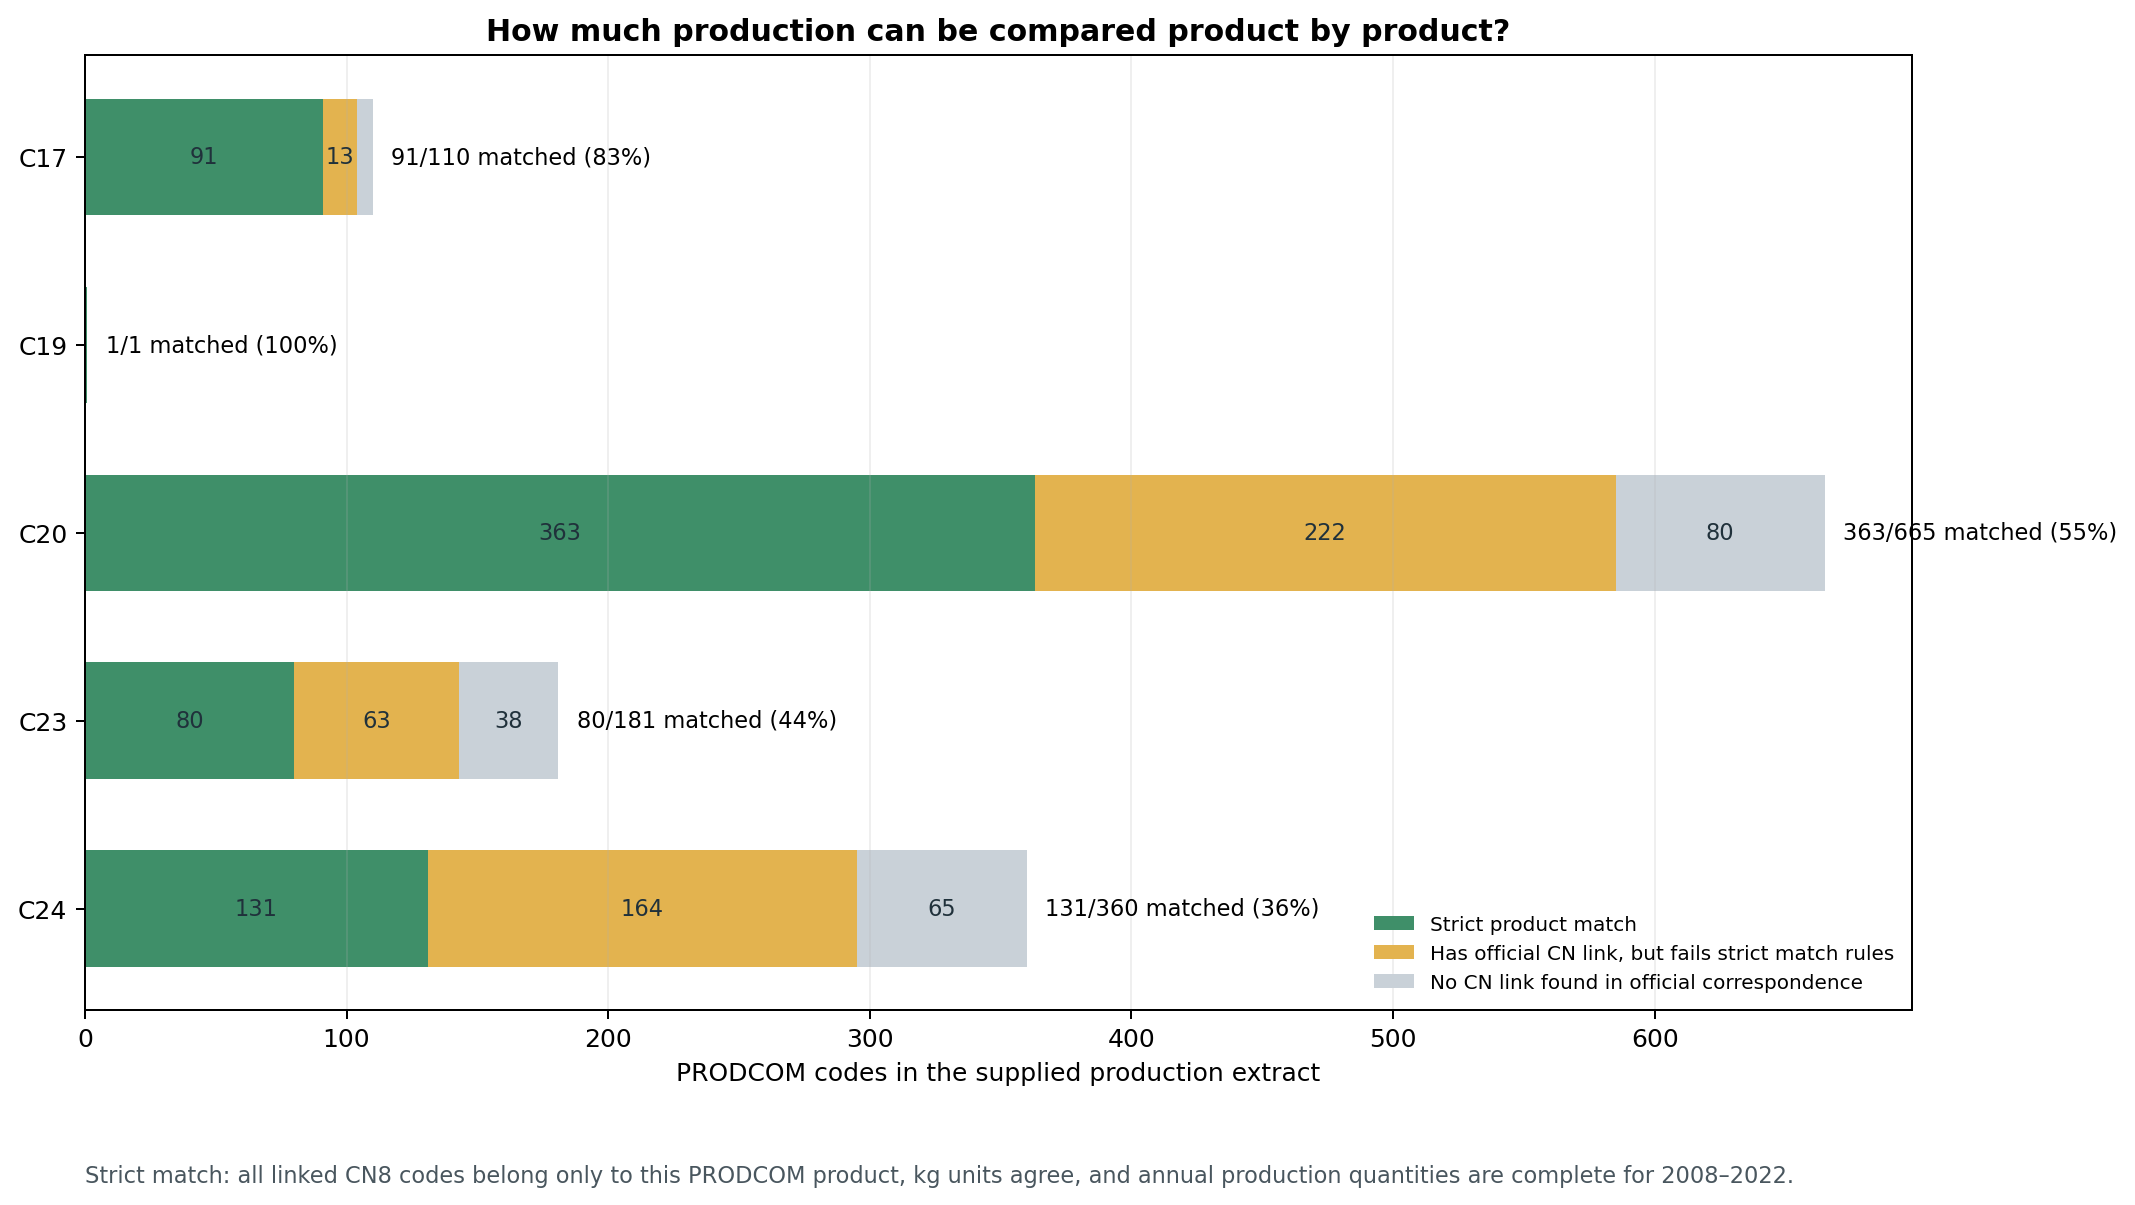

**How to read it:** Each bar starts with the number of product codes in the supplied extract. Green shows products that pass the match rules; gold shows codes with a customs link that fail one or more strict rules; grey shows no CN link found in the official correspondence. The matched fraction is also printed beside each bar. C19's 100% means one matched code out of one supplied code, so it does not represent a full industry screen.

**What is covered:** 666 of 1,317 codes pass the strict rules: C17 91/110, C19 1/1, C20 363/665, C23 80/181, and C24 131/360. Among recorded 2022 sold-production value, the matched products account for about 90% in C17, 66% in C20, 60% in C23, and 47% in C24. C19 is 100% only because the input contains one code. These are coverage measures for this extract, not evidence that every product is economically represented.

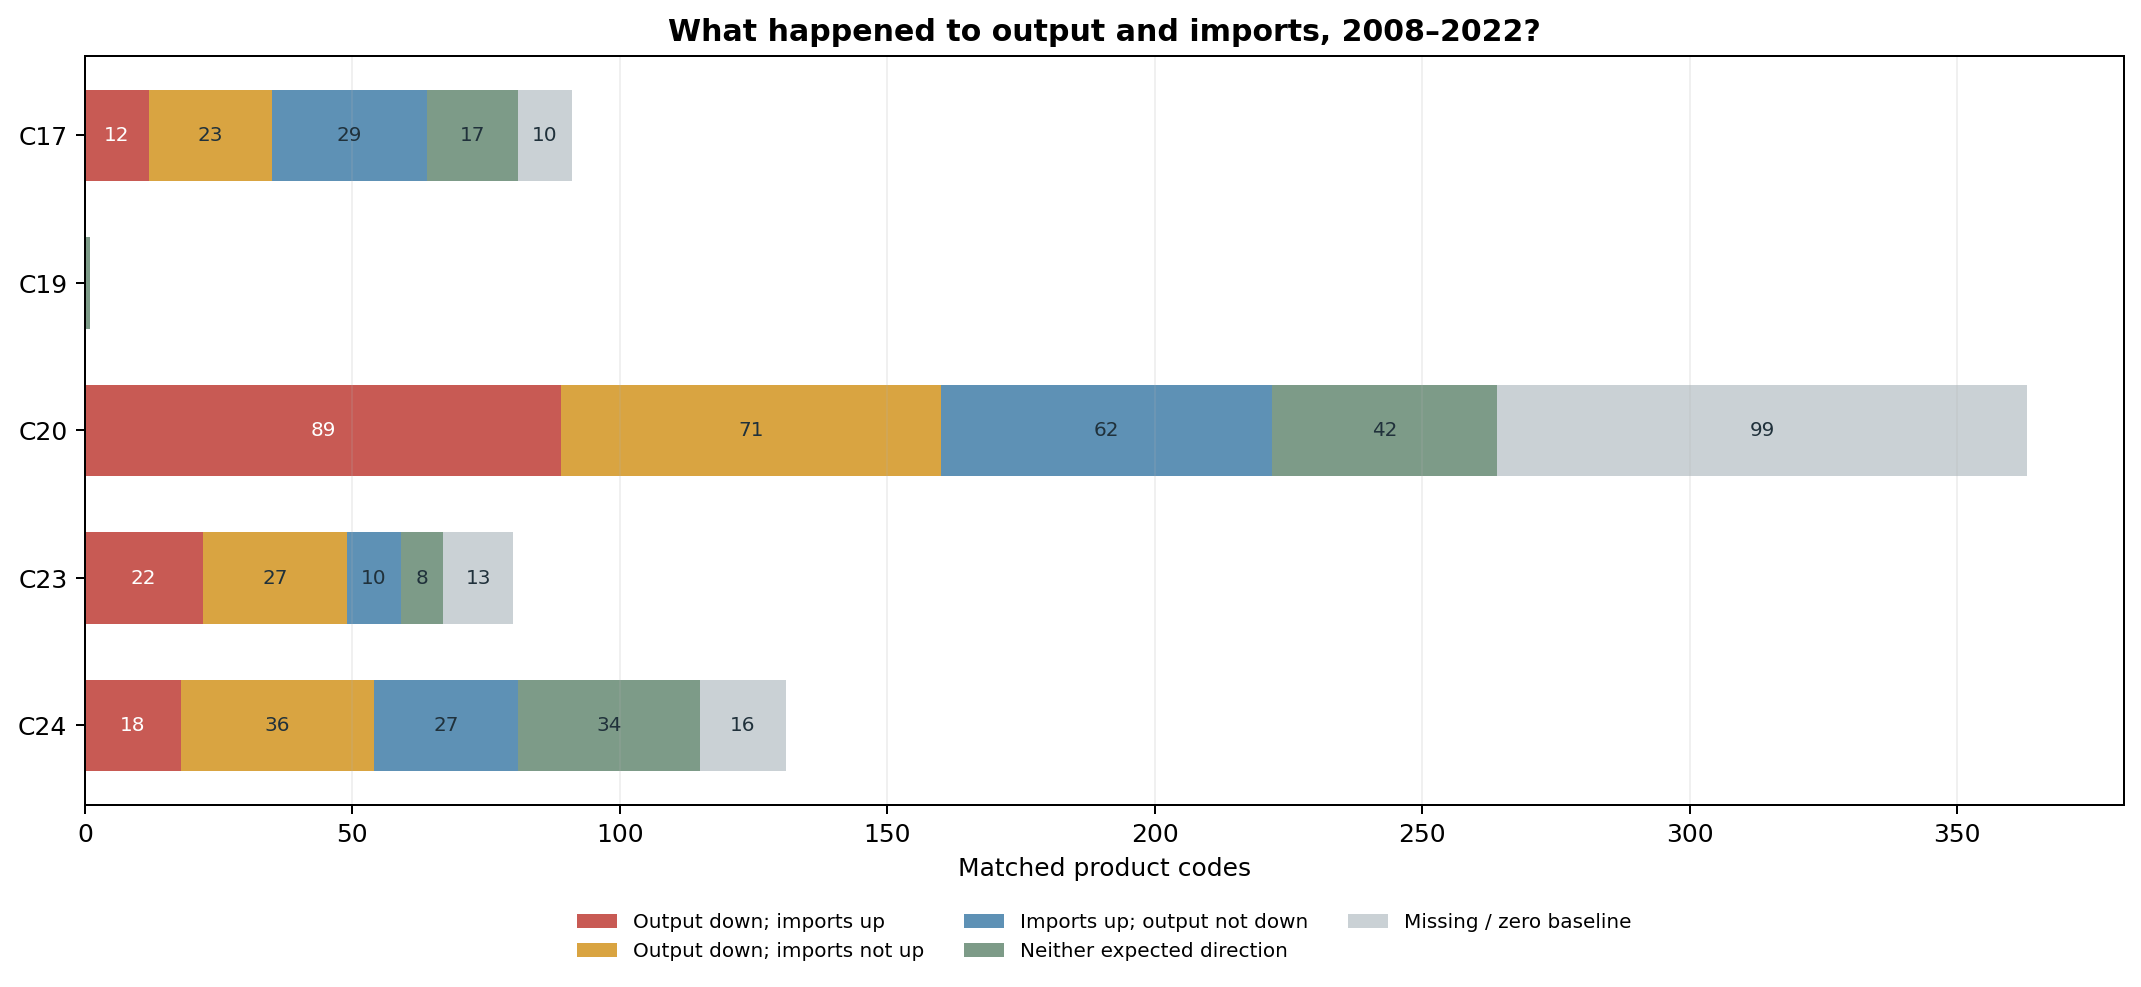

**How to read it:** Each matched product is counted once according to whether its 2008-to-2022 endpoints increased or decreased. Red is the working two-direction signal: EU sold output fell while extra-EU imports rose. Gold means output fell but imports did not rise; blue means imports rose but output did not fall; green means neither expected direction; grey marks a missing import endpoint or zero 2008 import baseline, which prevents a percentage-growth classification.

**What is happening:** 141 of the 666 matched products fall into the red group: 12 in C17, 89 in C20, 22 in C23, and 18 in C24. These are candidates for closer investigation, not confirmed leakage. Missing or zero-baseline trade endpoints leave 138 products unclassified by this percentage-change screen. The remaining products show other direction patterns.

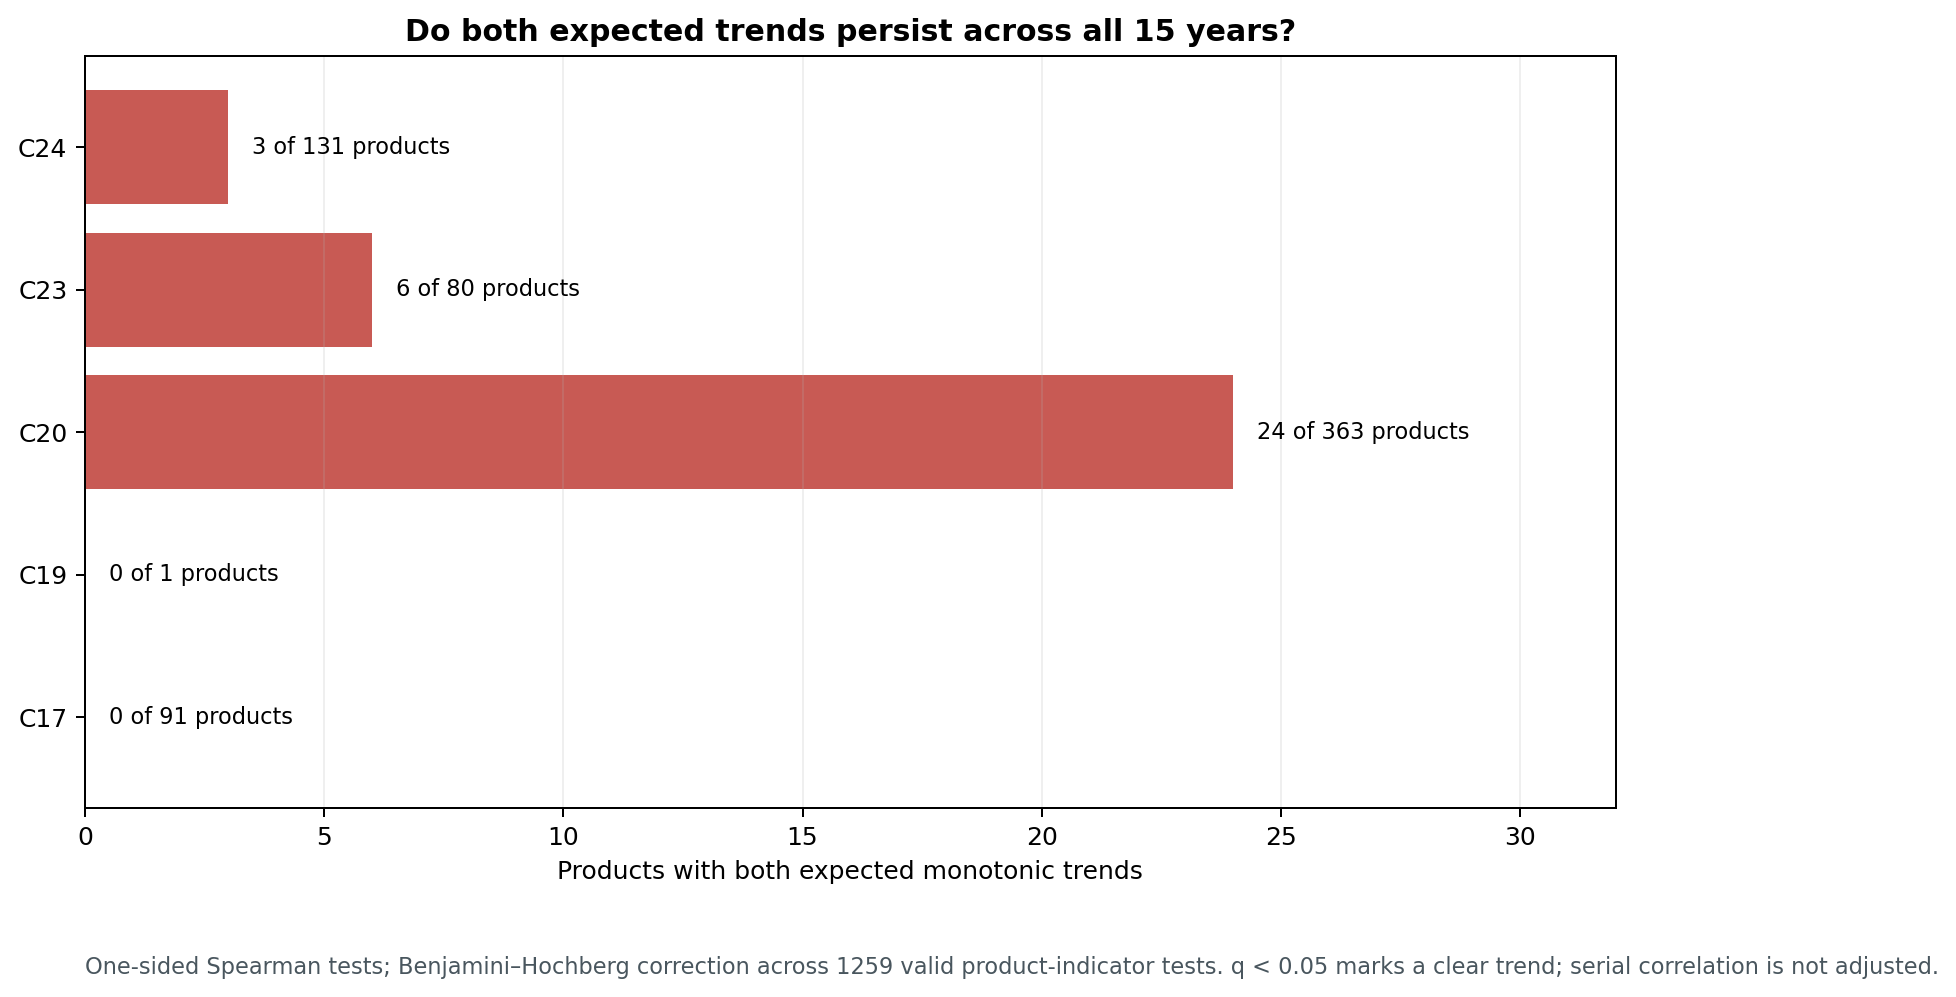

**How to read it:** This chart asks whether each product's annual production series trends downward and its imports trend upward consistently across 2008–2022. The tests are one-sided Spearman rank checks; adjusted q-values account for the family of valid product-indicator tests. The chart counts products where both adjusted tests have q < 0.05.

**What is happening:** 33 products meet both trend criteria: 24 in C20, six in C23, and three in C24. No products in C17 or the single C19 code meet both. These exploratory tests do not account for year-to-year autocorrelation, so they are a cautious consistency check, not a causal test.

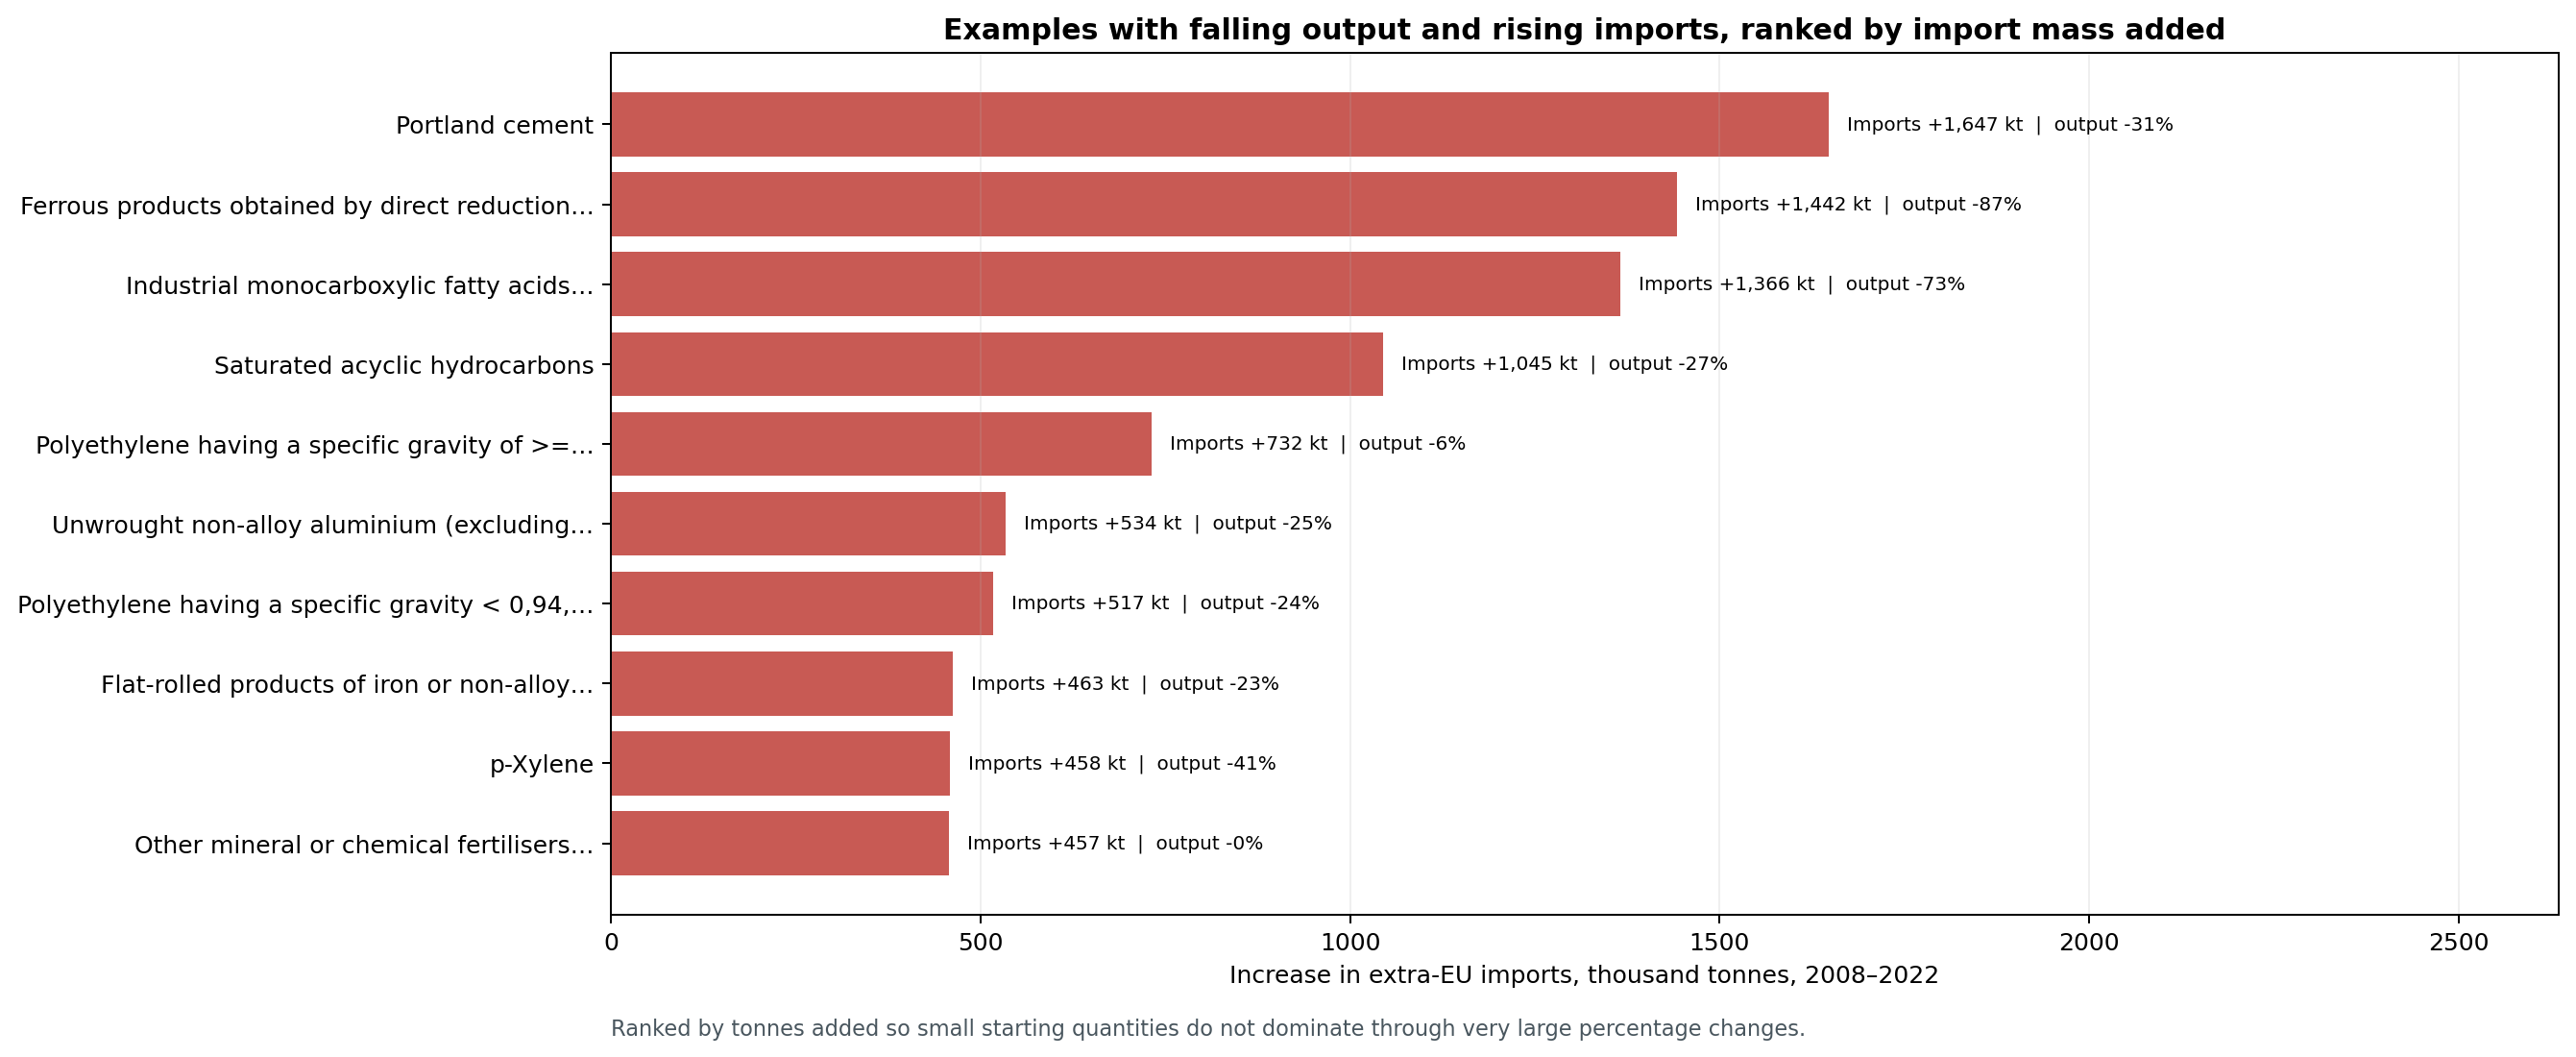

**How to read it:** These ten examples meet the endpoint screen and are ranked by the amount of extra-EU import mass added, in thousand tonnes. The labels show the import increase and the change in EU sold output. Ranking by tonnes avoids letting a very small 2008 import baseline make a modest absolute change look enormous in percentage terms.

**Why this is still a risk screen:** PRODCOM records sold production quantity, while Comext records extra-EU imports; this comparison excludes intra-EU trade and does not calculate total domestic supply or apparent consumption. The official PRODCOM–CN 2022 correspondence is applied to the historical series, so nomenclature changes may affect some products. Most importantly, we do not have product-level emissions intensity or carbon embodied in imports for these 666 matched goods. The charts show where production and trade moved together in the directions of the hypothesis; they do not show that one caused the other.

Official references: [Eurostat PRODCOM information](https://ec.europa.eu/eurostat/en/web/prodcom/information-data) explains its product codes and CN references; the [PRODCOM 2022 list](https://op.europa.eu/en/web/eu-vocabularies/dataset/-/resource?uri=http://publications.europa.eu/resource/dataset/prodcom2022) supplies the classifications; and the [Comext API guide](https://ec.europa.eu/eurostat/web/user-guides/data-browser/api-data-access/api-getting-started/comext-database) documents access to detailed trade data.

##### Expanded results and audit files

[Open the product-match coverage audit](eu27_prodcom_cn_match_coverage.csv) · [Open sector coverage summary](eu27_broad_match_coverage_summary.csv) · [Open annual matched-product panel](eu27_broad_matched_product_panel_2008_2022.csv) · [Open product endpoint and trend summary](eu27_broad_matched_product_summary.csv) · [Open trend tests](eu27_broad_matched_product_trend_tests.csv) · [Open CN8 import data](eu27_broad_matched_product_cn8_imports_2008_2022.csv)


In [ ]:
broad_product_coverage = pd.read_csv(OUTPUT_DIR / 'eu27_broad_match_coverage_summary.csv')
broad_endpoint_counts = pd.read_csv(OUTPUT_DIR / 'eu27_broad_endpoint_pattern_counts.csv', index_col=0)
broad_trend_counts = pd.read_csv(OUTPUT_DIR / 'eu27_broad_trend_pattern_counts.csv')
broad_product_summary = pd.read_csv(OUTPUT_DIR / 'eu27_broad_matched_product_summary.csv')
broad_trend_tests = pd.read_csv(OUTPUT_DIR / 'eu27_broad_matched_product_trend_tests.csv')
display(broad_product_coverage)
display(broad_endpoint_counts)
display(broad_trend_counts)
display(broad_product_summary.query("endpoint_pattern == 'Output down; imports up'").sort_values('extra_eu_import_increase_tonnes', ascending=False).head(20))
display(broad_trend_tests.query('clear_expected_monotonic_trend').head(30))


The matched panel and audit files are saved beside this notebook. The code and tables above let us inspect individual products, not just the summary charts.

## 12. What project reports say about leakage

The project type tells us **what activity the project is changing**. For example, afforestation plants trees on land previously used for farming or left degraded; improved forest management changes timber harvesting; soil-carbon agriculture changes farming practices. Leakage accounting asks whether those changes shift farming, timber supply, or other activity outside the project's boundary.

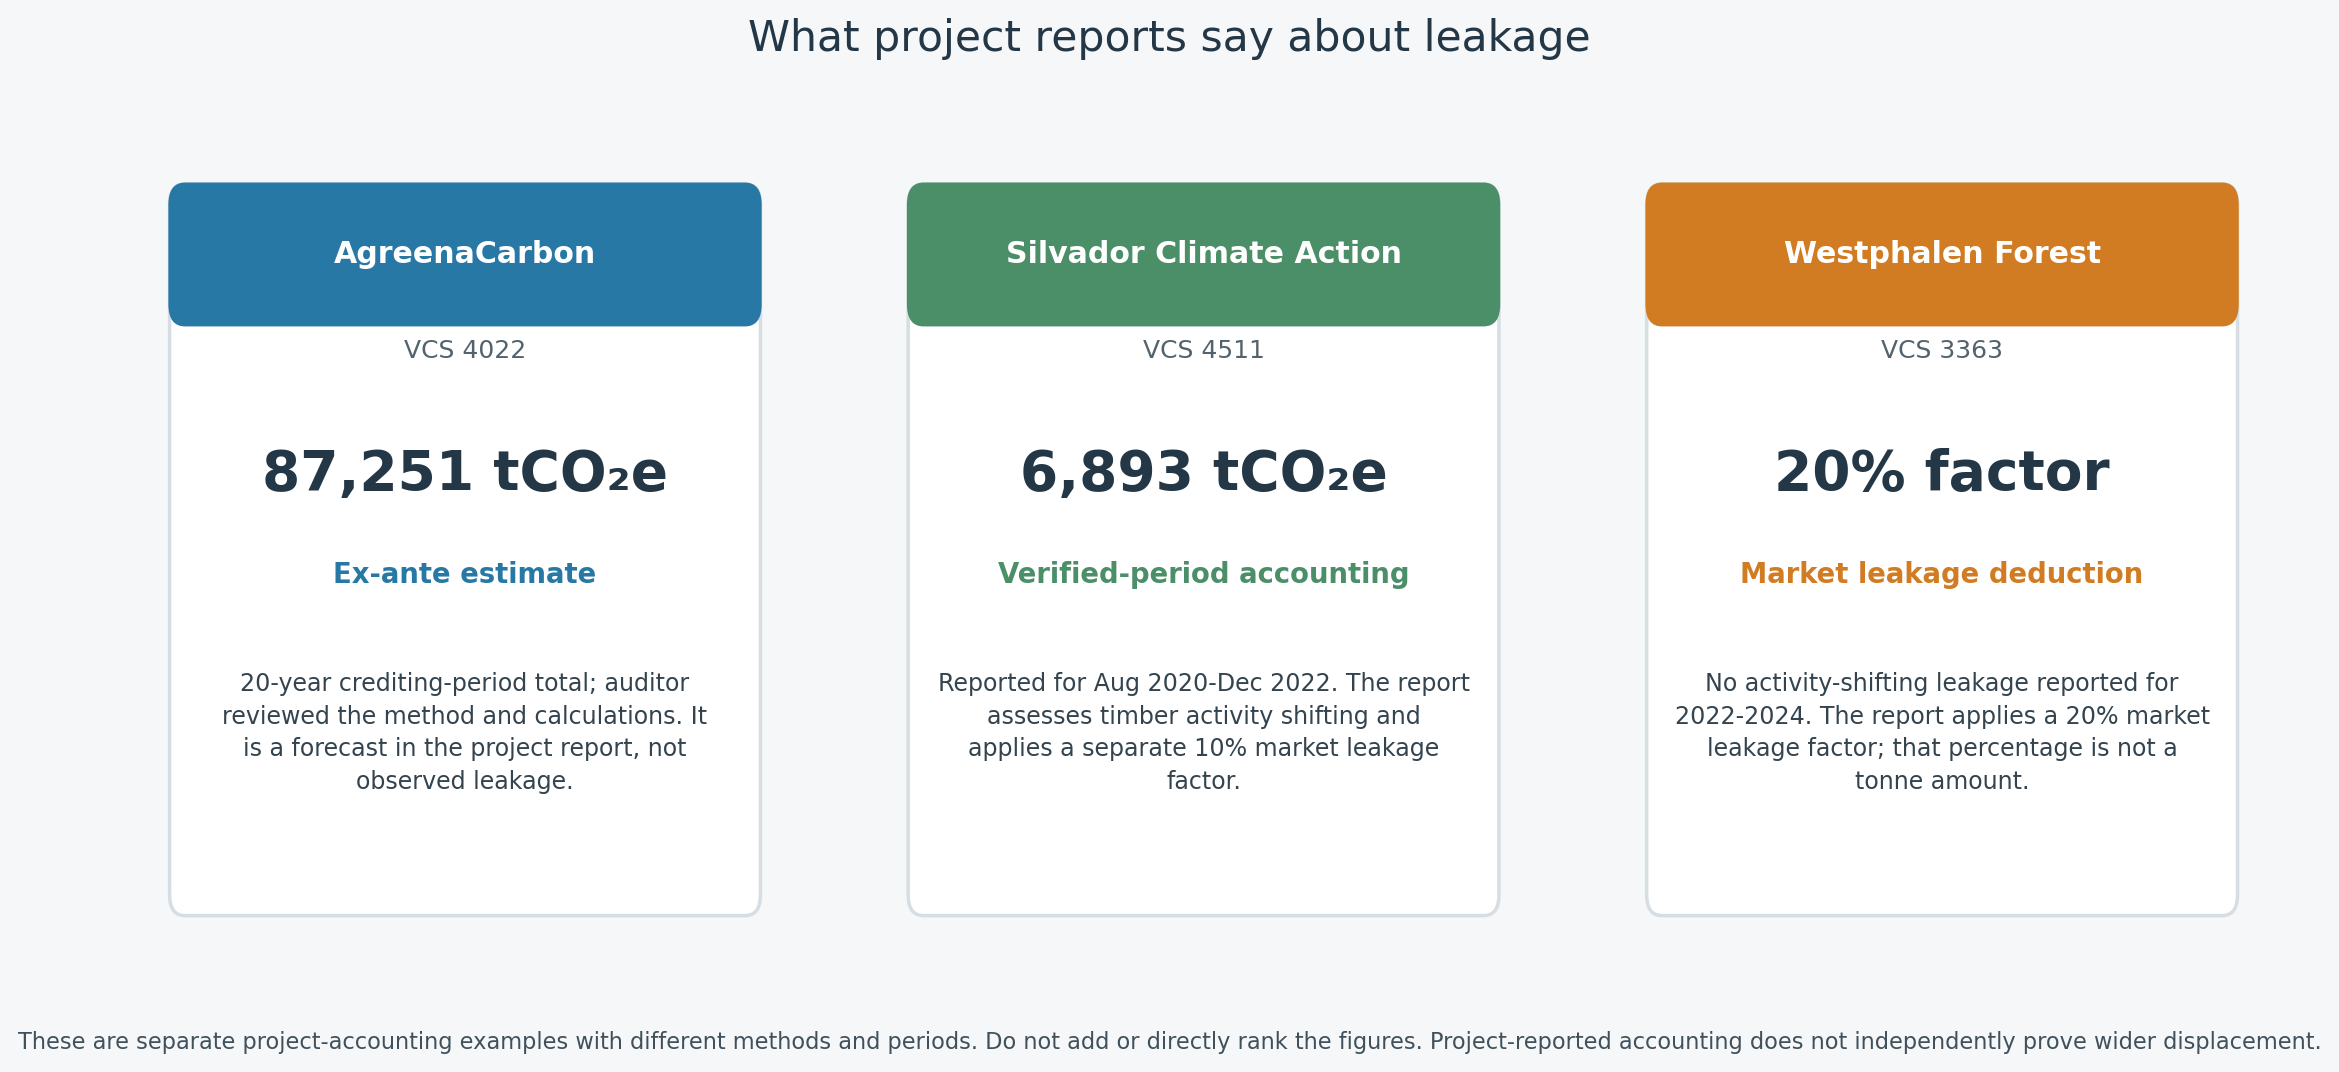

| Project | What the report says | Evidence label |
|---|---|---|
| **AgreenaCarbon (VCS 4022)** - sustainable agriculture / soil carbon | 87,250.58 tCO2e as an ex-ante leakage estimate over the project's 20-year crediting period. The VVB reviewed the method and calculations; this is not a realized monitoring-period amount. | Project-reported estimate |
| **Silvador Climate Action (VCS 4511)** - improved forest management | 6,893 tCO2e for the verified period 2020-08-01 to 2022-12-31. The VVB report describes the MARketz method and a 10% market leakage factor; its accounting table reports the period total. | Project-reported verified-period accounting |
| **Westphalen Forest (VCS 3363)** - logged-to-protected forest | No activity-shifting leakage reported for 2022-2024 based on timber harvest outside the project area; a 20% market-leakage factor was applied in the net calculation. The 20% is not a tonne amount. | Project-reported monitoring and deduction factor |

These examples illustrate three different things: an estimate, a period total, and a deduction factor. They should not be added or compared as if they shared the same period and method. A project report documents how the project applies its accounting rules; it does not independently establish economy-wide displacement beyond that accounting boundary.

### Additional desk-screening leads

These two records appeared in document-based secondary summaries during the expanded review. The underlying report claims still need direct checking, so they are not included in the chart or counted among the three source-checked examples.

| Project | Secondary-source finding to verify | Current status |
|---|---|---|
| **Rotunda Forest Carbon Project (VCS 2386)** - logged-to-protected forest | A secondary summary describes a quantified leakage approach, but says the deduction details are not stated in the available records. It lists monitoring, issuance/review, project description, and validation/verification documents. | Primary report review pending; no amount or factor extracted |
| **Carpathia Forest Carbon Project (VCS 3280)** - improved forest management | A secondary summary reports a conflict: validation material says leakage was quantified, while monitoring material says leakage was not addressed. No deduction percentage or emissions amount was available in its extracted fields. | Primary report review pending; reconcile report versions and monitoring period |

[Rotunda document-based summary](https://carbonmeld.com/projects/rotunda-forest-carbon-project/) · [Carpathia document-based summary](https://carbonmeld.com/projects/carpathia-forest-carbon-project/) · [Carpathia validation report identified in public search](https://www.carboncheck.co.in/sites/default/files/2024-05/CCIPL_1983_Final%20Validation%20Report_v3.0_Clean.pdf)

These secondary summaries help prioritize follow-up; they are not substitutes for examining the primary documents. The review queue has 70 projects. Three have source-checked report findings; two more have desk-screening leads; 65 records remain unexamined in this pass. The remaining cases are not assumed to have zero or no leakage.

Sources for the three source-checked examples: AgreenaCarbon [VCS validation report](https://terrapass.com/wp-content/uploads/2025/02/AgreenaCarbon-Project-VCS-Validation-Report.pdf), pp. 42-43; Silvador [project data room](https://www.silvador.ro/dataroom), downloadable joint validation/verification report, pp. 98-103 and 127-128; Westphalen [monitoring report](https://carbonmeld.com/docs/westphalen-forest-carbon-project-b9f64c/417af426c104a0cf.pdf), 2022-2024 monitoring period.


In [ ]:
# Read the three source-checked examples and the separate secondary-source leads.
project_leakage_examples = pd.read_csv(OUTPUT_DIR / 'offset_project_leakage_report_examples.csv')
secondary_source_leads = pd.read_csv(OUTPUT_DIR / 'offsetdb_secondary_source_leads.csv')
display(project_leakage_examples)
display(secondary_source_leads)


## 13. What would establish causal displacement?

A causal claim needs a connected chain: a policy or project changes incentives; production or land activity changes; supply shifts to another place; and emissions rise outside the first boundary because of that shift.

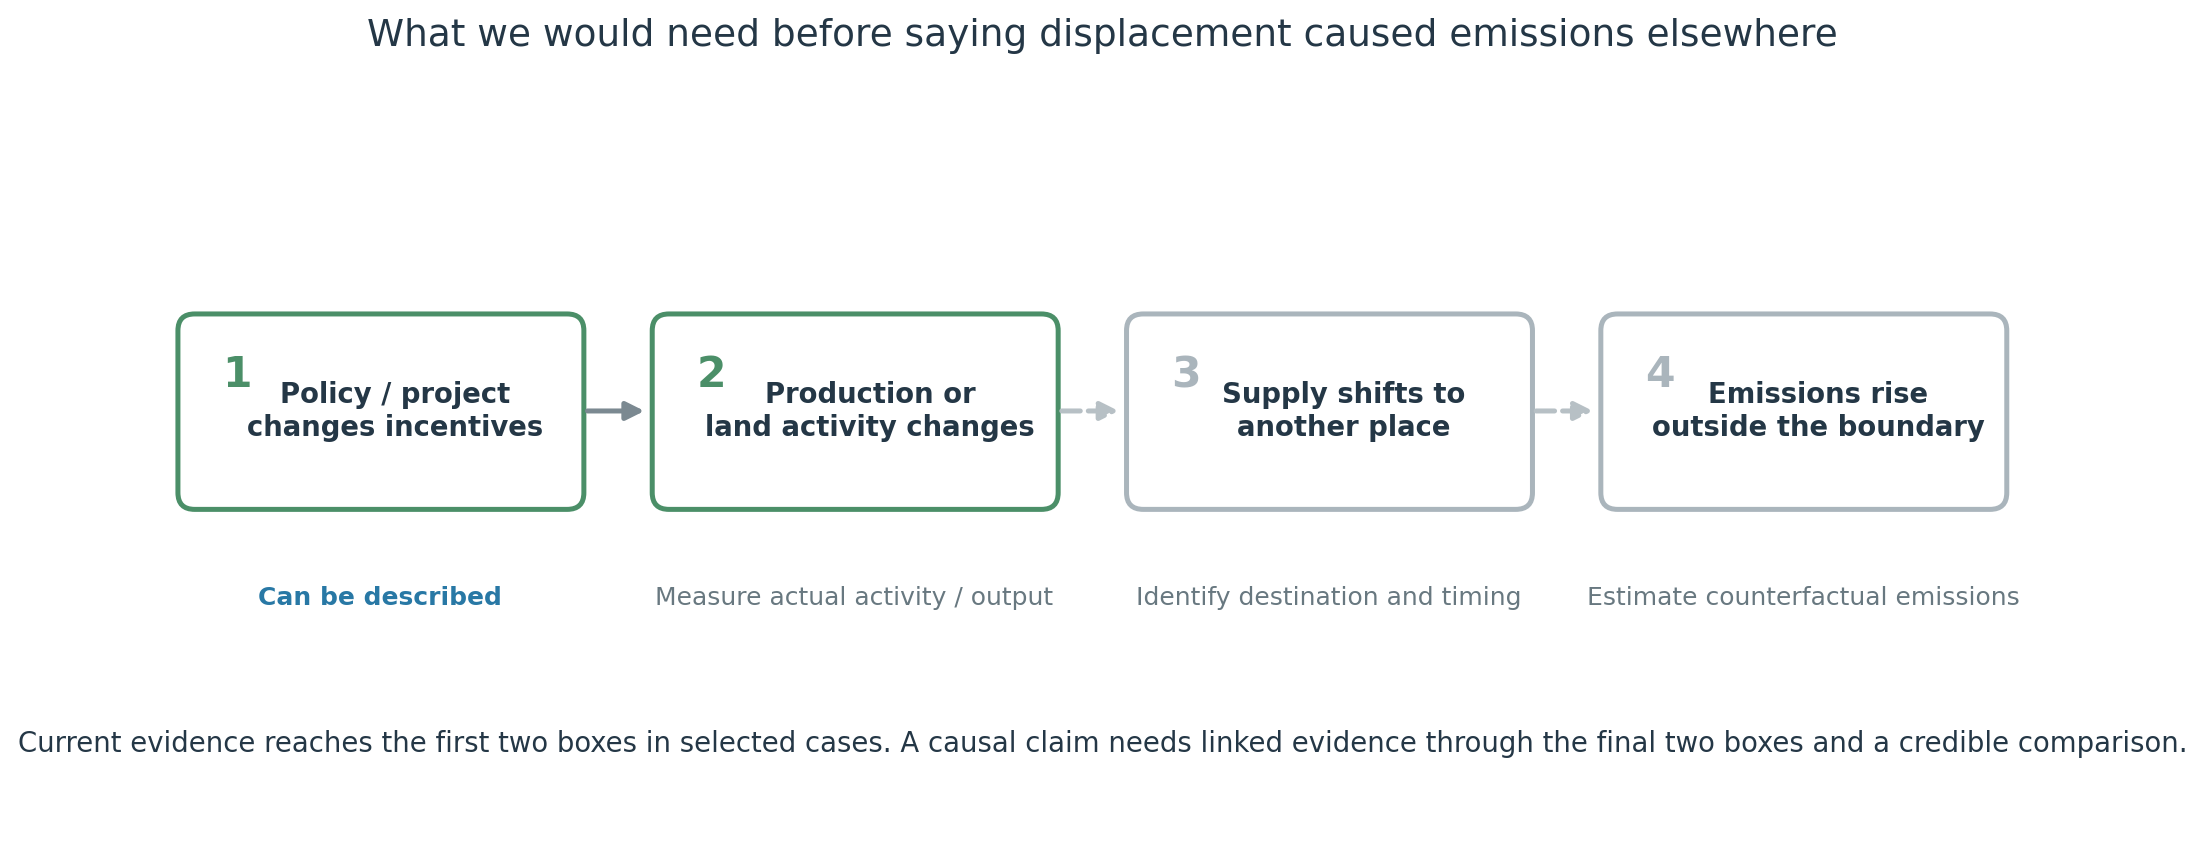

Our current industrial panel describes EU-level trends. The project reports describe their own boundaries and methods. We do not yet have linked evidence showing where displaced production went, whether it increased, and what emissions it caused compared with what would otherwise have happened.

A simple audience-facing test is: **Can we show the change, the destination, the emissions effect, and a fair comparison with what would have happened without the policy or project?** At present the answer is no, so this project does not label any case as causally established leakage.


## 14. 2030 outlook: conditional trend scenarios

This projection asks a simple question: **if past growth rates continued, how might the four core indicators and the embodied-emissions trade balance look in 2030?** It is a scenario exercise, not a prediction that leakage will occur.

The shared comparison ends in 2022, because the OECD modeled emissions embodied in extra-EU imports and exports in the available extracts run through 2022. Some Eurostat inputs have newer observations, but the measures are not all aligned beyond that year. We therefore anchor all scenarios on the common 2022 values.

We project C20 (chemicals) and C23 (other non-metallic mineral products) for the four core indicators, using the three historical windows below. A supplementary embodied-trade balance projection covers C19 (coke and refined petroleum), C20 and C23, where OECD observations exist for both import and export flows.

For each core measure, we estimate an average annual percentage pace over three historical windows, then compound it from the observed 2022 value. This is a log-linear trend calculation:

- **Long-run pace:** 2008-2022 trend.
- **Middle-period pace:** 2013-2022 trend.
- **Recent pace:** 2018-2022 trend.

Each core-indicator chart is indexed to its own 2022 value. An index of 100 is the 2022 level; 120 would mean 20% higher than 2022. The paths are based on fitted historical rates. They are not probability intervals, and they do not include future policy, technology, demand or price changes.

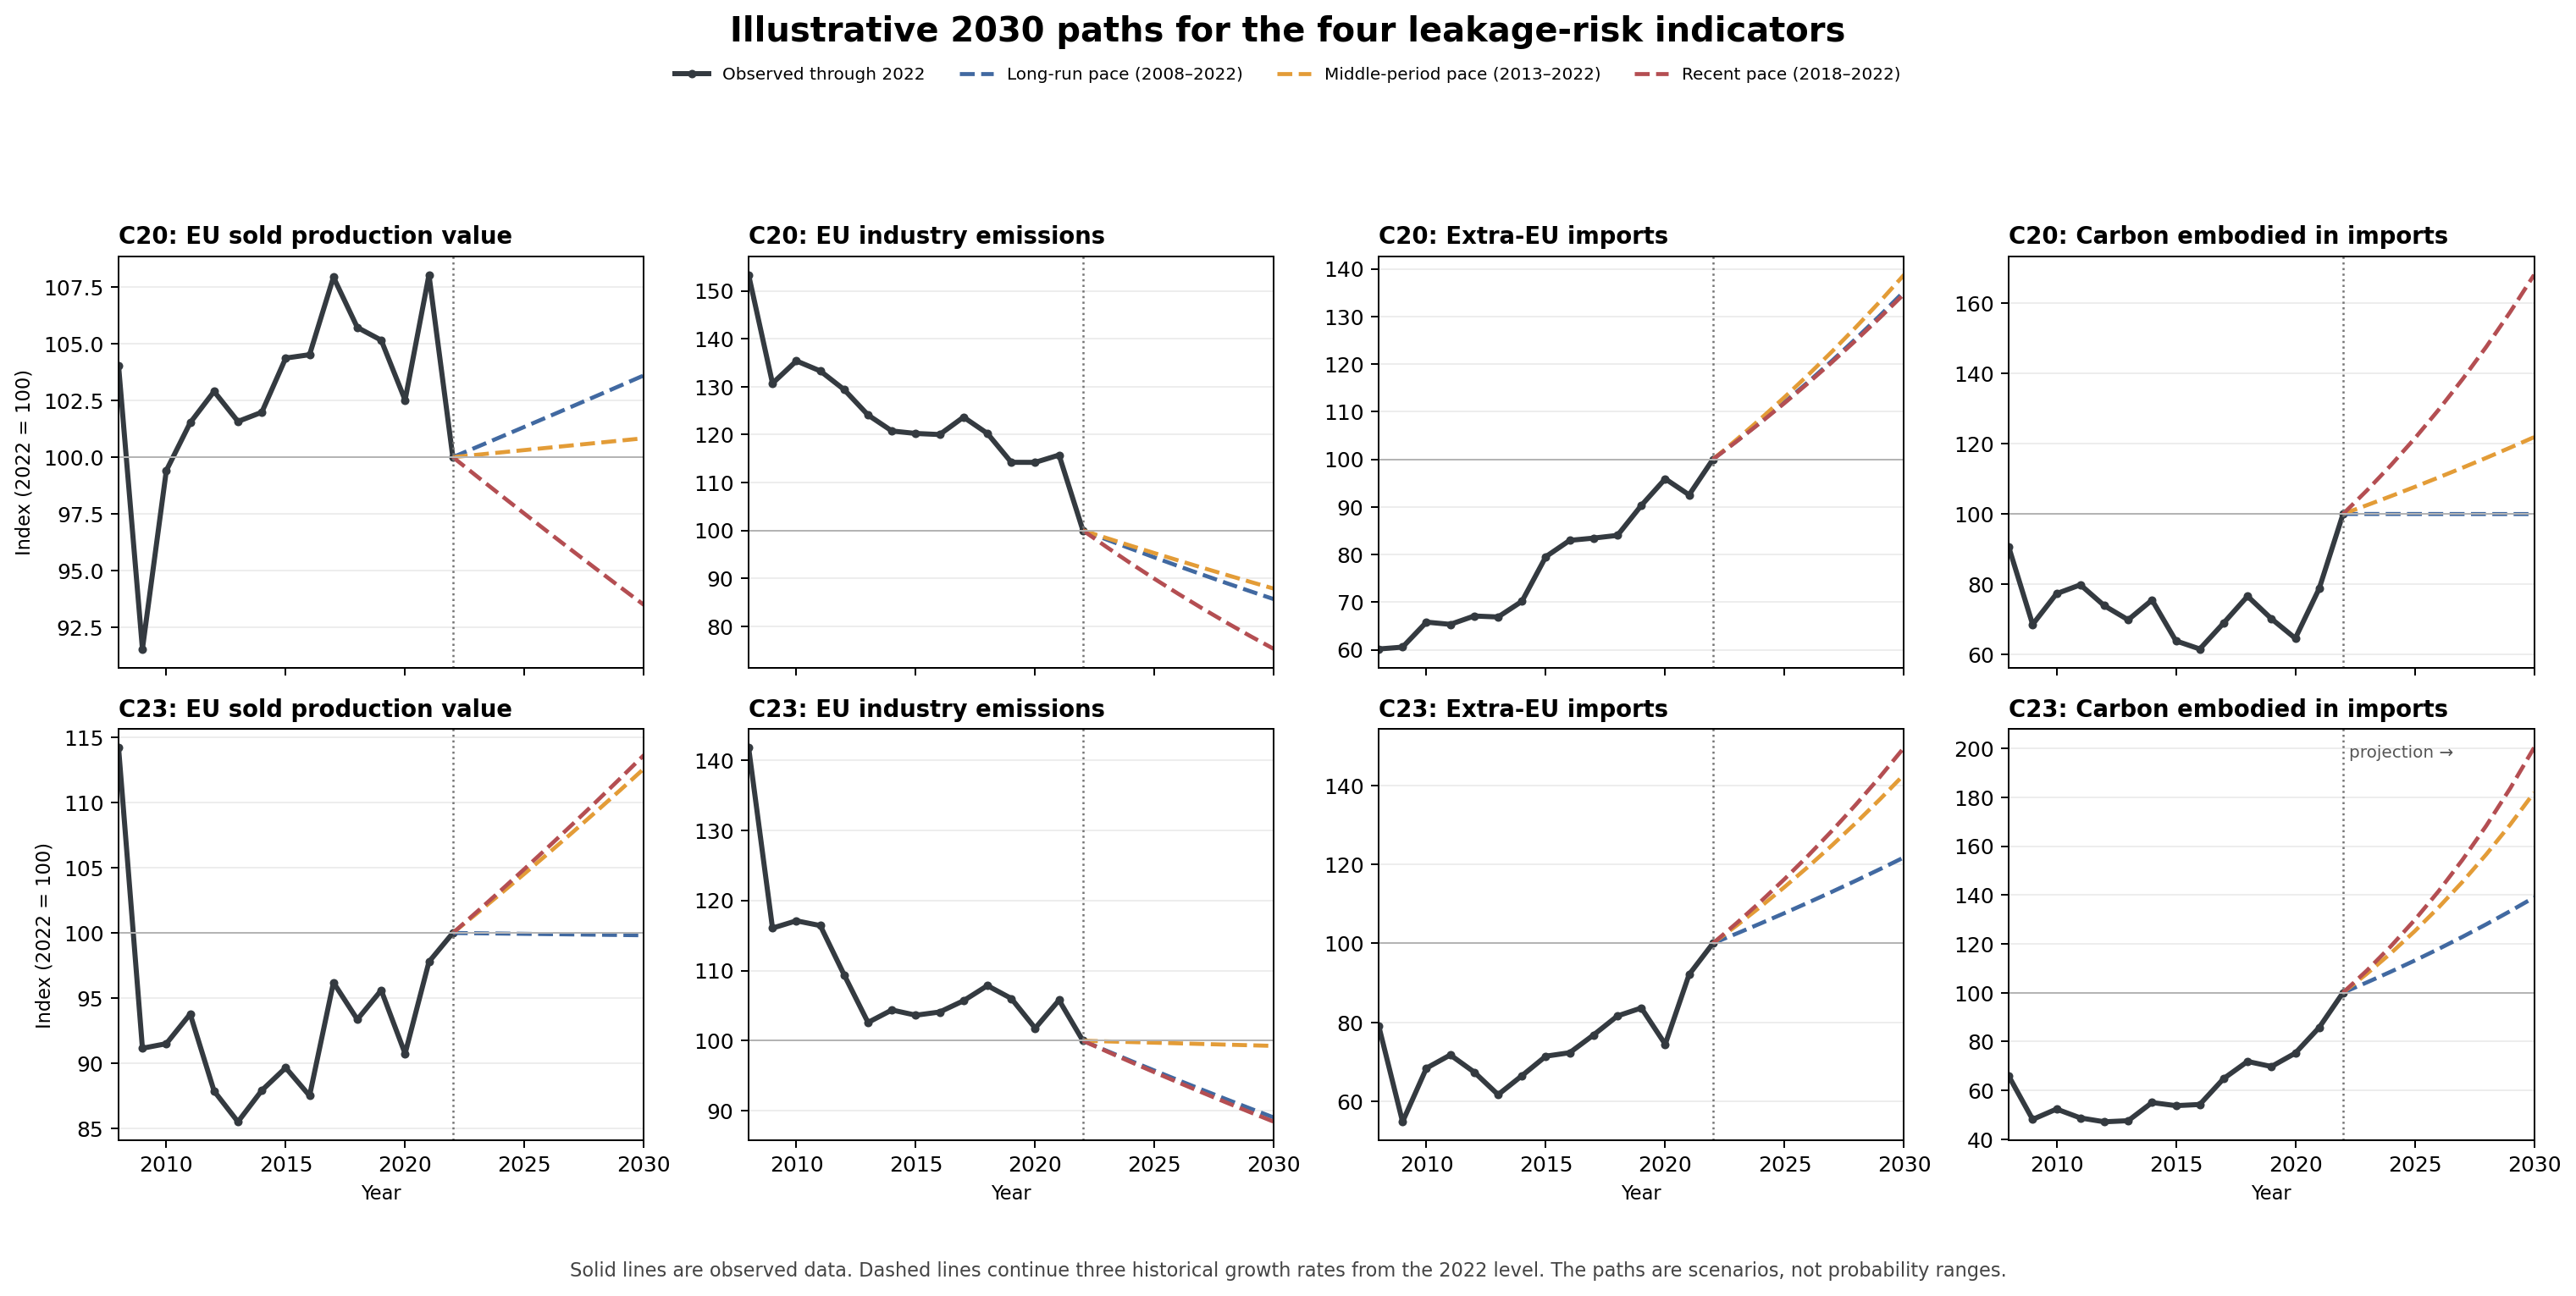

**How to read the chart:** Solid lines show observed data through 2022. Dashed lines show what each historical trend window would imply through 2030. The dotted vertical line marks the forecast start. Read each indicator against its own 2022 level; do not compare the vertical distance between different indicators.

### What the core-indicator scenarios show

In **C20**, the recent-pacing path continues all four directions associated with a risk signal: sold-production value falls to about **93** on the 2022=100 index, emissions to **75**, while extra-EU imports rise to **135** and imported carbon to **168**. The long-run path instead puts production slightly above its 2022 level and imported carbon near 100. The four-direction pattern therefore depends on the recent trend continuing; it is not a stable result across all historical windows.

In **C23**, the three paths put emissions below the 2022 level and extra-EU imports and imported carbon above it. Sold-production value is almost unchanged under the long-run pace and rises under the two shorter-window paces. Those paths do not preserve the full falling-production / rising-import pattern.

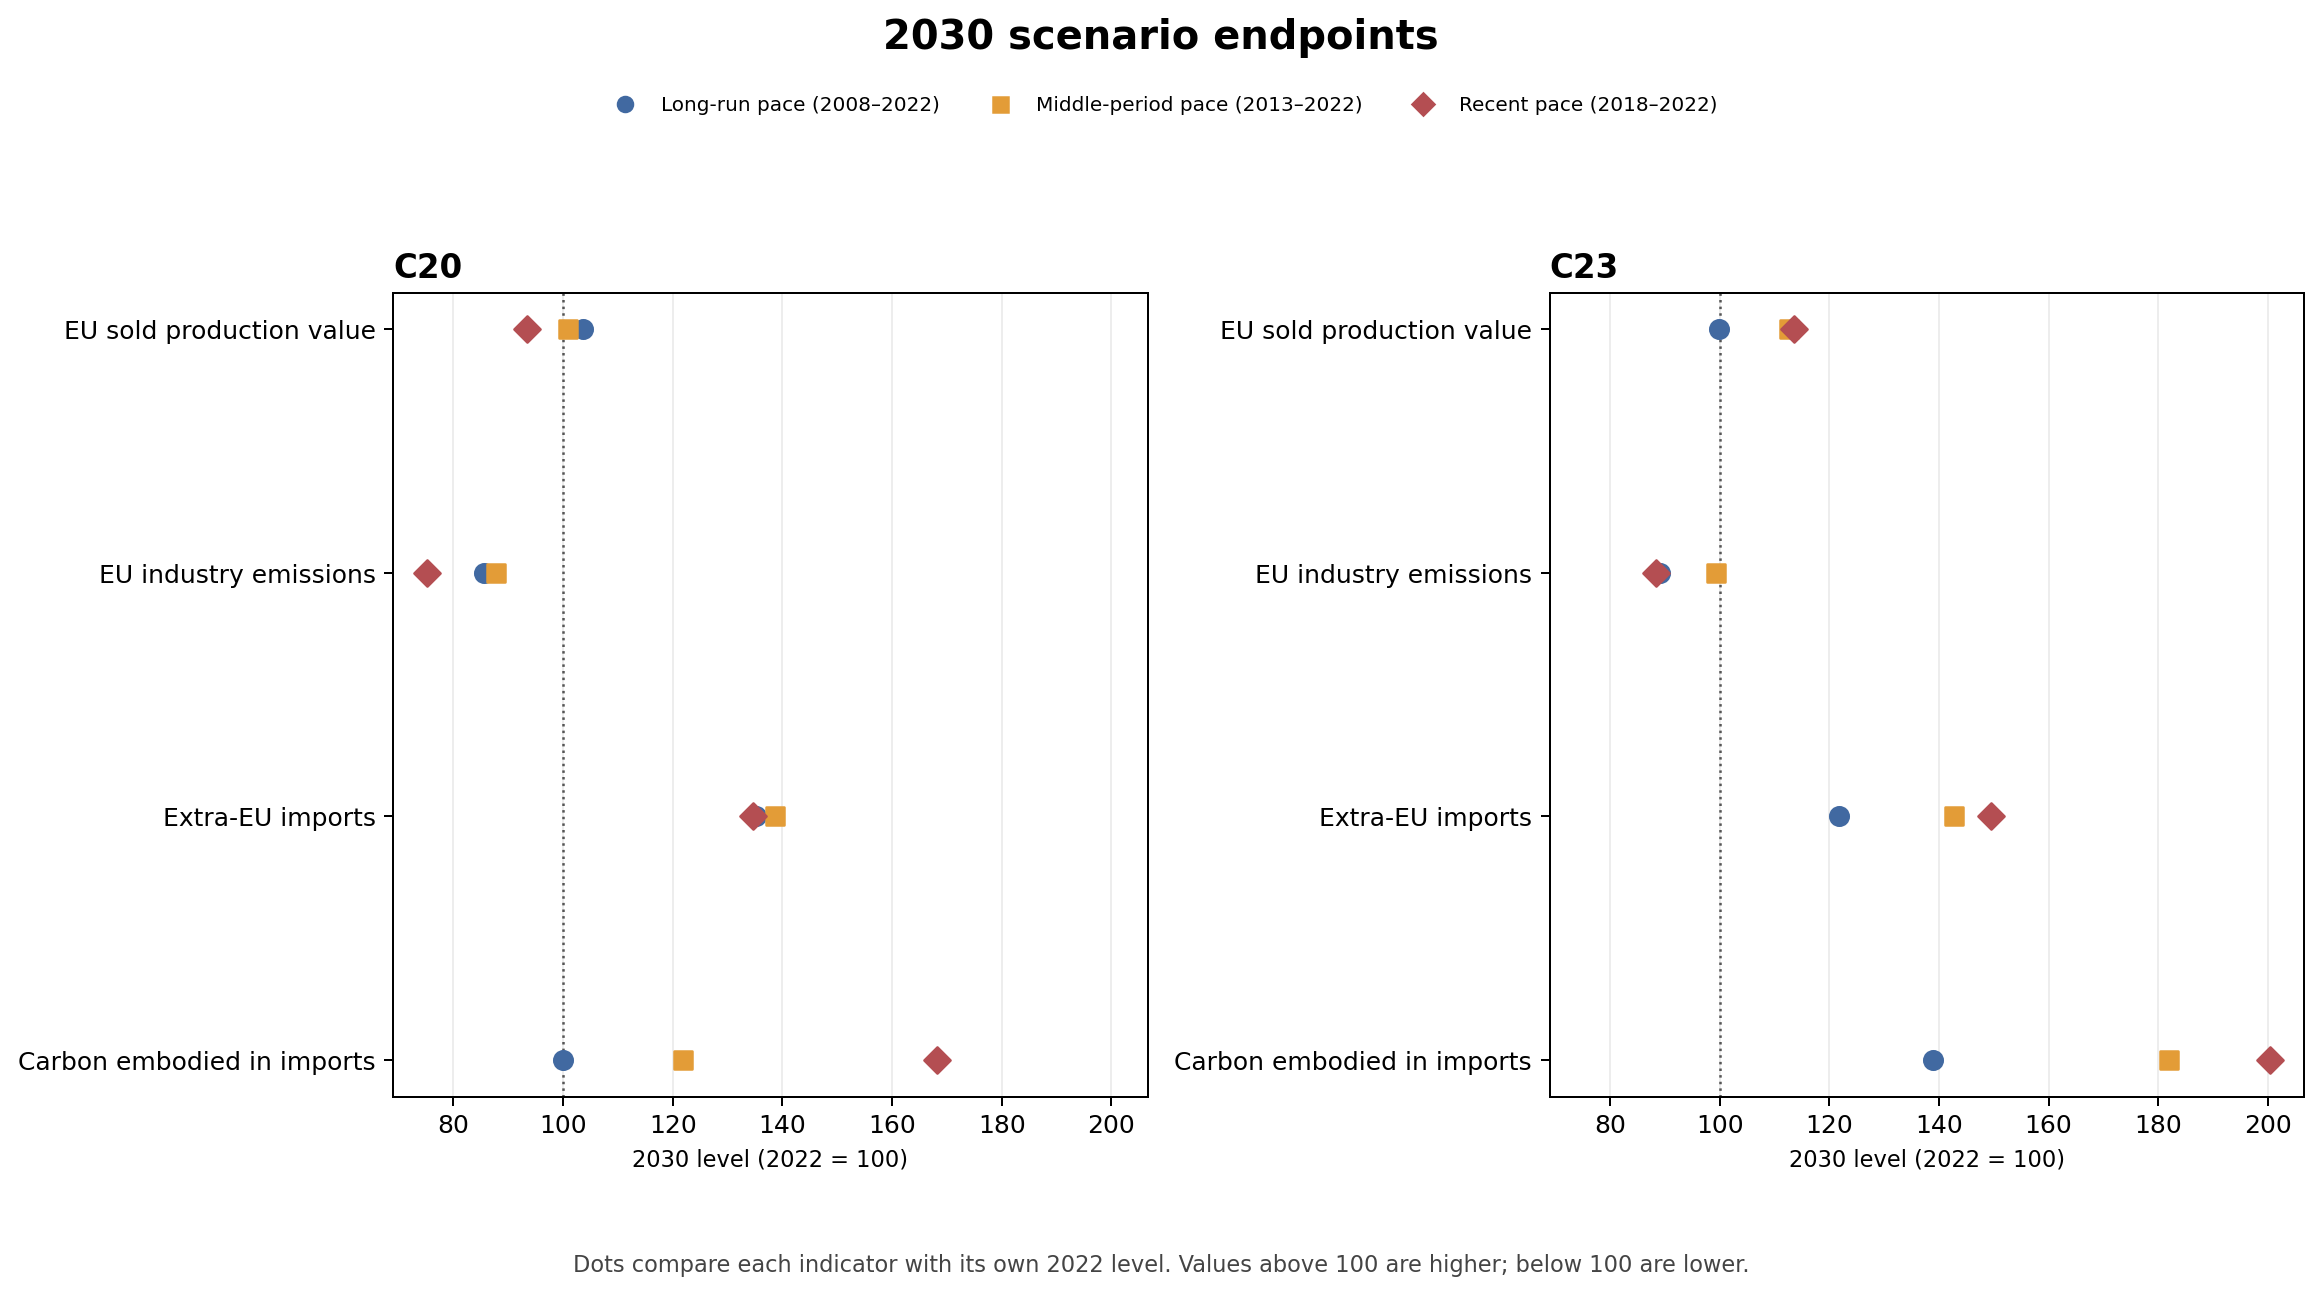

**What this means:** The core scenarios help show which parts of the historical signal persist under different assumptions. They do not estimate how much leakage will occur. The industry data do not track displaced production or its resulting emissions, and the product-level match has no corresponding product-level emissions series.

| Measure | Long-run pace | Middle-period pace | Recent pace |
|---|---:|---:|---:|
| C20 sold-production value | 104 | 101 | 93 |
| C20 domestic emissions | 86 | 88 | 75 |
| C20 extra-EU imports | 135 | 139 | 135 |
| C20 imported carbon | 100 | 122 | 168 |
| C23 sold-production value | 100 | 113 | 114 |
| C23 domestic emissions | 89 | 99 | 88 |
| C23 extra-EU imports | 122 | 143 | 150 |
| C23 imported carbon | 139 | 182 | 200 |

All values are indexed to the indicator's 2022 level (=100) and rounded to whole numbers. The detailed values and annual paths are available in the CSV files below.

[Open the annual scenario paths](eu27_2030_scenario_paths.csv) · [Open the 2030 scenario summary](eu27_2030_scenario_summary.csv) · [Open the method and limitations](eu27_2030_scenario_manifest.json)

### 2030 paths for the embodied-emissions trade balance

For this extension, we project **imports and exports separately**, then subtract projected exports from projected imports. This avoids fitting a percentage growth rate directly to a net balance that could be small or change sign. We use the same 2008–2022, 2013–2022, and 2018–2022 log-linear trend windows as the core scenarios. The chart below shows the observed balance through 2022 and the three conditional paths from the 2022 starting point.

The displayed balance is measured in **Mt CO₂e**, not indexed, so values above zero mean the modeled embodied emissions associated with extra-EU imports exceed those associated with EU27 exports. Each sector has its own vertical scale. Missing sector-years would remain missing rather than be filled with zero.



In [ ]:
# Review the 2030 scenario results and annual paths.
scenario_summary = pd.read_csv(OUTPUT_DIR / 'eu27_2030_scenario_summary.csv')
scenario_paths = pd.read_csv(OUTPUT_DIR / 'eu27_2030_scenario_paths.csv')
summary_2030 = scenario_summary[['sector', 'indicator_label', 'scenario', 'annual_compound_change_pct', 'index_2030_2022_100', 'value_2030', 'unit']].copy()
summary_2030['annual_compound_change_pct'] = summary_2030['annual_compound_change_pct'].round(2)
summary_2030['index_2030_2022_100'] = summary_2030['index_2030_2022_100'].round(1)
summary_2030['value_2030'] = summary_2030['value_2030'].round(2)
display(summary_2030)
display(scenario_paths.query("year == 2030").sort_values(['sector', 'indicator']))


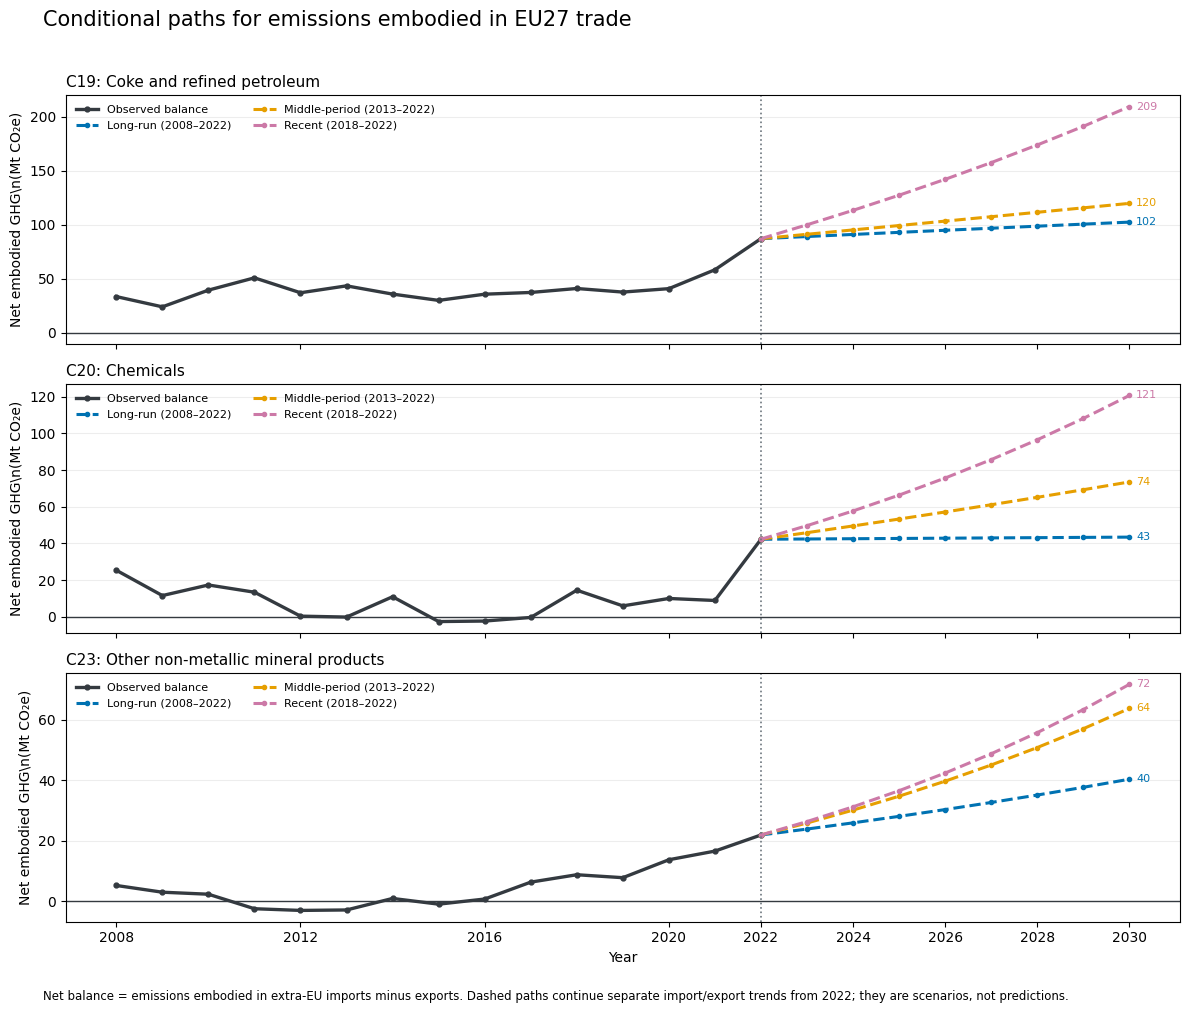

,sector,sector_label,scenario,trend_window,imports_2022_mtco2e,exports_2022_mtco2e,net_imports_2022_mtco2e,imports_2030_mtco2e,exports_2030_mtco2e,net_imports_2030_mtco2e,change_in_net_balance_mtco2e,imports_annual_rate_pct,exports_annual_rate_pct
0,C19,Coke and refined petroleum,Long-run (2008–2022),2008–2022,133.5,46.4,87.1,141.6,39.2,102.4,15.3,0.7,-2.1
1,C19,Coke and refined petroleum,Middle-period (2013–2022),2013–2022,133.5,46.4,87.1,155.8,36.1,119.8,32.7,2.0,-3.1
2,C19,Coke and refined petroleum,Recent (2018–2022),2018–2022,133.5,46.4,87.1,237.1,27.7,209.4,122.3,7.4,-6.2
3,C20,Chemicals,Long-run (2008–2022),2008–2022,139.3,97.0,42.3,139.3,95.8,43.5,1.2,-0.0,-0.2
4,C20,Chemicals,Middle-period (2013–2022),2013–2022,139.3,97.0,42.3,169.8,96.3,73.5,31.2,2.5,-0.1
5,C20,Chemicals,Recent (2018–2022),2018–2022,139.3,97.0,42.3,234.3,113.6,120.7,78.4,6.7,2.0
6,C23,Other non-metallic mineral products,Long-run (2008–2022),2008–2022,51.4,29.5,21.9,71.5,31.1,40.4,18.4,4.2,0.7
7,C23,Other non-metallic mineral products,Middle-period (2013–2022),2013–2022,51.4,29.5,21.9,93.5,29.8,63.8,41.9,7.8,0.1
8,C23,Other non-metallic mineral products,Recent (2018–2022),2018–2022,51.4,29.5,21.9,103.0,31.2,71.8,49.8,9.1,0.7


Saved projection paths: C:\Users\User\Documents\Codex\2026-09-23\i\outputs\eu27_2030_embodied_trade_balance_paths.csv
Saved projection summary: C:\Users\User\Documents\Codex\2026-09-23\i\outputs\eu27_2030_embodied_trade_balance_summary.csv
Saved method and limitations: C:\Users\User\Documents\Codex\2026-09-23\i\outputs\eu27_2030_embodied_trade_balance_manifest.json
Saved chart: C:\Users\User\Documents\Codex\2026-09-23\i\outputs\carbon_leakage_figures\09-2030-embodied-emissions-trade-balance.png


In [4]:
# Conditional 2030 paths for net embodied emissions in extra-EU trade.
# Fit each gross flow separately, then calculate imports minus exports.
from datetime import datetime, timezone

TRADE_SCENARIO_WINDOWS = {
    'Long-run (2008–2022)': (2008, 2022, '#0072B2'),
    'Middle-period (2013–2022)': (2013, 2022, '#E69F00'),
    'Recent (2018–2022)': (2018, 2022, '#CC79A7'),
}
TRADE_FLOW_COLUMNS = {
    'imports': 'imported_embodied_ghg_mt',
    'exports': 'exported_embodied_ghg_mt',
}
trade_projection_sectors = ['C19', 'C20', 'C23']
trade_projection_records = []
trade_projection_summary_records = []

for sector in trade_projection_sectors:
    history = trade_embodied_panel[
        trade_embodied_panel['sector'].eq(sector)
        & trade_embodied_panel['imported_embodied_ghg_mt'].notna()
        & trade_embodied_panel['exported_embodied_ghg_mt'].notna()
    ].sort_values('year').copy()
    baseline = history.loc[history['year'].eq(2022)]
    if baseline.empty:
        continue
    baseline = baseline.iloc[0]
    actual_2022 = {
        'imports': float(baseline['imported_embodied_ghg_mt']),
        'exports': float(baseline['exported_embodied_ghg_mt']),
    }
    actual_net_2022 = actual_2022['imports'] - actual_2022['exports']

    # Observed history is stored once for each sector, followed by scenario paths.
    for _, obs in history.iterrows():
        trade_projection_records.append({
            'sector': sector, 'scenario': 'Observed history', 'trend_window': 'Observed',
            'year': int(obs['year']),
            'imports_mtco2e': float(obs['imported_embodied_ghg_mt']),
            'exports_mtco2e': float(obs['exported_embodied_ghg_mt']),
            'net_imports_mtco2e': float(obs['net_embodied_trade_mt']),
            'observed_or_projected': 'Observed',
        })

    for scenario, (window_start, window_end, color) in TRADE_SCENARIO_WINDOWS.items():
        annual_rates = {}
        for flow, source_col in TRADE_FLOW_COLUMNS.items():
            fit_data = history[
                history['year'].between(window_start, window_end)
                & history[source_col].gt(0)
            ]
            if len(fit_data) < 3:
                raise ValueError(f'Insufficient positive {flow} observations for {sector}, {scenario}.')
            annual_rates[flow] = float(np.polyfit(
                fit_data['year'].to_numpy(dtype=float),
                np.log(fit_data[source_col].to_numpy(dtype=float)), 1
            )[0])

        for year in range(2022, 2031):
            years_forward = year - 2022
            projected_imports = actual_2022['imports'] * np.exp(annual_rates['imports'] * years_forward)
            projected_exports = actual_2022['exports'] * np.exp(annual_rates['exports'] * years_forward)
            trade_projection_records.append({
                'sector': sector, 'scenario': scenario,
                'trend_window': f'{window_start}–{window_end}', 'year': year,
                'imports_mtco2e': projected_imports,
                'exports_mtco2e': projected_exports,
                'net_imports_mtco2e': projected_imports - projected_exports,
                'observed_or_projected': 'Observed baseline' if year == 2022 else 'Projected',
            })

        final_imports = actual_2022['imports'] * np.exp(annual_rates['imports'] * 8)
        final_exports = actual_2022['exports'] * np.exp(annual_rates['exports'] * 8)
        final_net = final_imports - final_exports
        trade_projection_summary_records.append({
            'sector': sector,
            'sector_label': PRESENTATION_LABELS.get(sector, sector),
            'scenario': scenario,
            'trend_window': f'{window_start}–{window_end}',
            'imports_2022_mtco2e': actual_2022['imports'],
            'exports_2022_mtco2e': actual_2022['exports'],
            'net_imports_2022_mtco2e': actual_net_2022,
            'imports_2030_mtco2e': final_imports,
            'exports_2030_mtco2e': final_exports,
            'net_imports_2030_mtco2e': final_net,
            'change_in_net_balance_mtco2e': final_net - actual_net_2022,
            'imports_annual_rate_pct': (np.exp(annual_rates['imports']) - 1) * 100,
            'exports_annual_rate_pct': (np.exp(annual_rates['exports']) - 1) * 100,
        })

trade_balance_projection_paths = pd.DataFrame(trade_projection_records)
trade_balance_projection_summary = pd.DataFrame(trade_projection_summary_records)
TRADE_BALANCE_PROJECTION_PATH = OUTPUT_DIR / 'eu27_2030_embodied_trade_balance_paths.csv'
TRADE_BALANCE_PROJECTION_SUMMARY_PATH = OUTPUT_DIR / 'eu27_2030_embodied_trade_balance_summary.csv'
TRADE_BALANCE_PROJECTION_MANIFEST_PATH = OUTPUT_DIR / 'eu27_2030_embodied_trade_balance_manifest.json'
trade_balance_projection_paths.to_csv(TRADE_BALANCE_PROJECTION_PATH, index=False)
trade_balance_projection_summary.to_csv(TRADE_BALANCE_PROJECTION_SUMMARY_PATH, index=False)

trade_balance_projection_manifest = {
    'analysis': 'Conditional trend scenarios for EU27 net GHG embodied in extra-EU imports minus exports',
    'source': str(EXTERNAL_DIR / 'oecd_ghg_embodied_bilateral_trade_eu27_2008_2022.csv'),
    'export_source': str(OECD_EXPORTS_PATH),
    'observed_years': [2008, 2022],
    'forecast_years': [2023, 2030],
    'sectors': trade_projection_sectors,
    'method': 'For each sector and each of three windows (2008-2022, 2013-2022, 2018-2022), fit log-linear trends separately to positive annual embodied-import and embodied-export estimates. Anchor both projected gross flows on their observed 2022 values, compound through 2030, then calculate net imports minus exports for each year.',
    'scenario_interpretation': 'Historical-window sensitivities, not probabilities, confidence intervals, or causal estimates.',
    'unit': 'million tonnes CO2 equivalent (Mt CO2e)',
    'limitations': [
        'OECD bilateral embodied-GHG estimates end in 2022 in these source extracts.',
        'Only C19, C20 and C23 have observations for both trade directions in this extract; missing sectors are not assumed to be zero.',
        'The projection extrapolates historical rates and does not model policy, prices, technology, demand, trade substitution or structural breaks.',
        'The balance describes modeled emissions embodied in trade and does not measure displaced production or prove carbon leakage.',
        'Recent-window paths can be highly sensitive to a short period and should be read as stress-test scenarios.',
    ],
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
}
TRADE_BALANCE_PROJECTION_MANIFEST_PATH.write_text(
    json.dumps(trade_balance_projection_manifest, indent=2), encoding='utf-8'
)

# Accessible chart: observed balance is solid; each conditional path is dashed.
fig, axes = plt.subplots(len(trade_projection_sectors), 1, figsize=(12, 10), sharex=True)
if len(trade_projection_sectors) == 1:
    axes = [axes]
for ax, sector in zip(axes, trade_projection_sectors):
    sector_paths = trade_balance_projection_paths[trade_balance_projection_paths['sector'].eq(sector)]
    observed = sector_paths[sector_paths['scenario'].eq('Observed history')].sort_values('year')
    ax.plot(observed['year'], observed['net_imports_mtco2e'], color='#343a40', linewidth=2.4,
            marker='o', markersize=3.5, label='Observed balance')
    for scenario, (_, start, color) in TRADE_SCENARIO_WINDOWS.items():
        projected = sector_paths[sector_paths['scenario'].eq(scenario)].sort_values('year')
        projected = projected[projected['year'].ge(2022)]
        ax.plot(projected['year'], projected['net_imports_mtco2e'], color=color, linewidth=2.2,
                linestyle='--', marker='o', markersize=3, label=scenario)
        end_value = projected.loc[projected['year'].eq(2030), 'net_imports_mtco2e']
        if not end_value.empty:
            ax.annotate(f'{end_value.iloc[0]:.0f}', (2030, end_value.iloc[0]), xytext=(5, 0),
                        textcoords='offset points', va='center', fontsize=8, color=color)
    ax.axvline(2022, color='#6c757d', linestyle=':', linewidth=1.2)
    ax.axhline(0, color='#343a40', linewidth=1)
    ax.set_title(f'{sector}: {PRESENTATION_LABELS.get(sector, sector)}', loc='left', fontsize=11)
    ax.set_ylabel('Net embodied GHG\\n(Mt CO₂e)')
    ax.grid(axis='y', alpha=.22)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, ncol=2, fontsize=8, loc='upper left')
axes[-1].set_xlabel('Year')
axes[-1].set_xticks([2008, 2012, 2016, 2020, 2022, 2024, 2026, 2028, 2030])
fig.suptitle('Conditional paths for emissions embodied in EU27 trade', x=.04, ha='left', fontsize=15, y=.995)
fig.text(.04, .005, 'Net balance = emissions embodied in extra-EU imports minus exports. Dashed paths continue separate import/export trends from 2022; they are scenarios, not predictions.', fontsize=8.5)
fig.tight_layout(rect=[0, .025, 1, .98])
TRADE_BALANCE_PROJECTION_FIGURE = PRESENTATION_DIR / '09-2030-embodied-emissions-trade-balance.png'
fig.savefig(TRADE_BALANCE_PROJECTION_FIGURE, dpi=180, bbox_inches='tight')
plt.show()

summary_display = trade_balance_projection_summary.copy()
for col in ['imports_2022_mtco2e','exports_2022_mtco2e','net_imports_2022_mtco2e',
            'imports_2030_mtco2e','exports_2030_mtco2e','net_imports_2030_mtco2e',
            'change_in_net_balance_mtco2e','imports_annual_rate_pct','exports_annual_rate_pct']:
    summary_display[col] = summary_display[col].round(1)
display(summary_display)
print('Saved projection paths:', TRADE_BALANCE_PROJECTION_PATH)
print('Saved projection summary:', TRADE_BALANCE_PROJECTION_SUMMARY_PATH)
print('Saved method and limitations:', TRADE_BALANCE_PROJECTION_MANIFEST_PATH)
print('Saved chart:', TRADE_BALANCE_PROJECTION_FIGURE)

### What the trade-balance scenarios show

All three historical windows keep the net balance positive and put it above its 2022 level for C19, C20 and C23. The 2030 range depends strongly on which years are continued. For example, C19 ranges from about **102 Mt CO₂e** under the long-run pace to about **209 Mt** under the recent pace; C20 ranges from about **43 Mt** to **121 Mt**; and C23 ranges from about **40 Mt** to **72 Mt**. The recent paths rise sharply because import emissions grew faster than export emissions in 2018–2022 for these activities. Treat that result as a sensitivity case, not a central forecast.

The import and export paths, summary table, and method notes are saved as CSV and JSON files below. The projection adds a forward-looking view of the embodied-emissions trade balance; it does not estimate production displacement or establish causal leakage.

This scenario section updates the earlier projection-readiness note. It uses the available four-indicator and embodied-trade overlaps through 2022; refresh the outlook when compatible OECD embodied-carbon data are extended.